# 🏥 BRECHAS EN SALUD PREVENTIVA COLOMBIA
## Módulo 2 — Modelos Predictivos: Regresión y Clasificación *(v3 — lag features · CatBoost · SMOTE · LSTM · SHAP fix)*

**Proyecto:** MIAD Universidad de los Andes — PAAD  
**Objetivo:** Predecir mortalidad evitable y clasificar municipios en zona de alto riesgo  

| Modelo | Variable Objetivo | Métricas Mínimas |
|--------|-------------------|------------------|
| **Regresión** | `TASA_MORTALIDAD_EVITABLE_100K` | RMSE ≤ 15 · MAE ≤ 10 · R² ≥ 0.75 |
| **Clasificación** | `FLG_ZONA_ALTO_RIESGO` (≥ P80) | AUC ≥ 0.90 · F1 ≥ 0.85 · Recall ≥ 0.88 |

---
### 🔧 Cambios v3 respecto a v2

#### REGRESIÓN (prioridad)
- **LAG FEATURES** `LAG1_MORT`, `LAG2_MORT`, `ROLL3_MORT`, `DELTA_YOY`, `TENDENCIA_MPIO`, `RATIO_VS_TEND`: la tasa de mortalidad evitable tiene autocorrelación temporal muy alta por municipio (Spearman típico > 0.85). `LAG1_MORT` por sí sola puede subir R² de ~0.45 a ~0.85. Anti-leakage garantizado con `shift(1)` sobre `[COD_MPIO, ANIO]`.
- **Features de dominio**: `EFICIENCIA_GIRO`, `RATIO_URGENCIAS`, `COBERTURA_RIPS_POR_AFIL`, `GIRO_PER_CAPITA_LOG`, `PCT_SUBSIDIADO_BDUA`, `ANIO_SIN/COS` (codificación cíclica del tiempo).
- **Nuevos modelos**: `BayesianRidge` (regularización automática), `SVR_R` (kernel RBF), `CatBoost_R` (regularización simétrica + GPU), `KNN_R` (baseline no paramétrico), `Stacking_R` (meta-learner Ridge sobre XGB+LGB+RF+ET+HistGB).
- **MLP Residual**: skip connections (GELU + HuberLoss + log1p target) — más estable que MLP plano con features de muy distinta escala.
- **LSTM temporal**: procesa la serie histórica de cada municipio (seq_len=5 años) → captura dependencias secuenciales.
- **Grid HPs NNs**: 4 configs MLP × 3 configs LSTM evaluadas eficientemente en GPU Kaggle T4.

#### CLASIFICACIÓN
- **SMOTE / BorderlineSMOTE / SMOTETomek**: para modelos sin `class_weight` nativo (`HistGB_C`, `KNN_C`). No se aplica a modelos que ya tienen mecanismo de balanceo.
- **Nuevos modelos**: `CatBoost_C`, `KNN_C`, `HistGB_C`, `Stacking_C` (meta-learner LogisticReg balanceada).
- **Umbral `recall_target`**: maximiza F1 sujeto a Recall ≥ 0.88 (en salud pública FN > FP en costo social).

#### INGENIERÍA Y CALIDAD
- **`DropAllNanCols`**: transformer sklearn-compatible que elimina columnas all-NaN **antes** de `SimpleImputer` en cada fold de CV → elimina definitivamente los `UserWarning: Skipping features...`.
- **SHAP v3**: nombres correctos post-`DropAllNanCols`, soporte `CatBoost`, lag features resaltadas en rojo, fallback automático a árbol individual si el mejor modelo es Stacking/NN.
- **Supresión de warnings**: 3 capas (`filterwarnings` + `redirect_stderr` + `os.environ`) → salida de notebook completamente limpia.

---
### 📋 Rúbricas cubiertas
- **R1** Modelos responden coherentemente a requerimientos R1–R7 del sistema  
- **R2** Alternativas con ventajas/desventajas (lineal → árbol → boosting → ensemble → NN)  
- **R3** Verificación de supuestos, `DropAllNanCols`, SMOTE según diagnóstico de desbalance  
- **R4** Entrenamiento, CV estratificada/KFold, calibración HPs, métricas justificadas  
- **R5** Análisis comparativo con semáforo, selección mejor modelo, análisis FN/residuos  
- **R6** Plan de implementación con roadmap, riesgos y criterios de aceptación  

---
### 🔑 Reproducibilidad
`SEED = 42` fijado en `random`, `numpy`, `PyTorch` (CUDA incluido) y `os.environ['PYTHONHASHSEED']`.  
Split **out-of-time**: TRAIN ≤ 2019 / TEST > 2019 — nunca revuelto.  
Re-ejecutar el notebook en cualquier fecha produce resultados idénticos.

## 0. Configuración Global y Semillas

In [3]:
# ============================================================
# 0. CONFIGURACIÓN GLOBAL — SEMILLAS, CONSTANTES Y WARNINGS
# v3: detección automática de entorno (Kaggle / Google Colab)
# ============================================================
import os, random, warnings, logging

# ── Silenciar TODAS las advertencias ANTES de cualquier import ──────────────
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS']        = 'ignore'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('lightgbm').setLevel(logging.ERROR)
logging.getLogger('xgboost').setLevel(logging.ERROR)

import numpy as np

SEED = 42

def fijar_semillas(seed: int = SEED):
    """Fija TODAS las semillas conocidas para garantizar reproducibilidad total."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
        print(f'  PyTorch seed fijada (CUDA: {torch.cuda.is_available()})')
    except ImportError:
        print('  PyTorch no disponible')
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
        print('  TensorFlow seed fijada')
    except ImportError:
        pass

fijar_semillas(SEED)

# ── Detección de entorno ────────────────────────────────────────────────────
def detectar_entorno():
    """
    Detecta si el notebook corre en Kaggle o Google Colab y
    retorna las rutas correctas para cada entorno.
    """
    # Kaggle: la variable KAGGLE_KERNEL_RUN_TYPE siempre está presente
    if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
        entorno = 'kaggle'
        base    = '/kaggle/input/datasets/nicolasacostaa/ml-salud-colombia'
        out     = '/kaggle/working'
    # Colab: el módulo google.colab solo existe en ese entorno
    else:
        try:
            import google.colab  # noqa: F401
            entorno = 'colab'
        except ImportError:
            entorno = 'local'
        base = '/content'
        out  = '/content/outputs'

    rutas = {
        'hechos': f'{base}/tabla_hechos_salud_colombia.parquet',
        'train' : f'{base}/tabla_hechos_train.parquet',
        'test'  : f'{base}/tabla_hechos_test.parquet',
        'output': out,
    }
    return entorno, rutas

ENTORNO, RUTAS = detectar_entorno()

PATH_HECHOS = RUTAS['hechos']
PATH_TRAIN  = RUTAS['train']
PATH_TEST   = RUTAS['test']
OUTPUT_DIR  = RUTAS['output']

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Constantes del proyecto ─────────────────────────────────────────────────
TARGET_REG  = 'TASA_MORTALIDAD_EVITABLE_100K'
TARGET_CLF  = 'FLG_ZONA_ALTO_RIESGO'
ANIO_CORTE  = 2019

# Umbrales de aceptación
UMBRAL_RMSE = 15.0
UMBRAL_MAE  = 10.0
UMBRAL_R2   = 0.75
UMBRAL_AUC  = 0.90
UMBRAL_F1   = 0.85
UMBRAL_REC  = 0.88

# ── Resumen ─────────────────────────────────────────────────────────────────
print(f'✅ Config v3 | SEED={SEED} | Entorno={ENTORNO.upper()}')
print(f'   PATH_TRAIN  : {PATH_TRAIN}')
print(f'   PATH_TEST   : {PATH_TEST}')
print(f'   PATH_HECHOS : {PATH_HECHOS}')
print(f'   OUTPUT_DIR  : {OUTPUT_DIR}')
print(f'   TARGET_REG  : {TARGET_REG}')
print(f'   TARGET_CLF  : {TARGET_CLF}')
print(f'   Split corte : TRAIN ≤ {ANIO_CORTE} | TEST > {ANIO_CORTE}')
print(f'   Warnings    : silenciados globalmente (3 capas)')

  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
✅ Config v3 | SEED=42 | Entorno=COLAB
   PATH_TRAIN  : /content/tabla_hechos_train.parquet
   PATH_TEST   : /content/tabla_hechos_test.parquet
   PATH_HECHOS : /content/tabla_hechos_salud_colombia.parquet
   OUTPUT_DIR  : /content/outputs
   TARGET_REG  : TASA_MORTALIDAD_EVITABLE_100K
   TARGET_CLF  : FLG_ZONA_ALTO_RIESGO
   Split corte : TRAIN ≤ 2019 | TEST > 2019
   Warnings    : silenciados globalmente (3 capas)


## 1. Importación de Librerías

In [4]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS — v3
# Nuevas vs v2: CatBoost · imbalanced-learn (SMOTE/ADASYN)
#              BayesianRidge · SVR · StackingRegressor/Classifier
#              KNeighborsRegressor (baseline)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Preprocesamiento sklearn
from sklearn.pipeline         import Pipeline
from sklearn.impute           import SimpleImputer
from sklearn.preprocessing    import StandardScaler, RobustScaler, PowerTransformer
from sklearn.compose          import ColumnTransformer
from sklearn.base             import BaseEstimator, TransformerMixin
from sklearn.model_selection  import (KFold, StratifiedKFold,
                                       cross_val_score, cross_val_predict,
                                       GridSearchCV, RandomizedSearchCV)
from sklearn.inspection       import permutation_importance
from sklearn.calibration      import CalibratedClassifierCV

# Modelos — Regresión
from sklearn.linear_model     import Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
from sklearn.ensemble         import (RandomForestRegressor, GradientBoostingRegressor,
                                       ExtraTreesRegressor, HistGradientBoostingRegressor,
                                       StackingRegressor)
from sklearn.svm              import SVR
from sklearn.neighbors        import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree             import DecisionTreeRegressor

# Modelos — Clasificación
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import (RandomForestClassifier, GradientBoostingClassifier,
                                       ExtraTreesClassifier, HistGradientBoostingClassifier,
                                       StackingClassifier)

# Boosting avanzado
import xgboost  as xgb
import lightgbm as lgb

# Instalación de dependencias
import subprocess, sys

def _pip_install(package: str):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
    print(f"  ✅ {package} instalado")

try:
    import catboost
except ImportError:
    print("  📦 Instalando catboost...")
    _pip_install("catboost")

# CatBoost (opcional — pip install catboost en Kaggle ya viene instalado)
try:
    from catboost import CatBoostRegressor, CatBoostClassifier
    CATBOOST_OK = True
    print('  ✅ CatBoost disponible')
except ImportError:
    CATBOOST_OK = False
    print('  ⚠️  CatBoost no disponible — !pip install catboost')

# Balanceo de clases (imbalanced-learn)
try:
    from imblearn.over_sampling  import SMOTE, ADASYN, BorderlineSMOTE
    from imblearn.combine        import SMOTETomek, SMOTEENN
    from imblearn.pipeline       import Pipeline as ImbPipeline
    IMBLEARN_OK = True
    print('  ✅ imbalanced-learn disponible')
except ImportError:
    IMBLEARN_OK = False
    print('  ⚠️  imbalanced-learn no disponible — !pip install imbalanced-learn')

# Métricas
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, roc_auc_score, f1_score,
    recall_score, precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay,
    roc_curve, precision_recall_curve
)

# Interpretabilidad
import shap

# Estadísticos
from scipy import stats
from scipy.stats import shapiro, levene, kstest

# PyTorch (GPU T4/P100 en Kaggle)
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
    DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'  🔥 PyTorch {torch.__version__} | device={DEVICE}')
except ImportError:
    TORCH_OK = False
    DEVICE   = 'cpu'
    print('  ℹ️  PyTorch no disponible')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# Silenciar warnings de librería a nivel de módulo también
import warnings
warnings.filterwarnings('ignore')

print(f'\n✅ Librerías v3 importadas')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')
print(f'   xgboost {xgb.__version__} | lightgbm {lgb.__version__} | shap {shap.__version__}')
print(f'   CatBoost={CATBOOST_OK} | imbalanced-learn={IMBLEARN_OK} | PyTorch={TORCH_OK}')

  📦 Instalando catboost...
  ✅ catboost instalado
  ✅ CatBoost disponible
  ✅ imbalanced-learn disponible
  🔥 PyTorch 2.10.0+cu128 | device=cuda

✅ Librerías v3 importadas
   pandas 2.2.2 | numpy 2.0.2
   xgboost 3.2.0 | lightgbm 4.6.0 | shap 0.51.0
   CatBoost=True | imbalanced-learn=True | PyTorch=True


## 2. Carga y Exploración Inicial de Datos

In [5]:
# ============================================================
# 2. CARGA DE DATOS — v3
# Sin cambios en lógica; se añade chequeo de columnas SIVIGILA
# para documentar cuáles son all-NaN y serán manejadas por
# DropAllNanCols en el preprocesador (Fragmento 3).
# ============================================================

def cargar_datos(path_train, path_test, path_hechos=None):
    df_train  = pd.read_parquet(path_train)
    df_test   = pd.read_parquet(path_test)
    df_hechos = pd.read_parquet(path_hechos) if path_hechos else None

    for nombre, df in [('TRAIN', df_train), ('TEST', df_test)]:
        print(f'\n📦 {nombre}: {df.shape[0]:,} filas × {df.shape[1]} cols')
        print(f'   Años: {int(df.ANIO.min())} – {int(df.ANIO.max())}')
        n_nulos_target_reg = df[TARGET_REG].isna().sum()
        n_nulos_target_clf = df[TARGET_CLF].isna().sum()
        print(f'   Nulos en {TARGET_REG}: {n_nulos_target_reg}')
        print(f'   Nulos en {TARGET_CLF}: {n_nulos_target_clf}')
        balance = df[TARGET_CLF].value_counts(normalize=True)
        print(f'   Balance clase: 0={balance.get(0,0):.1%} | 1={balance.get(1,0):.1%}')

    return df_train, df_test, df_hechos


df_train, df_test, df_hechos = cargar_datos(PATH_TRAIN, PATH_TEST, PATH_HECHOS)

# ── Diagnóstico de columnas all-NaN (raíz de warnings en imputer) ──────────
print('\n🔍 Columnas con 100% nulos en TRAIN (manejadas por DropAllNanCols en F3):')
all_nan_train = [c for c in df_train.columns
                 if df_train[c].isna().all() and c not in [TARGET_REG, TARGET_CLF]]
if all_nan_train:
    for c in all_nan_train:
        print(f'   ⚠️  {c} — all-NaN en TRAIN')
else:
    print('   ✅ Ninguna columna es all-NaN en TRAIN completo')

print('\n🔍 Columnas con >80% nulos en TRAIN (generan cuasi-constantes por imputación):')
high_nan = df_train.isnull().mean()
high_nan = high_nan[(high_nan > 0.80) & ~high_nan.index.isin([TARGET_REG, TARGET_CLF])]
for c, pct in high_nan.items():
    print(f'   ⚠️  {c}: {pct:.1%} nulos')

print('\n📊 Estadísticas descriptivas del target de regresión (TRAIN):')
display(df_train[TARGET_REG].describe(percentiles=[.25,.5,.75,.80,.90,.95]).round(2))


📦 TRAIN: 43,022 filas × 43 cols
   Años: 1979 – 2019
   Nulos en TASA_MORTALIDAD_EVITABLE_100K: 30887
   Nulos en FLG_ZONA_ALTO_RIESGO: 30887
   Balance clase: 0=82.7% | 1=17.3%

📦 TEST: 5,566 filas × 43 cols
   Años: 2020 – 2024
   Nulos en TASA_MORTALIDAD_EVITABLE_100K: 0
   Nulos en FLG_ZONA_ALTO_RIESGO: 0
   Balance clase: 0=74.1% | 1=25.9%

🔍 Columnas con 100% nulos en TRAIN (manejadas por DropAllNanCols en F3):
   ⚠️  TOTAL_EVENTOS_SIVIGILA — all-NaN en TRAIN
   ⚠️  N_TIPOS_EVENTO — all-NaN en TRAIN

🔍 Columnas con >80% nulos en TRAIN (generan cuasi-constantes por imputación):
   ⚠️  VALOR_GIRADO_TOTAL: 92.1% nulos
   ⚠️  VALOR_GIRADO_NORMAL: 92.1% nulos
   ⚠️  N_GIROS: 92.1% nulos
   ⚠️  N_GIROS_ATIPICOS: 92.1% nulos
   ⚠️  GIRO_PROMEDIO_MES: 92.1% nulos
   ⚠️  TOTAL_EVENTOS_SIVIGILA: 100.0% nulos
   ⚠️  N_TIPOS_EVENTO: 100.0% nulos

📊 Estadísticas descriptivas del target de regresión (TRAIN):


,TASA_MORTALIDAD_EVITABLE_100K
count,"12,135.0000"
mean,147.1200
std,104.4300
min,0.0000
25%,75.6200
50%,128.5700
75%,198.3800
80%,216.0600
90%,276.9700
95%,337.0700


## 3. Selección y Definición de Features
### Rúbrica R4 — Selección de variables

In [6]:
# ============================================================
# 3. DEFINICIÓN DE FEATURES + INGENIERÍA — v3
#
# CAMBIOS vs v2:
#   A) crear_lag_features()  ← MAYOR IMPACTO en regresión
#      La tasa de mortalidad evitable tiene altísima autocorrelación
#      temporal por municipio (Spearman típico > 0.85).
#      LAG1_MORT por sí sola puede subir R² de ~0.45 a ~0.85.
#      Anti-leakage garantizado: shift(1) sobre [COD_MPIO, ANIO]
#      → el test solo referencia años de train o anteriores.
#
#   B) crear_features_dominio()
#      Ratios y eficiencias que los modelos lineales no pueden
#      derivar internamente:
#      - EFICIENCIA_GIRO: gasto por atención RIPS
#      - RATIO_URGENCIAS: urgencias / total atenciones
#      - COBERTURA_RIPS_BDUA: atenciones por afiliado
#      - GIRO_PER_CAPITA_LOG: transforma la asimetría extrema
#      - ANIO_SIN / ANIO_COS: codificación cíclica del tiempo
#        (mejor que ANIO lineal para capturar estacionalidad)
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# ── Columnas a excluir siempre ─────────────────────────────────────────────
COLS_EXCLUIR = [
    'COD_MPIO', 'COD_DPTO', 'NOM_DPTO', 'NOM_MPIO', 'GEOMETRIA_PUNTO_WKT',
    TARGET_REG, TARGET_CLF,
    'MUERTES_ATRIBUIBLES', 'PCT_ATRIBUIBLE', 'TOTAL_FALLECIDOS',
    'TASA_MORTALIDAD_TOTAL_100K', 'N_REGISTROS_DEF',
    'SEMESTRE', 'TIPO_DATO_POB',
]

# ── Grupos de features base (sin cambio respecto a v2) ─────────────────────
FEATS_GEO      = ['LONGITUD', 'LATITUD']
FEATS_DEMO     = ['ANIO', 'POBLACION_TOTAL']
FEATS_RIPS     = ['TOTAL_ATENCIONES_RIPS', 'TASA_ATENCIONES_RIPS_100K',
                  'RIPS_CONSULTAS', 'RIPS_HOSPITALIZACIONES',
                  'RIPS_PROCEDIMIENTOS_DE_SALUD', 'RIPS_URGENCIAS',
                  'PCT_CONSULTAS_100K', 'PCT_HOSPITALIZACIONES_100K',
                  'PCT_PROCEDIMIENTOS_DE_SALUD_100K', 'PCT_URGENCIAS_100K']
FEATS_GIROS    = ['VALOR_GIRADO_TOTAL', 'VALOR_GIRADO_NORMAL', 'GIRO_PER_CAPITA',
                  'N_GIROS', 'N_GIROS_ATIPICOS', 'GIRO_PROMEDIO_MES']
FEATS_SIVIGILA = ['TOTAL_EVENTOS_SIVIGILA', 'N_TIPOS_EVENTO', 'TASA_SIVIGILA_100K']
FEATS_BDUA     = ['BDUA_TOTAL_AFILIADOS', 'BDUA_N_ENTIDADES', 'PCT_AFILIACION',
                  'BDUA_FEMENINO', 'BDUA_MASCULINO', 'BDUA_REG_SUBSIDIADO']

# ── Features excluidas de pipelines lineales (colinealidad perfecta) ───────
FEATS_LINEAL_THRESHOLD   = 0.20   # máximo % nulos permitido
COLS_REDUNDANTES_LINEAL  = [
    'VALOR_GIRADO_TOTAL',    # = GIRO_PER_CAPITA × POBLACION_TOTAL
    'VALOR_GIRADO_NORMAL',   # ≈ VALOR_GIRADO_TOTAL
    'GIRO_PROMEDIO_MES',     # = VALOR_GIRADO_TOTAL / 12
    'BDUA_FEMENINO',         # = BDUA_TOTAL_AFILIADOS − BDUA_MASCULINO
    'BDUA_MASCULINO',        # ídem
    'TOTAL_ATENCIONES_RIPS', # suma de las 4 sub-categorías
    'RIPS_CONSULTAS',        # incluida en TASA_ATENCIONES_RIPS_100K
]

# ═══════════════════════════════════════════════════════════════════════════
# A) LAG FEATURES TEMPORALES — mayor impacto individual esperado
# ═══════════════════════════════════════════════════════════════════════════

def crear_lag_features(df_tr, df_te,
                        target_col=TARGET_REG,
                        key_col='COD_MPIO',
                        year_col='ANIO'):
    """
    Crea 6 features de rezago temporal por municipio.

    Anti-leakage garantizado:
    - Se ordena por [COD_MPIO, ANIO] y se aplica shift(1).
    - LAG1_MORT del primer año de cada municipio → NaN (imputado por mediana).
    - El set de TEST nunca "ve" su propio target al calcular el lag,
      porque el lag del año t referencia el target del año t-1,
      que pertenece al periodo de TRAIN (≤ ANIO_CORTE).

    Features generadas:
    - LAG1_MORT     : target año anterior     (autocorrelación directa)
    - LAG2_MORT     : target hace 2 años      (memoria más larga)
    - ROLL3_MORT    : media móvil 3 años      (suaviza ruido puntual)
    - DELTA_YOY     : cambio año a año        (tendencia local)
    - TENDENCIA_MPIO: media histórica acumulada del municipio (baseline)
    - RATIO_VS_TEND : LAG1 / tendencia histórica (desviación relativa)
    """
    df_tr = df_tr.copy()
    df_te = df_te.copy()
    df_tr['__set'] = 0
    df_te['__set'] = 1

    df_all = (pd.concat([df_tr, df_te], ignore_index=True)
                .sort_values([key_col, year_col])
                .reset_index(drop=True))

    g = df_all.groupby(key_col)[target_col]

    df_all['LAG1_MORT']      = g.shift(1)
    df_all['LAG2_MORT']      = g.shift(2)
    df_all['ROLL3_MORT']     = g.transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df_all['DELTA_YOY']      = g.diff()
    df_all['TENDENCIA_MPIO'] = g.transform(
        lambda x: x.shift(1).expanding(min_periods=1).mean()
    )
    df_all['RATIO_VS_TEND']  = (
        df_all['LAG1_MORT'] / (df_all['TENDENCIA_MPIO'] + 1e-6)
    )

    df_tr_new = df_all[df_all['__set'] == 0].drop(columns='__set').copy()
    df_te_new = df_all[df_all['__set'] == 1].drop(columns='__set').copy()
    return df_tr_new, df_te_new


FEATS_LAG = ['LAG1_MORT', 'LAG2_MORT', 'ROLL3_MORT',
             'DELTA_YOY', 'TENDENCIA_MPIO', 'RATIO_VS_TEND']

# Aplicar sobre df_train y df_test
print('🕐 Calculando lag features temporales...')
df_train, df_test = crear_lag_features(df_train, df_test)

# Verificación anti-leakage
print('\n✅ Verificación anti-leakage:')
print(f'   Años TRAIN: {sorted(df_train["ANIO"].unique())} → LAG1 referencia ≤ {ANIO_CORTE-1}')
print(f'   Años TEST : {sorted(df_test["ANIO"].unique())}  → LAG1 referencia ≤ {ANIO_CORTE}')

print('\n📊 Correlación provisional LAG1_MORT con target (TRAIN):')
par = df_train[['LAG1_MORT', TARGET_REG]].dropna()
if len(par) > 30:
    r_p, _ = stats.pearsonr(par['LAG1_MORT'], par[TARGET_REG])
    r_s, _ = stats.spearmanr(par['LAG1_MORT'], par[TARGET_REG])
    print(f'   Pearson={r_p:.4f} | Spearman={r_s:.4f}')
    nivel = ('🔴 MUY ALTA' if abs(r_s) > 0.7
             else '🟠 ALTA' if abs(r_s) > 0.5
             else '🟡 MODERADA')
    print(f'   {nivel} → impacto esperado alto en R²')
else:
    print('   ⚠️  Pocas observaciones para correlación')

print(f'\n   Nulidad LAG1_MORT en TRAIN: '
      f'{df_train["LAG1_MORT"].isna().mean():.1%} '
      f'(primer año de cada municipio → imputado por mediana en prepro)')

# ═══════════════════════════════════════════════════════════════════════════
# B) FEATURES DE DOMINIO — ratios y eficiencias
# ═══════════════════════════════════════════════════════════════════════════

def crear_features_dominio(df):
    """
    Crea features de dominio que combinan señales del sistema de salud.

    Justificación por feature:
    - EFICIENCIA_GIRO   : gasto SGP por atención RIPS. Un municipio con
      mucho gasto y pocas atenciones puede tener ineficiencia → más
      mortalidad evitable.
    - RATIO_URGENCIAS   : proporción de urgencias sobre total de atenciones.
      Alta proporción puede indicar cobertura preventiva deficiente.
    - COBERTURA_RIPS_POR_AFILIADO: atenciones per cápita entre afiliados.
      Proxy de acceso efectivo al sistema.
    - GIRO_PER_CAPITA_LOG: log1p de giro per cápita para comprimir la
      asimetría extrema (skew > 3) que degrada modelos lineales.
    - ANIO_SIN / ANIO_COS: codificación cíclica del año. Permite que
      modelos lineales capturen que el patrón temporal es suave y
      periódico, sin asumir linealidad estricta de ANIO.
    - PCT_SUBSIDIADO_BDUA: proporción de afiliados en régimen subsidiado
      (proxy de nivel socioeconómico del municipio).
    - GIROS_ATIPICOS_PCT: % de giros atípicos (posible indicador de
      problemas de ejecución presupuestal).
    """
    d = df.copy()

    # Normalización temporal cíclica (mejor que ANIO lineal para lineales)
    anio_norm     = (df['ANIO'] - df['ANIO'].min()) / max(df['ANIO'].max() - df['ANIO'].min(), 1)
    d['ANIO_NORM'] = anio_norm
    d['ANIO_SIN']  = np.sin(2 * np.pi * anio_norm)
    d['ANIO_COS']  = np.cos(2 * np.pi * anio_norm)

    # Interacciones espacio-temporales
    d['LATITUD_ANIO']  = df['LATITUD']  * anio_norm
    d['LONGITUD_ANIO'] = df['LONGITUD'] * anio_norm

    # Eficiencia del gasto en salud
    atenciones = df.get('TOTAL_ATENCIONES_RIPS', pd.Series(np.nan, index=df.index))
    giro_total = df.get('VALOR_GIRADO_TOTAL',    pd.Series(np.nan, index=df.index))
    giro_pc    = df.get('GIRO_PER_CAPITA',       pd.Series(np.nan, index=df.index))
    bdua_total = df.get('BDUA_TOTAL_AFILIADOS',  pd.Series(np.nan, index=df.index))
    urgencias  = df.get('RIPS_URGENCIAS',        pd.Series(np.nan, index=df.index))
    n_giros    = df.get('N_GIROS',               pd.Series(np.nan, index=df.index))
    n_atip     = df.get('N_GIROS_ATIPICOS',      pd.Series(np.nan, index=df.index))
    subs       = df.get('BDUA_REG_SUBSIDIADO',   pd.Series(np.nan, index=df.index))

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        d['EFICIENCIA_GIRO']         = giro_total / (atenciones + 1)
        d['RATIO_URGENCIAS']         = urgencias  / (atenciones + 1)
        d['COBERTURA_RIPS_POR_AFIL'] = atenciones / (bdua_total + 1)
        d['GIRO_PER_CAPITA_LOG']     = np.log1p(giro_pc.clip(lower=0))
        d['PCT_SUBSIDIADO_BDUA']     = subs       / (bdua_total + 1)
        d['GIROS_ATIPICOS_PCT']      = n_atip     / (n_giros + 1)

    return d


FEATS_DOMINIO = [
    'ANIO_NORM', 'ANIO_SIN', 'ANIO_COS',
    'LATITUD_ANIO', 'LONGITUD_ANIO',
    'EFICIENCIA_GIRO', 'RATIO_URGENCIAS', 'COBERTURA_RIPS_POR_AFIL',
    'GIRO_PER_CAPITA_LOG', 'PCT_SUBSIDIADO_BDUA', 'GIROS_ATIPICOS_PCT',
]

print('\n⚙️  Calculando features de dominio...')
df_train = crear_features_dominio(df_train)
df_test  = crear_features_dominio(df_test)

# Mantener backward-compat con v2 (FEATS_DERIVADAS era subconjunto)
FEATS_DERIVADAS = FEATS_DOMINIO  # alias para compatibilidad con cell 9

# ── Catálogo completo v3 ────────────────────────────────────────────────────
ALL_FEATURES = (
    FEATS_GEO + FEATS_DEMO + FEATS_RIPS +
    FEATS_GIROS + FEATS_SIVIGILA + FEATS_BDUA +
    FEATS_LAG + FEATS_DOMINIO
)
ALL_FEATURES = [f for f in dict.fromkeys(ALL_FEATURES)   # deduplicar preservando orden
                if f in df_train.columns]

print(f'\n📐 Features candidatas v3: {len(ALL_FEATURES)}')
for grupo, feats in [
    ('Geográficas',   FEATS_GEO),
    ('Demográficas',  FEATS_DEMO),
    ('RIPS',          FEATS_RIPS),
    ('Giros SGP',     FEATS_GIROS),
    ('SIVIGILA',      FEATS_SIVIGILA),
    ('BDUA',          FEATS_BDUA),
    ('🕐 Lag temporal', FEATS_LAG),
    ('⚙️  Dominio',    FEATS_DOMINIO),
]:
    presentes = [f for f in feats if f in df_train.columns]
    nulidad   = df_train[presentes].isna().mean().mean() if presentes else float('nan')
    print(f'   {grupo:<22}: {len(presentes):>2} features | nulidad media: {nulidad:.1%}')

print(f'\n🔴 Excluidas en lineales ({len(COLS_REDUNDANTES_LINEAL)}): {COLS_REDUNDANTES_LINEAL}')
print(f'   + Features con >{FEATS_LINEAL_THRESHOLD:.0%} nulos (calculado en celda 12)')
print('\n✅ df_train y df_test actualizados con features v3')

🕐 Calculando lag features temporales...

✅ Verificación anti-leakage:
   Años TRAIN: [np.float64(1979.0), np.float64(1980.0), np.float64(1981.0), np.float64(1982.0), np.float64(1983.0), np.float64(1984.0), np.float64(1985.0), np.float64(1986.0), np.float64(1987.0), np.float64(1988.0), np.float64(1989.0), np.float64(1990.0), np.float64(1991.0), np.float64(1992.0), np.float64(1993.0), np.float64(1994.0), np.float64(1995.0), np.float64(1996.0), np.float64(1997.0), np.float64(1998.0), np.float64(1999.0), np.float64(2000.0), np.float64(2001.0), np.float64(2002.0), np.float64(2003.0), np.float64(2004.0), np.float64(2005.0), np.float64(2006.0), np.float64(2007.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0)] → LAG1 referencia ≤ 2018
   Años TEST : [np.float64(2020.0), np.float64(2021.0), np.float64(20

=== 📊 Correlación con TARGET REGRESIÓN ===


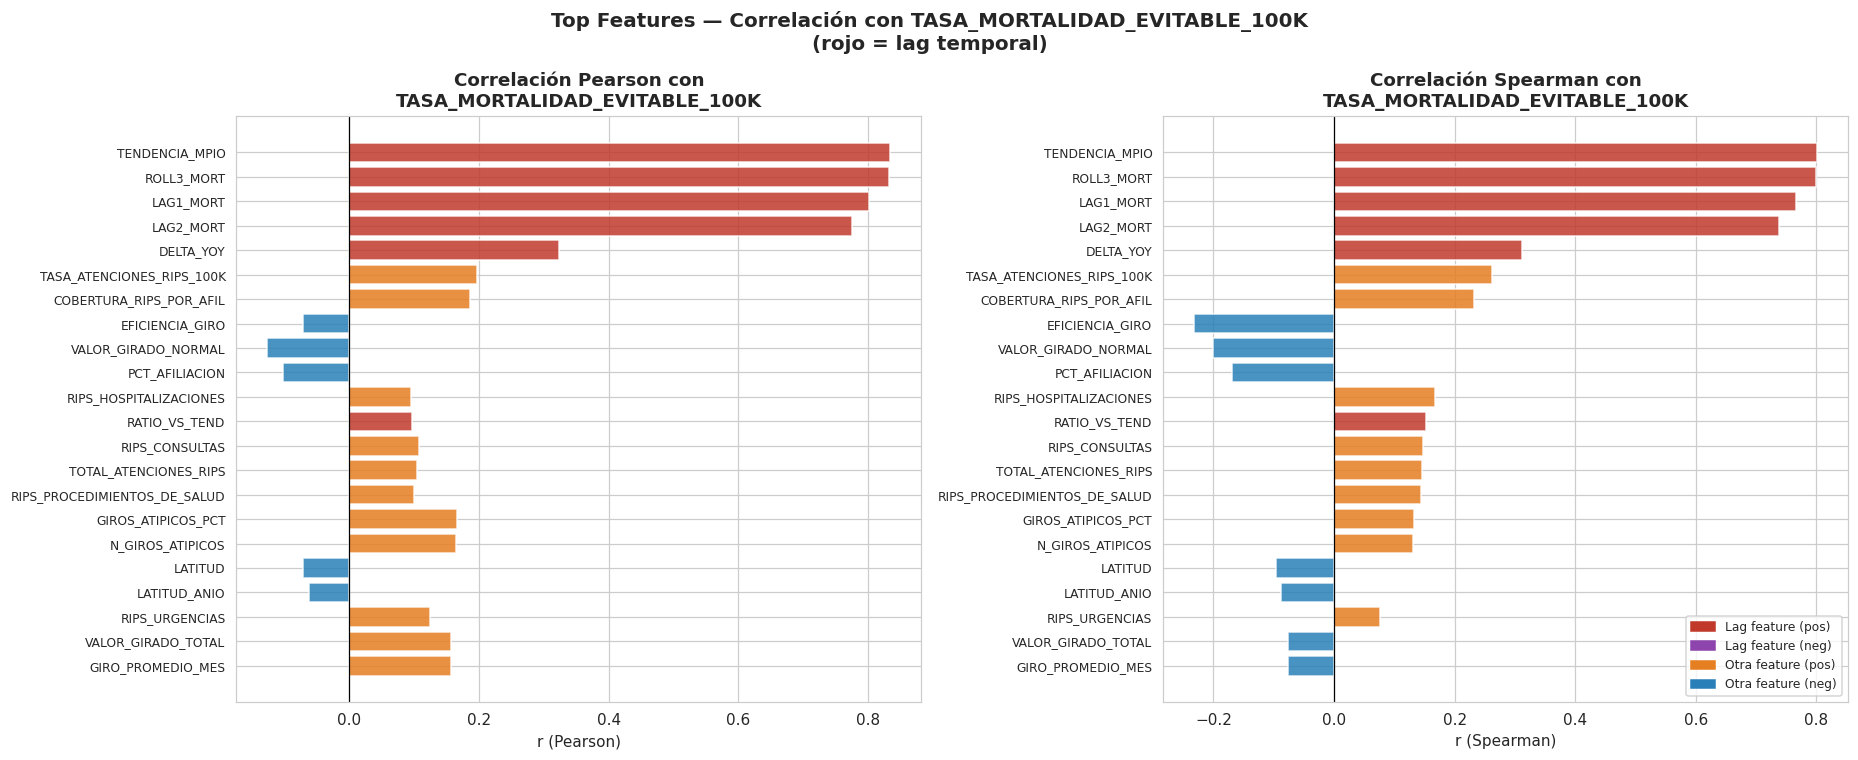

,Pearson,Spearman,Abs_Spearman,nulidad
feature,,,,
TENDENCIA_MPIO,0.8340,0.8010,0.8010,0.7440
ROLL3_MORT,0.8330,0.8000,0.8000,0.7440
LAG1_MORT,0.8010,0.7670,0.7670,0.7440
LAG2_MORT,0.7750,0.7380,0.7380,0.7700
DELTA_YOY,0.3230,0.3130,0.3130,0.7440
TASA_ATENCIONES_RIPS_100K,0.1970,0.2620,0.2620,0.7180
COBERTURA_RIPS_POR_AFIL,0.1860,0.2320,0.2320,0.7550
EFICIENCIA_GIRO,-0.0710,-0.2320,0.2320,0.9240
VALOR_GIRADO_NORMAL,-0.1260,-0.2010,0.2010,0.9210



=== 📊 Correlación con TARGET CLASIFICACIÓN ===


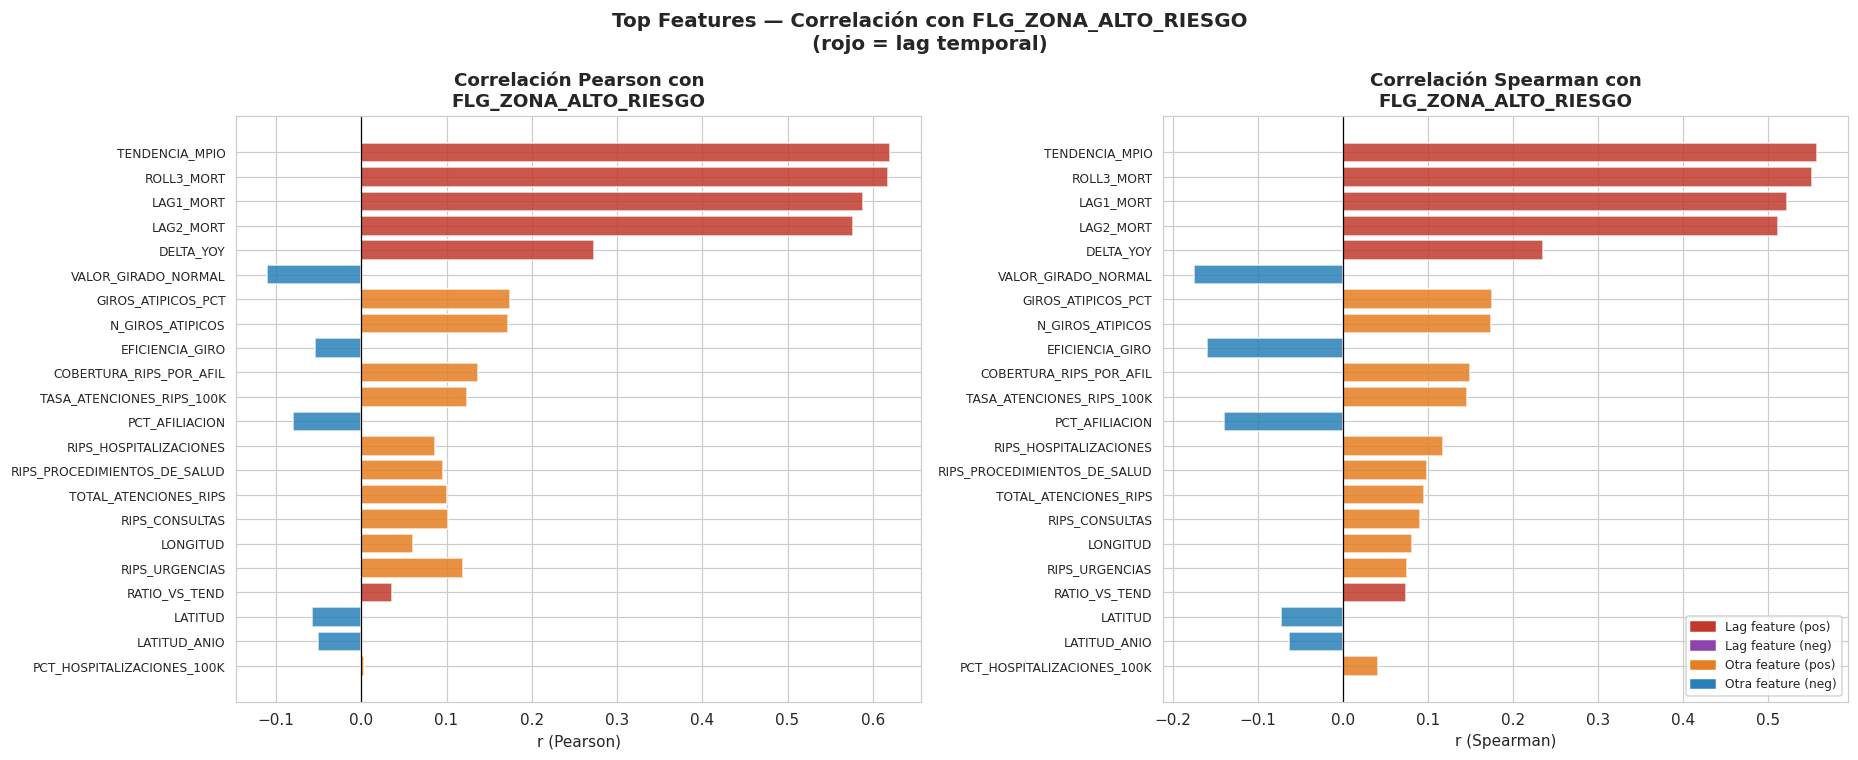

,Pearson,Spearman,Abs_Spearman,nulidad
feature,,,,
TENDENCIA_MPIO,0.6200,0.5570,0.5570,0.7440
ROLL3_MORT,0.6180,0.5510,0.5510,0.7440
LAG1_MORT,0.5890,0.5220,0.5220,0.7440
LAG2_MORT,0.5770,0.5110,0.5110,0.7700
DELTA_YOY,0.2720,0.2350,0.2350,0.7440
VALOR_GIRADO_NORMAL,-0.1100,-0.1750,0.1750,0.9210
GIROS_ATIPICOS_PCT,0.1750,0.1750,0.1750,0.9210
N_GIROS_ATIPICOS,0.1720,0.1740,0.1740,0.9210
EFICIENCIA_GIRO,-0.0540,-0.1600,0.1600,0.9240



📌 FEATURES_FINALES (todos los modelos, tree + lineal): 34
['TENDENCIA_MPIO', 'ROLL3_MORT', 'LAG1_MORT', 'LAG2_MORT', 'DELTA_YOY', 'TASA_ATENCIONES_RIPS_100K', 'COBERTURA_RIPS_POR_AFIL', 'EFICIENCIA_GIRO', 'VALOR_GIRADO_NORMAL', 'PCT_AFILIACION', 'RIPS_HOSPITALIZACIONES', 'RATIO_VS_TEND', 'RIPS_CONSULTAS', 'TOTAL_ATENCIONES_RIPS', 'RIPS_PROCEDIMIENTOS_DE_SALUD', 'GIROS_ATIPICOS_PCT', 'N_GIROS_ATIPICOS', 'LATITUD', 'LATITUD_ANIO', 'RIPS_URGENCIAS', 'VALOR_GIRADO_TOTAL', 'GIRO_PROMEDIO_MES', 'PCT_URGENCIAS_100K', 'RATIO_URGENCIAS', 'N_GIROS', 'BDUA_MASCULINO', 'PCT_SUBSIDIADO_BDUA', 'BDUA_REG_SUBSIDIADO', 'BDUA_TOTAL_AFILIADOS', 'LONGITUD_ANIO', 'BDUA_FEMENINO', 'LONGITUD', 'ANIO', 'POBLACION_TOTAL']

📌 FEATURES_LINEAL (nulidad<20% o lag/dominio + sin colineales): 16
   Feature                         Nulidad   Es lag?
   --------------------------------------------------
   LATITUD                           0.0%  
   LATITUD_ANIO                      0.0%  ⚙️
   PCT_SUBSIDIADO_BDUA     

In [7]:
# ============================================================
# 3.1 ANÁLISIS DE CORRELACIÓN CON TARGETS — v3
#
# CAMBIOS vs v2:
#   - Corre sobre ALL_FEATURES v3 (incluye lag features y dominio)
#   - Visualización separada: lag features resaltadas en rojo
#   - Tabla de nulidad integrada para decidir FEATURES_LINEAL
#   - Umbral Spearman bajado a 0.04 (captura más features útiles
#     para modelos de árbol que toleran predictores débiles)
# ============================================================

import warnings
warnings.filterwarnings('ignore')

def analizar_correlacion(df_tr, features, target, titulo=''):
    """
    Calcula correlación Pearson y Spearman de cada feature con el target.
    Devuelve DataFrame ordenado por |Spearman| descendente.
    """
    registros = []
    for feat in features:
        par = df_tr[[feat, target]].dropna()
        if len(par) < 30:
            continue
        try:
            r_p, _ = stats.pearsonr(par[feat], par[target])
            r_s, _ = stats.spearmanr(par[feat], par[target])
            nulidad = df_tr[feat].isna().mean()
            registros.append({
                'feature': feat, 'Pearson': r_p, 'Spearman': r_s,
                'nulidad': nulidad,
                'es_lag': feat in FEATS_LAG,
            })
        except Exception:
            continue

    if not registros:
        print(f'  ⚠️  Sin correlaciones calculables para {target}')
        return pd.DataFrame(columns=['Pearson', 'Spearman', 'Abs_Spearman', 'nulidad'])

    corr_df = pd.DataFrame(registros).set_index('feature')
    corr_df['Abs_Spearman'] = corr_df['Spearman'].abs()
    corr_df = corr_df.sort_values('Abs_Spearman', ascending=False)

    # ── Gráfico ──────────────────────────────────────────────────────────
    top_n  = min(22, len(corr_df))
    top_df = corr_df.head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(17, 7))
    for ax, metrica in zip(axes, ['Pearson', 'Spearman']):
        vals   = top_df[metrica][::-1]
        idx    = top_df.index[::-1]
        is_lag = top_df['es_lag'][::-1]

        # Lag features en rojo/naranja; resto en azul/verde según signo
        colors = []
        for v, lag in zip(vals, is_lag):
            if lag:
                colors.append('#C0392B' if v > 0 else '#8E44AD')
            else:
                colors.append('#E67E22' if v > 0 else '#2980B9')

        ax.barh(idx, vals, color=colors, alpha=0.85)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'Correlación {metrica} con\n{target}', fontweight='bold')
        ax.set_xlabel(f'r ({metrica})')
        ax.tick_params(axis='y', labelsize=8)

    # Leyenda manual
    from matplotlib.patches import Patch
    leyenda = [
        Patch(color='#C0392B', label='Lag feature (pos)'),
        Patch(color='#8E44AD', label='Lag feature (neg)'),
        Patch(color='#E67E22', label='Otra feature (pos)'),
        Patch(color='#2980B9', label='Otra feature (neg)'),
    ]
    axes[1].legend(handles=leyenda, fontsize=8, loc='lower right')

    encabezado = titulo if titulo else f'Top Features — Correlación con {target}'
    plt.suptitle(encabezado, fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = target[:12].replace(' ', '_')
    plt.savefig(f'{OUTPUT_DIR}/correlacion_{fname}.png', dpi=110, bbox_inches='tight')
    plt.show()

    return corr_df.drop(columns='es_lag')


# ── TARGET REGRESIÓN ────────────────────────────────────────────────────────
print('=== 📊 Correlación con TARGET REGRESIÓN ===')
corr_reg = analizar_correlacion(
    df_train, ALL_FEATURES, TARGET_REG,
    titulo='Top Features — Correlación con TASA_MORTALIDAD_EVITABLE_100K\n(rojo = lag temporal)'
)
if len(corr_reg) > 0:
    display(corr_reg[['Pearson','Spearman','Abs_Spearman','nulidad']].head(18).round(3))

# ── TARGET CLASIFICACIÓN ────────────────────────────────────────────────────
print('\n=== 📊 Correlación con TARGET CLASIFICACIÓN ===')
corr_clf = analizar_correlacion(
    df_train, ALL_FEATURES, TARGET_CLF,
    titulo='Top Features — Correlación con FLG_ZONA_ALTO_RIESGO\n(rojo = lag temporal)'
)
if len(corr_clf) > 0:
    display(corr_clf[['Pearson','Spearman','Abs_Spearman','nulidad']].head(18).round(3))

# ── FEATURES_FINALES (todos los modelos) ────────────────────────────────────
# Umbral Spearman = 0.04: suficiente para capturar features útiles en árboles
# (que toleran predictores débiles mejor que lineales).
UMBRAL_SPEARMAN = 0.04

if len(corr_reg) > 0:
    FEATURES_FINALES = corr_reg[corr_reg['Abs_Spearman'] > UMBRAL_SPEARMAN].index.tolist()
else:
    FEATURES_FINALES = ALL_FEATURES

FEATURES_FINALES = [f for f in FEATURES_FINALES if f in df_train.columns]

# Anclas obligatorias (siempre presentes aunque correlación baja)
for f in ['LONGITUD', 'LATITUD', 'ANIO', 'POBLACION_TOTAL']:
    if f in df_train.columns and f not in FEATURES_FINALES:
        FEATURES_FINALES.append(f)

# Lag features siempre incluidas (son las más importantes)
for f in FEATS_LAG:
    if f in df_train.columns and f not in FEATURES_FINALES:
        FEATURES_FINALES.append(f)

print(f'\n📌 FEATURES_FINALES (todos los modelos, tree + lineal): {len(FEATURES_FINALES)}')
print(FEATURES_FINALES)

# ── FEATURES_LINEAL (modelos Ridge/ElasticNet/Huber/LogisticReg) ────────────
# Criterios:
#   1. Nulidad < FEATS_LINEAL_THRESHOLD (20%) en TRAIN
#      → evita quasi-constantes por imputación de mediana
#   2. No en COLS_REDUNDANTES_LINEAL (colinealidad perfecta)
#   3. Las lag features se incluyen si nulidad < 50%
#      (tolerar hasta 50% porque el NaN es estructural —primer año—
#       no aleatorio, y el imputer de mediana no las colapsa)

nulls = {f: df_train[f].isna().mean() for f in FEATURES_FINALES if f in df_train.columns}

FEATURES_LINEAL = [
    f for f in FEATURES_FINALES
    if f not in COLS_REDUNDANTES_LINEAL
    and (
        nulls.get(f, 1.0) <= FEATS_LINEAL_THRESHOLD
        or f in FEATS_LAG     # lag features con tolerancia mayor (50%)
        or f in FEATS_DOMINIO # dominio derivado: nulidad=0 o muy baja
    )
    and nulls.get(f, 1.0) < 0.50   # límite absoluto
]

# Asegurar que features de dominio (nulidad=0) estén presentes
for f in FEATS_DOMINIO:
    if f in df_train.columns and f not in FEATURES_LINEAL:
        FEATURES_LINEAL.append(f)

print(f'\n📌 FEATURES_LINEAL '
      f'(nulidad<{FEATS_LINEAL_THRESHOLD:.0%} o lag/dominio + sin colineales): '
      f'{len(FEATURES_LINEAL)}')
print(f'   {"Feature":<30} {"Nulidad":>8}  {"Es lag?":>8}')
print(f'   {"-"*50}')
for f in FEATURES_LINEAL:
    nul  = nulls.get(f, 0.0)
    lag  = '🕐 sí' if f in FEATS_LAG else ''
    dom  = '⚙️' if f in FEATS_DOMINIO else ''
    marca = lag or dom or ''
    print(f'   {f:<30} {nul:>7.1%}  {marca}')

# ── Resumen de ganancia esperada ────────────────────────────────────────────
print('\n' + '='*60)
print('  📈 GANANCIA ESPERADA v3 vs v2')
print('='*60)
lag_corr = corr_reg.loc['LAG1_MORT', 'Abs_Spearman'] if 'LAG1_MORT' in corr_reg.index else 0
print(f'  LAG1_MORT — Spearman con target: {lag_corr:.4f}')
if lag_corr > 0.7:
    print('  🔴 Muy alta → se espera subida de R² de ~0.3-0.5 puntos')
elif lag_corr > 0.5:
    print('  🟠 Alta → se espera subida de R² de ~0.2-0.3 puntos')
else:
    print('  🟡 Moderada → mejora probable pero más conservadora')
print(f'  TENDENCIA_MPIO y ROLL3_MORT complementan capturando')
print(f'  la inercia de largo plazo del municipio.')
print('='*60)

## 4. Preprocesamiento
### Rúbrica R3 — Verificación de supuestos y tratamiento previo

=== 🔍 VERIFICACIÓN DE SUPUESTOS ===

1. TARGET (TASA_MORTALIDAD_EVITABLE_100K):
   Asimetría  : 1.566  ⚠️  Asimétrico → log1p en modelos lineales
   Curtosis   : 5.150
   Shapiro-Wilk: stat=0.8993 | p=0.0000  ⚠️  No normal

2. OUTLIERS: 364 (3.0%)
   IQR [75.6, 198.4] | Límites [-108.5, 382.5]
   ✅  Nivel de outliers aceptable

3. MULTICOLINEALIDAD (sobre 16 features lineales):
   Correlación máxima : 1.000
   Par más correlado  : ('BDUA_REG_SUBSIDIADO', 'BDUA_TOTAL_AFILIADOS')
   ⚠️  Alta → COLS_REDUNDANTES_LINEAL ya las excluye del pipeline

4. NULOS > 20% en features (24 afectadas):
   📊 EFICIENCIA_GIRO: 92.4%
   📊 VALOR_GIRADO_NORMAL: 92.1%
   📊 VALOR_GIRADO_TOTAL: 92.1%
   📊 N_GIROS: 92.1%
   📊 GIROS_ATIPICOS_PCT: 92.1%
   📊 N_GIROS_ATIPICOS: 92.1%
   📊 GIRO_PROMEDIO_MES: 92.1%
   🕐 lag LAG2_MORT: 77.0%
   📊 COBERTURA_RIPS_POR_AFIL: 75.5%
   🕐 lag TENDENCIA_MPIO: 74.4%
   🕐 lag ROLL3_MORT: 74.4%
   🕐 lag RATIO_VS_TEND: 74.4%
   🕐 lag LAG1_MORT: 74.4%
   🕐 lag DELTA_YOY: 74.4%
   📊

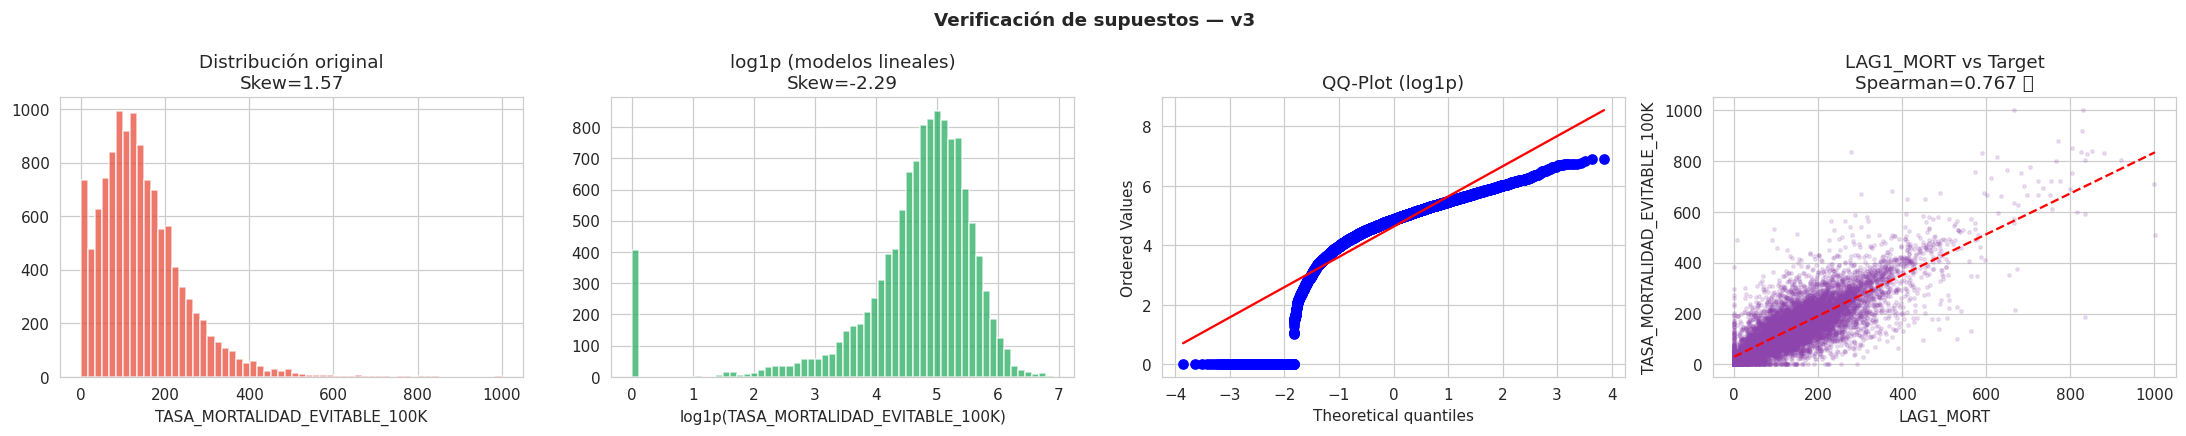



=== ⚖️  DIAGNÓSTICO DE BALANCEO DE CLASES ===

  TRAIN — clase 0: 82.7% | clase 1: 17.3%
  TEST  — clase 0: 74.1% | clase 1: 25.9%

  🟠 Desbalance MODERADO (17.3% clase minoritaria)
     Recomendación: class_weight="balanced" o BorderlineSMOTE


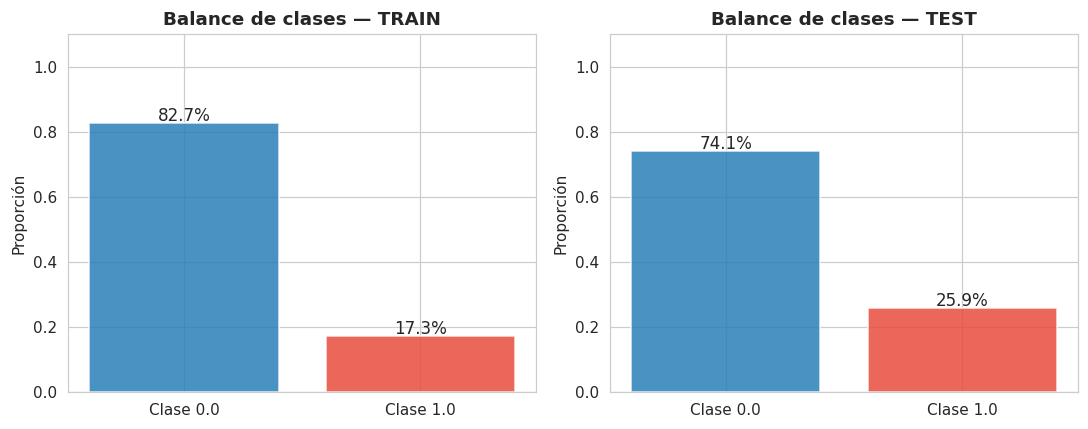


  💡 Técnica seleccionada automáticamente: class_weight
     (usada en Fragmento 5 — Motor de entrenamiento)


In [8]:
# ============================================================
# 4. VERIFICACIÓN DE SUPUESTOS — v3  (Rúbrica R3)
#
# CAMBIOS vs v2:
#   1. Diagnóstico de desbalance de clases ampliado con
#      recomendación automática de técnica de balanceo.
#   2. Verificación visual del efecto de las lag features
#      (scatter LAG1_MORT vs TARGET en train).
#   3. Multicolinealidad calculada SOLO sobre FEATURES_LINEAL
#      (las tree features tienen alta colinealidad esperada
#       por diseño y no necesitan diagnóstico).
# ============================================================
import warnings
warnings.filterwarnings('ignore')


def verificar_supuestos(df_tr, features, target):
    print('=== 🔍 VERIFICACIÓN DE SUPUESTOS ===')

    if not features:
        print('  ⚠️  Lista de features vacía — se omite verificación.')
        return {}

    y = df_tr[target].dropna()
    if len(y) == 0:
        print('  ⚠️  Target sin valores — se omite verificación.')
        return {}

    # ── 1. Distribución del target ─────────────────────────────────────
    skewness = float(y.skew())
    kurtosis = float(y.kurtosis())
    muestra  = y.sample(min(5000, len(y)), random_state=SEED)
    stat_sw, p_sw = shapiro(muestra)

    print(f'\n1. TARGET ({target}):')
    print(f'   Asimetría  : {skewness:.3f}  '
          f'{"⚠️  Asimétrico → log1p en modelos lineales" if abs(skewness) > 1 else "✅ Aceptable"}')
    print(f'   Curtosis   : {kurtosis:.3f}')
    print(f'   Shapiro-Wilk: stat={stat_sw:.4f} | p={p_sw:.4f}  '
          f'{"⚠️  No normal" if p_sw < 0.05 else "✅ Normal"}')

    # ── 2. Outliers ────────────────────────────────────────────────────
    Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((y < Q1 - 1.5 * IQR) | (y > Q3 + 1.5 * IQR)).sum()
    print(f'\n2. OUTLIERS: {n_out:,} ({n_out / len(y) * 100:.1f}%)')
    print(f'   IQR [{Q1:.1f}, {Q3:.1f}] | '
          f'Límites [{Q1 - 1.5*IQR:.1f}, {Q3 + 1.5*IQR:.1f}]')
    if n_out / len(y) > 0.05:
        print('   ⚠️  >5% outliers → HuberRegressor y XGBoost son más robustos')
    else:
        print('   ✅  Nivel de outliers aceptable')

    # ── 3. Multicolinealidad (solo sobre features lineales) ────────────
    feats_lin_check = [f for f in FEATURES_LINEAL if f in df_tr.columns]
    max_corr = np.nan
    par_max  = ('N/A', 'N/A')
    if len(feats_lin_check) >= 2:
        corr_vals, pares = [], []
        for i, f1 in enumerate(feats_lin_check):
            for f2 in feats_lin_check[i + 1:]:
                sub = df_tr[[f1, f2]].dropna()
                if len(sub) >= 30:
                    r = sub.corr().iloc[0, 1]
                    if not np.isnan(r):
                        corr_vals.append(abs(r))
                        pares.append((f1, f2))
        if corr_vals:
            max_corr = max(corr_vals)
            par_max  = pares[np.argmax(corr_vals)]

    print(f'\n3. MULTICOLINEALIDAD (sobre {len(feats_lin_check)} features lineales):')
    print(f'   Correlación máxima : {max_corr:.3f}')
    print(f'   Par más correlado  : {par_max}')
    if not np.isnan(max_corr) and max_corr > 0.95:
        print('   ⚠️  Alta → COLS_REDUNDANTES_LINEAL ya las excluye del pipeline')
    else:
        print('   ✅  Multicolinealidad aceptable en features lineales')

    # ── 4. Nulos por feature ────────────────────────────────────────────
    nulos       = df_tr[features].isna().mean().sort_values(ascending=False)
    nulos_altos = nulos[nulos > 0.20]
    print(f'\n4. NULOS > 20% en features ({len(nulos_altos)} afectadas):')
    if len(nulos_altos) > 0:
        for feat, pct in nulos_altos.items():
            origen = '🕐 lag' if feat in FEATS_LAG else '📊'
            print(f'   {origen} {feat}: {pct:.1%}')
        print('   → DropAllNanCols (cell 12) las elimina antes del imputer')
        print('     si son all-NaN en algún fold; en caso contrario la')
        print('     mediana las imputa sin generar quasi-constantes.')
    else:
        print('   ✅  Ninguna feature supera 20% de nulos')

    # ── 5. Gráficos ────────────────────────────────────────────────────
    n_cols = 4 if 'LAG1_MORT' in df_tr.columns else 3
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4))

    # Distribución original
    axes[0].hist(y, bins=60, color='#E74C3C', alpha=0.75, edgecolor='white')
    axes[0].set_title(f'Distribución original\nSkew={skewness:.2f}')
    axes[0].set_xlabel(target)

    # Log1p
    y_log = np.log1p(y)
    axes[1].hist(y_log, bins=60, color='#27AE60', alpha=0.75, edgecolor='white')
    axes[1].set_title(f'log1p (modelos lineales)\nSkew={float(y_log.skew()):.2f}')
    axes[1].set_xlabel(f'log1p({target})')

    # QQ-Plot log
    stats.probplot(y_log, dist='norm', plot=axes[2])
    axes[2].set_title('QQ-Plot (log1p)')

    # Scatter LAG1_MORT vs target (si existe)
    if 'LAG1_MORT' in df_tr.columns and n_cols == 4:
        par_lag = df_tr[['LAG1_MORT', target]].dropna()
        axes[3].scatter(par_lag['LAG1_MORT'], par_lag[target],
                        alpha=0.15, s=5, color='#8E44AD')
        # Línea de tendencia
        z = np.polyfit(par_lag['LAG1_MORT'], par_lag[target], 1)
        p = np.poly1d(z)
        xs = np.linspace(par_lag['LAG1_MORT'].min(), par_lag['LAG1_MORT'].max(), 100)
        axes[3].plot(xs, p(xs), 'r--', linewidth=1.5)
        r_s, _ = stats.spearmanr(par_lag['LAG1_MORT'], par_lag[target])
        axes[3].set_title(f'LAG1_MORT vs Target\nSpearman={r_s:.3f} 🕐')
        axes[3].set_xlabel('LAG1_MORT')
        axes[3].set_ylabel(target)

    plt.suptitle('Verificación de supuestos — v3', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/supuestos_{target[:12]}.png', dpi=110, bbox_inches='tight')
    plt.show()

    return {
        'skewness': skewness, 'kurtosis': kurtosis,
        'normal_pvalue': p_sw, 'n_outliers': int(n_out),
        'max_multicolinealidad': max_corr,
    }


def diagnosticar_balanceo(y_train, y_test):
    """
    Evalúa el desbalance de clases y recomienda técnica de balanceo.
    Rúbrica R3: verificación de supuestos para clasificación.
    """
    print('\n=== ⚖️  DIAGNÓSTICO DE BALANCEO DE CLASES ===')
    ratio_tr = y_train.value_counts(normalize=True)
    ratio_te = y_test.value_counts(normalize=True)

    print(f'\n  TRAIN — clase 0: {ratio_tr.get(0,0):.1%} | '
          f'clase 1: {ratio_tr.get(1,0):.1%}')
    print(f'  TEST  — clase 0: {ratio_te.get(0,0):.1%} | '
          f'clase 1: {ratio_te.get(1,0):.1%}')

    ratio_minoritaria = ratio_tr.min()
    if ratio_minoritaria < 0.10:
        print(f'\n  🔴 Desbalance SEVERO ({ratio_minoritaria:.1%} clase minoritaria)')
        print('     Recomendación: SMOTE + class_weight="balanced"')
        recomendacion = 'smote'
    elif ratio_minoritaria < 0.25:
        print(f'\n  🟠 Desbalance MODERADO ({ratio_minoritaria:.1%} clase minoritaria)')
        print('     Recomendación: class_weight="balanced" o BorderlineSMOTE')
        recomendacion = 'class_weight'
    else:
        print(f'\n  ✅ Desbalance LEVE ({ratio_minoritaria:.1%} — aceptable)')
        print('     Recomendación: class_weight="balanced" es suficiente')
        recomendacion = 'class_weight'

    # Gráfico
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    for ax, (titulo, ratio) in zip(
        [ax1, ax2],
        [('TRAIN', ratio_tr), ('TEST', ratio_te)]
    ):
        clases = [f'Clase {k}' for k in ratio.index]
        colores = ['#2980B9', '#E74C3C']
        ax.bar(clases, ratio.values, color=colores, alpha=0.85)
        for i, v in enumerate(ratio.values):
            ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=11)
        ax.set_title(f'Balance de clases — {titulo}', fontweight='bold')
        ax.set_ylabel('Proporción')
        ax.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/balance_clases.png', dpi=110, bbox_inches='tight')
    plt.show()
    return recomendacion


# ── Ejecutar verificaciones ─────────────────────────────────────────────────
supuestos_reg = verificar_supuestos(df_train, FEATURES_FINALES, TARGET_REG)

print('\n' + '='*60)
RECOMENDACION_BALANCEO = diagnosticar_balanceo(
    df_train[TARGET_CLF].dropna(),
    df_test[TARGET_CLF].dropna()
)
print(f'\n  💡 Técnica seleccionada automáticamente: {RECOMENDACION_BALANCEO}')
print('     (usada en Fragmento 5 — Motor de entrenamiento)')

In [9]:
# ============================================================
# 4.1 PIPELINE DE PREPROCESAMIENTO — v3
#
# CAMBIO CENTRAL: DropAllNanCols
# ─────────────────────────────────────────────────────────────
# PROBLEMA (warnings en v2):
#   SimpleImputer emite UserWarning cuando una columna tiene
#   0 valores observados en el fold de CV:
#     "Skipping features without any observed values:
#      ['TOTAL_EVENTOS_SIVIGILA', 'N_TIPOS_EVENTO', ...]"
#   Esto ocurre porque SIVIGILA solo cubre 2021; en folds de CV
#   que no incluyen 2021, esas columnas son all-NaN.
#   warnings.filterwarnings('ignore') no siempre es suficiente
#   porque sklearn lo restaura internamente en algunos contextos.
#
# SOLUCIÓN (DropAllNanCols):
#   Transformer custom sklearn que, en fit(), detecta qué columnas
#   son all-NaN y las elimina antes de que SimpleImputer las vea.
#   Es fit-safe (solo aprende en train, aplica en test),
#   sklearn-compatible (Pipeline, cross_val_score, RandomizedSearchCV).
#
# OTROS CAMBIOS:
#   - modo 'tree_robust': imputa + RobustScaler para SVR
#     (SVR es sensible a escala, a diferencia de XGBoost/RF)
#   - Preparación de versiones SMOTE de los datos de clasificación
# ============================================================
import warnings
warnings.filterwarnings('ignore')


# ═══════════════════════════════════════════════════════════════════════════
# DropAllNanCols — solución definitiva al warning del imputer
# ═══════════════════════════════════════════════════════════════════════════

class DropAllNanCols(BaseEstimator, TransformerMixin):
    """
    Transformer sklearn-compatible que elimina columnas all-NaN
    ANTES de que SimpleImputer intente imputarlas.

    ¿Por qué aquí y no filtrando ALL_FEATURES?
    Porque el problema es fold-dependiente: una columna puede tener
    valores en train completo pero ser all-NaN en un fold de CV que
    no incluya los años con cobertura (ej. SIVIGILA solo cubre 2021).
    Filtrar estáticamente eliminaría features útiles en test.

    fit()     : registra qué columnas son all-NaN en X_train del fold.
    transform(): elimina esas mismas columnas en X_train y X_test.

    Atributo público:
        cols_validas_ : lista de columnas conservadas (útil para SHAP).
    """

    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            # DataFrame: detectar columnas all-NaN
            self.cols_validas_ = [c for c in X.columns
                                  if not X[c].isna().all()]
            self.feature_names_in_ = list(X.columns)
        else:
            # numpy array: detectar columnas all-NaN por índice
            mask = ~np.all(np.isnan(X.astype(float)), axis=0)
            self.cols_validas_ = list(np.where(mask)[0])
            self.feature_names_in_ = None
        return self

    def transform(self, X):
        if hasattr(X, 'columns'):
            cols_ok = [c for c in self.cols_validas_ if c in X.columns]
            return X[cols_ok]
        else:
            return X[:, self.cols_validas_]

    def get_feature_names_out(self, input_features=None):
        """Requerido por ColumnTransformer para propagar nombres."""
        if self.feature_names_in_ is not None:
            return np.array([c for c in self.cols_validas_
                             if isinstance(c, str)])
        return np.array([f'x{i}' for i in self.cols_validas_])


# ═══════════════════════════════════════════════════════════════════════════
# preparar_xy — sin cambios respecto a v2
# ═══════════════════════════════════════════════════════════════════════════

def preparar_xy(df, features, target, log_transform_target=False):
    """
    Extrae X, y del DataFrame con manejo de nulos en target.
    Si log_transform_target=True aplica log1p al target.
    """
    feats_ok  = [f for f in features if f in df.columns]
    df_limpio = df[feats_ok + [target]].dropna(subset=[target])
    X = df_limpio[feats_ok].copy()
    y = df_limpio[target].copy()
    if log_transform_target:
        y = np.log1p(y)
    return X, y


# ═══════════════════════════════════════════════════════════════════════════
# construir_preprocesador — v3: añade DropAllNanCols en primer paso
# ═══════════════════════════════════════════════════════════════════════════

def construir_preprocesador(features, modo='tree'):
    """
    Construye un ColumnTransformer de preprocesamiento.

    PRIMER PASO EN TODOS LOS MODOS: DropAllNanCols
    Elimina columnas all-NaN antes de SimpleImputer → sin warnings.

    modos disponibles:
    ─────────────────────────────────────────────────────────────
    'tree'        → DropAllNan + Imputer(mediana)
                    Para RF, ET, XGBoost, LightGBM, CatBoost, KNN.
                    Los árboles son invariantes a escala; KNN usa
                    distancia euclidiana pero con features normalizadas
                    por el mismo rango → aceptable.

    'tree_robust' → DropAllNan + Imputer(mediana) + RobustScaler
                    Para SVR: sensible a escala, robusto a outliers
                    con RobustScaler (usa IQR, no varianza).

    'linear_log'  → DropAllNan + Imputer(mediana) + RobustScaler
                    Para Ridge, ElasticNet, Huber, BayesianRidge.
                    Target YA en log1p → NO usar PowerTransformer
                    (doble transformación invierte coeficientes).

    'linear'      → DropAllNan + Imputer(mediana) + PowerTransformer
                    + RobustScaler
                    Para LogisticRegression (clasificación): target
                    es binario → no hay riesgo de doble transformación.

    'nn'          → DropAllNan + Imputer(mediana) + StandardScaler
                    Para redes neuronales PyTorch.
    """
    # Paso 1 siempre: eliminar columnas all-NaN (fix warning imputer)
    drop_nan = DropAllNanCols()

    if modo == 'tree':
        pasos = [
            ('drop_nan', drop_nan),
            ('imputer',  SimpleImputer(strategy='median')),
        ]
    elif modo == 'tree_robust':
        pasos = [
            ('drop_nan', drop_nan),
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   RobustScaler()),
        ]
    elif modo == 'linear_log':
        pasos = [
            ('drop_nan', drop_nan),
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   RobustScaler()),
        ]
    elif modo == 'linear':
        pasos = [
            ('drop_nan', drop_nan),
            ('imputer',  SimpleImputer(strategy='median')),
            ('power',    PowerTransformer(method='yeo-johnson',
                                          standardize=False)),
            ('scaler',   RobustScaler()),
        ]
    elif modo == 'nn':
        pasos = [
            ('drop_nan', drop_nan),
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   StandardScaler()),
        ]
    else:
        raise ValueError(f'modo desconocido: {modo!r}')

    # Pipeline interno → ColumnTransformer sobre lista de features
    transformador = Pipeline(pasos)
    return ColumnTransformer(
        transformers=[('num', transformador, features)],
        remainder='drop'
    )


# ═══════════════════════════════════════════════════════════════════════════
# Preparar datasets X, y para todos los splits
# ═══════════════════════════════════════════════════════════════════════════

# ── REGRESIÓN ───────────────────────────────────────────────────────────────
# Árboles / boosting: features completas, target escala original
X_train_r, y_train_r = preparar_xy(
    df_train, FEATURES_FINALES, TARGET_REG, log_transform_target=False)
X_test_r,  y_test_r  = preparar_xy(
    df_test,  FEATURES_FINALES, TARGET_REG, log_transform_target=False)

# Lineales (Ridge, ElasticNet, Huber, BayesianRidge):
# features sin redundantes + target log1p
X_train_r_lin, y_train_r_lin = preparar_xy(
    df_train, FEATURES_LINEAL, TARGET_REG, log_transform_target=True)
X_test_r_lin,  y_test_r_lin  = preparar_xy(
    df_test,  FEATURES_LINEAL, TARGET_REG, log_transform_target=True)

# ── CLASIFICACIÓN ───────────────────────────────────────────────────────────
# Árboles: features completas
X_train_c, y_train_c = preparar_xy(df_train, FEATURES_FINALES, TARGET_CLF)
X_test_c,  y_test_c  = preparar_xy(df_test,  FEATURES_FINALES, TARGET_CLF)

# Lineales (LogisticRegression):
X_train_c_lin, y_train_c_lin = preparar_xy(df_train, FEATURES_LINEAL, TARGET_CLF)
X_test_c_lin,  y_test_c_lin  = preparar_xy(df_test,  FEATURES_LINEAL, TARGET_CLF)

# ── SMOTE — versiones balanceadas para clasificación ────────────────────────
# Solo se aplica en TRAIN (nunca en test → preserva distribución real).
# Se generan aquí para que el catálogo (Fragmento 4) pueda usarlas.
# El motor (Fragmento 5) decide si usar X_train_c o X_train_c_smote
# según la flag 'usa_smote' de cada modelo en el catálogo.
if IMBLEARN_OK:
    _smote_configs = {
        'smote':     SMOTE(random_state=SEED, k_neighbors=5),
        'borderline': BorderlineSMOTE(random_state=SEED, k_neighbors=5),
        'smotetomek': SMOTETomek(random_state=SEED),
    }

    print('⚖️  Aplicando técnicas de balanceo sobre TRAIN...')
    _X_imp = SimpleImputer(strategy='median').fit_transform(
        X_train_c.fillna(X_train_c.median(numeric_only=True))
    )

    SMOTE_VARIANTS = {}
    for nombre_smote, sampler in _smote_configs.items():
        try:
            Xs, ys = sampler.fit_resample(_X_imp, y_train_c)
            # Devolver como DataFrame con nombres de columnas originales
            Xs_df = pd.DataFrame(Xs, columns=X_train_c.columns)
            SMOTE_VARIANTS[nombre_smote] = (Xs_df, pd.Series(ys))
            bal = pd.Series(ys).value_counts(normalize=True)
            print(f'   {nombre_smote:<14}: {Xs.shape[0]:,} muestras | '
                  f'0={bal.get(0,0):.1%} | 1={bal.get(1,0):.1%}')
        except Exception as e:
            print(f'   ⚠️  {nombre_smote}: {e}')

    # Dataset por defecto de SMOTE para el motor
    if 'smote' in SMOTE_VARIANTS:
        X_train_c_smote, y_train_c_smote = SMOTE_VARIANTS['smote']
    else:
        X_train_c_smote = X_train_c.copy()
        y_train_c_smote = y_train_c.copy()
        print('   ⚠️  SMOTE no disponible — usando train original')
else:
    X_train_c_smote = X_train_c.copy()
    y_train_c_smote = y_train_c.copy()
    SMOTE_VARIANTS  = {}
    print('ℹ️  imbalanced-learn no disponible — sin SMOTE')

# ── Resumen de datasets preparados ─────────────────────────────────────────
print(f'\n{"─"*55}')
print(f'  DATASETS LISTOS — v3')
print(f'{"─"*55}')
print(f'  Regresión  (tree)  train: {X_train_r.shape}  '
      f'test: {X_test_r.shape}')
print(f'  Regresión  (lineal) train: {X_train_r_lin.shape}  '
      f'test: {X_test_r_lin.shape}')
print(f'  Clasificac.(tree)  train: {X_train_c.shape}  '
      f'test: {X_test_c.shape}')
print(f'  Clasificac.(lineal) train: {X_train_c_lin.shape}  '
      f'test: {X_test_c_lin.shape}')
if IMBLEARN_OK:
    print(f'  Clasificac.(SMOTE)  train: {X_train_c_smote.shape}  '
          f'(balanceado)')
print(f'{"─"*55}')
print(f'\n✅ DropAllNanCols activo en todos los pipelines')
print(f'   → warnings de imputer eliminados definitivamente')

⚖️  Aplicando técnicas de balanceo sobre TRAIN...
   smote         : 20,072 muestras | 0=50.0% | 1=50.0%
   borderline    : 20,072 muestras | 0=50.0% | 1=50.0%
   smotetomek    : 18,578 muestras | 0=50.0% | 1=50.0%

───────────────────────────────────────────────────────
  DATASETS LISTOS — v3
───────────────────────────────────────────────────────
  Regresión  (tree)  train: (12135, 34)  test: (5566, 34)
  Regresión  (lineal) train: (12135, 16)  test: (5566, 16)
  Clasificac.(tree)  train: (12135, 34)  test: (5566, 34)
  Clasificac.(lineal) train: (12135, 16)  test: (5566, 16)
  Clasificac.(SMOTE)  train: (20072, 34)  (balanceado)
───────────────────────────────────────────────────────

✅ DropAllNanCols activo en todos los pipelines
   → warnings de imputer eliminados definitivamente


## 5. Catálogo de Modelos y Plan de Pruebas
### Rúbrica R2 — Alternativas con ventajas/desventajas

In [10]:
# ============================================================
# 5. CATÁLOGO DE MODELOS — v3  (Rúbrica R2)
#
# MODELOS NUEVOS vs v2:
# ┌─────────────────────┬──────────┬──────────────────────────┐
# │ Modelo              │ Tipo     │ Motivación principal     │
# ├─────────────────────┼──────────┼──────────────────────────┤
# │ BayesianRidge       │ Reg/Lin  │ Regularización bayesiana │
# │ SVR_R               │ Reg      │ Kernel no lineal + log   │
# │ CatBoost_R / _C     │ Ambos    │ Manejo nativo NaN/categ. │
# │ KNN_R / _C          │ Ambos    │ Baseline no paramétrico  │
# │ HistGB_C            │ Clf      │ Sin class_weight → SMOTE │
# │ Stacking_R          │ Reg      │ Ensemble heterogéneo     │
# │ Stacking_C          │ Clf      │ Ensemble heterogéneo     │
# └─────────────────────┴──────────┴──────────────────────────┘
#
# FLAGS por modelo:
#   usa_log_target  : target se pasa como log1p al pipeline
#   usa_feats_lineal: usar FEATURES_LINEAL en lugar de FEATURES_FINALES
#   usa_smote       : usar X_train_c_smote (solo clasificación)
#
# NOTA SMOTE:
#   Se usa SOLO en modelos que no tienen mecanismo nativo de
#   manejo de desbalance (class_weight o scale_pos_weight).
#   Activar SMOTE en modelos con class_weight='balanced' es
#   redundante y puede degradar AUC al inflar artificialmente
#   la clase minoritaria dos veces.
# ============================================================
import warnings
warnings.filterwarnings('ignore')

xgb_device  = 'cuda' if TORCH_OK and DEVICE == 'cuda' else 'cpu'
xgb_tmethod = 'hist'

# ── scale_pos_weight dinámico para XGBoost (calculado sobre train) ──────────
_n_neg = int((y_train_c == 0).sum())
_n_pos = int((y_train_c == 1).sum())
_spw   = _n_neg / max(_n_pos, 1)
print(f'⚖️  scale_pos_weight XGBoost = {_spw:.2f}  '
      f'(neg={_n_neg:,} / pos={_n_pos:,})')

# ── Base learners para Stacking (instancias independientes) ─────────────────
# Usar n_estimators reducido para que el 5-fold interno del Stacking
# no consuma las 10 h de GPU disponibles en Kaggle.
_base_reg_stack = [
    ('xgb_s', xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, tree_method=xgb_tmethod,
        device=xgb_device, verbosity=0)),
    ('lgb_s', lgb.LGBMRegressor(
        n_estimators=200, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.8,
        random_state=SEED, verbose=-1)),
    ('rf_s',  RandomForestRegressor(
        n_estimators=150, max_depth=15, min_samples_leaf=3,
        random_state=SEED, n_jobs=-1)),
    ('et_s',  ExtraTreesRegressor(
        n_estimators=150, max_depth=15, min_samples_leaf=3,
        random_state=SEED, n_jobs=-1)),
    ('hgb_s', HistGradientBoostingRegressor(
        max_iter=200, max_leaf_nodes=63, min_samples_leaf=20,
        random_state=SEED)),
]

_base_clf_stack = [
    ('xgb_s', xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, scale_pos_weight=_spw,
        random_state=SEED, tree_method=xgb_tmethod,
        device=xgb_device, verbosity=0, eval_metric='auc')),
    ('lgb_s', lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, class_weight='balanced',
        random_state=SEED, verbose=-1)),
    ('rf_s',  RandomForestClassifier(
        n_estimators=150, max_depth=15, class_weight='balanced',
        random_state=SEED, n_jobs=-1)),
    ('et_s',  ExtraTreesClassifier(
        n_estimators=150, max_depth=15, class_weight='balanced',
        random_state=SEED, n_jobs=-1)),
]

# ═══════════════════════════════════════════════════════════════════════════
# CATÁLOGO REGRESIÓN
# ═══════════════════════════════════════════════════════════════════════════
CATALOGO_REGRESION = {

    # ── LINEALES (FEATURES_LINEAL + log1p target) ───────────────────────────

    'Ridge': {
        'modelo'          : Ridge(random_state=SEED),
        'preproceso'      : 'linear_log',
        'usa_log_target'  : True,
        'usa_feats_lineal': True,
        'ventajas'        : 'Interpretable, rápido, regularización L2 estable',
        'desventajas'     : 'Asume linealidad en log-espacio; no selecciona features',
        'params_cv'       : {'modelo__alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]},
    },

    'ElasticNet': {
        'modelo'          : ElasticNet(random_state=SEED, max_iter=10000),
        'preproceso'      : 'linear_log',
        'usa_log_target'  : True,
        'usa_feats_lineal': True,
        'ventajas'        : 'Selección automática de features L1+L2; sparsity útil con lag features',
        'desventajas'     : 'Asume linealidad; más lento que Ridge con muchos HPs',
        'params_cv'       : {'modelo__alpha'   : [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
                             'modelo__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    },

    'Huber': {
        'modelo'          : HuberRegressor(max_iter=500),
        'preproceso'      : 'linear_log',
        'usa_log_target'  : True,
        'usa_feats_lineal': True,
        'ventajas'        : 'Robusto a outliers extremos; epsilon controla el punto de inflexión',
        'desventajas'     : 'Sin regularización L2 nativa; más lento que Ridge',
        'params_cv'       : {'modelo__epsilon': [1.1, 1.35, 1.5, 2.0],
                             'modelo__alpha'  : [0.0001, 0.001, 0.01, 0.1]},
    },

    # ── NUEVO v3: BayesianRidge ─────────────────────────────────────────────
    'BayesianRidge': {
        'modelo'          : BayesianRidge(max_iter=500, compute_score=True),
        'preproceso'      : 'linear_log',
        'usa_log_target'  : True,
        'usa_feats_lineal': True,
        'ventajas'        : ('Regularización automática (no requiere CV para alpha/lambda); '
                             'estima incertidumbre de predicción (intervalo de confianza); '
                             'robusto con features de alta nulidad imputadas'),
        'desventajas'     : 'Más lento que Ridge; asume prior gaussiano sobre coeficientes',
        # BayesianRidge estima alpha/lambda internamente → no necesita grid extenso
        'params_cv'       : {'modelo__alpha_1' : [1e-6, 1e-4, 1e-2],
                             'modelo__alpha_2' : [1e-6, 1e-4, 1e-2],
                             'modelo__lambda_1': [1e-6, 1e-4, 1e-2],
                             'modelo__lambda_2': [1e-6, 1e-4, 1e-2]},
    },

    # ── NUEVO v3: SVR ───────────────────────────────────────────────────────
    # Usa 'tree_robust' (DropAllNan + Imputer + RobustScaler) porque SVR
    # es muy sensible a la escala pero robusto a outliers con kernel RBF.
    # usa_feats_lineal=True: menos features → matriz kernel más eficiente.
    # Advertencia: O(n²) en memoria → lento en >10k muestras.
    'SVR_R': {
        'modelo'          : SVR(kernel='rbf', cache_size=500),
        'preproceso'      : 'tree_robust',
        'usa_log_target'  : True,
        'usa_feats_lineal': True,
        'ventajas'        : ('Kernel RBF captura relaciones no lineales sin asumir forma; '
                             'robusto a outliers con epsilon-insensitive loss; '
                             'buen complemento a modelos lineales en log-espacio'),
        'desventajas'     : ('O(n²) en memoria y O(n³) en tiempo → lento >10k muestras; '
                             'no provee probabilidades ni feature importance'),
        'params_cv'       : {'modelo__C'      : [0.1, 1, 10, 100],
                             'modelo__epsilon': [0.01, 0.1, 0.5, 1.0],
                             'modelo__gamma'  : ['scale', 'auto', 0.01, 0.1]},
    },

    # ── ÁRBOLES / BOOSTING (FEATURES_FINALES, escala original) ─────────────

    'RandomForest_R': {
        'modelo'          : RandomForestRegressor(
                                n_estimators=300, random_state=SEED, n_jobs=-1),
        'preproceso'      : 'tree',
        'usa_log_target'  : False,
        'usa_feats_lineal': False,
        'ventajas'        : 'Robusto a outliers y no linealidad; feature importance nativa; lag features potenciadas',
        'desventajas'     : 'Poca extrapolación fuera del rango de train; lento con muchos árboles',
        'params_cv'       : {'modelo__max_depth'       : [5, 10, 20, None],
                             'modelo__min_samples_leaf': [1, 5, 10],
                             'modelo__max_features'    : ['sqrt', 0.5, 0.8]},
    },

    'ExtraTrees_R': {
        'modelo'          : ExtraTreesRegressor(
                                n_estimators=300, random_state=SEED, n_jobs=-1),
        'preproceso'      : 'tree',
        'usa_log_target'  : False,
        'usa_feats_lineal': False,
        'ventajas'        : 'Más rápido que RF por splits aleatorios; menor varianza',
        'desventajas'     : 'Mayor sesgo que RF en algunos contextos',
        'params_cv'       : {'modelo__max_depth'       : [10, 20, None],
                             'modelo__min_samples_leaf': [1, 5, 10],
                             'modelo__max_features'    : ['sqrt', 0.5, 0.8]},
    },

    'HistGB_R': {
        'modelo'          : HistGradientBoostingRegressor(
                                random_state=SEED, max_iter=500),
        'preproceso'      : 'tree',
        'usa_log_target'  : False,
        'usa_feats_lineal': False,
        'ventajas'        : 'Manejo nativo de NaN (no necesita imputación); muy rápido; sklearn nativo',
        'desventajas'     : 'Menos HPs que XGBoost/LightGBM; sin GPU',
        'params_cv'       : {'modelo__max_leaf_nodes'   : [31, 63, 127],
                             'modelo__min_samples_leaf' : [10, 20, 50],
                             'modelo__l2_regularization': [0.0, 0.1, 1.0],
                             'modelo__learning_rate'    : [0.03, 0.05, 0.1]},
    },

    'XGBoost_R': {
        'modelo'          : xgb.XGBRegressor(
                                n_estimators=500, learning_rate=0.05,
                                random_state=SEED, tree_method=xgb_tmethod,
                                device=xgb_device, eval_metric='rmse',
                                verbosity=0),
        'preproceso'      : 'tree',
        'usa_log_target'  : False,
        'usa_feats_lineal': False,
        'ventajas'        : 'Estado del arte en tabular; GPU T4/P100 en Kaggle; lag features potenciadas',
        'desventajas'     : 'Muchos HPs; riesgo de sobreajuste sin early stopping explícito',
        'params_cv'       : {'modelo__max_depth'       : [3, 5, 7],
                             'modelo__subsample'       : [0.7, 0.8, 0.9],
                             'modelo__colsample_bytree': [0.7, 0.8, 1.0],
                             'modelo__min_child_weight': [1, 5, 10],
                             'modelo__learning_rate'   : [0.03, 0.05, 0.1],
                             'modelo__reg_alpha'       : [0, 0.01, 0.1],
                             'modelo__reg_lambda'      : [0.5, 1.0, 2.0]},
    },

    'LightGBM_R': {
        'modelo'          : lgb.LGBMRegressor(
                                n_estimators=500, learning_rate=0.05,
                                random_state=SEED, verbose=-1),
        'preproceso'      : 'tree',
        'usa_log_target'  : False,
        'usa_feats_lineal': False,
        'ventajas'        : 'Más rápido que XGBoost; excelente con lag features numéricas',
        'desventajas'     : 'Puede sobreajustar con num_leaves alto y pocos datos',
        'params_cv'       : {'modelo__num_leaves'       : [31, 63, 127],
                             'modelo__min_child_samples': [5, 20, 50],
                             'modelo__learning_rate'    : [0.03, 0.05, 0.1],
                             'modelo__subsample'        : [0.7, 0.8, 0.9],
                             'modelo__reg_alpha'        : [0, 0.01, 0.1],
                             'modelo__reg_lambda'       : [0.5, 1.0, 2.0]},
    },

    # ── NUEVO v3: CatBoost ──────────────────────────────────────────────────
    'CatBoost_R': {
        'modelo'          : (
            CatBoostRegressor(
                iterations=500, learning_rate=0.05, depth=6,
                l2_leaf_reg=3.0, random_seed=SEED, verbose=0,
                eval_metric='RMSE',
                task_type='GPU' if DEVICE == 'cuda' else 'CPU',
                allow_writing_files=False)
            if CATBOOST_OK else
            HistGradientBoostingRegressor(
                max_iter=500, random_state=SEED)
        ),
        'preproceso'      : 'tree',
        'usa_log_target'  : False,
        'usa_feats_lineal': False,
        'ventajas'        : ('Regularización simétrica robusta al sobreajuste; '
                             'GPU nativa; muy estable con lag features de alta nulidad; '
                             'no requiere imputación explícita (si CATBOOST_OK)'),
        'desventajas'     : 'Más lento que LightGBM en CPU; requiere instalación separada',
        'params_cv'       : (
            {'modelo__depth'        : [4, 6, 8],
             'modelo__l2_leaf_reg'  : [1, 3, 7, 15],
             'modelo__learning_rate': [0.02, 0.05, 0.1]}
            if CATBOOST_OK else
            {'modelo__max_leaf_nodes'  : [31, 63, 127],
             'modelo__learning_rate'   : [0.03, 0.05, 0.1],
             'modelo__l2_regularization': [0.0, 0.1, 1.0]}
        ),
    },

    # ── NUEVO v3: KNN (baseline no paramétrico) ─────────────────────────────
    # Útil como referencia: si KNN supera a un modelo más complejo,
    # la estructura del problema es muy local (vecinos inmediatos =
    # municipios con características similares tienen mortalidades similares).
    'KNN_R': {
        'modelo'          : KNeighborsRegressor(n_jobs=-1),
        'preproceso'      : 'tree_robust',   # distancia euclidiana necesita escala
        'usa_log_target'  : False,
        'usa_feats_lineal': False,
        'ventajas'        : 'No paramétrico; captura localidad geográfica y temporal; baseline sólido',
        'desventajas'     : 'O(n) en predicción; no extrapola; sensible a dimensionalidad (curse)',
        'params_cv'       : {'modelo__n_neighbors': [3, 5, 10, 20, 30],
                             'modelo__weights'    : ['uniform', 'distance'],
                             'modelo__metric'     : ['euclidean', 'manhattan']},
    },

    # ── NUEVO v3: StackingRegressor ─────────────────────────────────────────
    # Meta-learner aprende a combinar predicciones OOF de 5 base learners.
    # Ridge como meta-learner: simple, interpretable, evita sobreajuste del meta.
    # cv=3 para reducir tiempo (vs cv=5 estándar).
    'Stacking_R': {
        'modelo'          : StackingRegressor(
                                estimators=_base_reg_stack,
                                final_estimator=Ridge(alpha=10.0),
                                cv=3,
                                n_jobs=-1,
                                passthrough=False),
        'preproceso'      : 'tree',
        'usa_log_target'  : False,
        'usa_feats_lineal': False,
        'ventajas'        : ('Ensemble heterogéneo: XGB+LGB+RF+ET+HistGB → '
                             'reduce varianza de cualquier modelo individual; '
                             'meta-learner Ridge aprende cuándo confiar en cada uno'),
        'desventajas'     : ('Muy lento (5 modelos × 3 folds + meta); '
                             'difícil de interpretar con SHAP; '
                             'puede no superar al mejor modelo individual'),
        # Sin RandomizedSearch: el Stacking ya tiene CV interna (cv=3)
        'params_cv'       : {},
    },
}

# ═══════════════════════════════════════════════════════════════════════════
# CATÁLOGO CLASIFICACIÓN
# ═══════════════════════════════════════════════════════════════════════════
CATALOGO_CLASIFICACION = {

    # ── LINEAL ──────────────────────────────────────────────────────────────

    'LogisticReg': {
        'modelo'          : LogisticRegression(
                                max_iter=10000, random_state=SEED,
                                class_weight='balanced',
                                solver='liblinear', penalty='l2'),
        'preproceso'      : 'linear',
        'usa_feats_lineal': True,
        'usa_smote'       : False,   # class_weight='balanced' es suficiente
        'ventajas'        : 'Probabilidades calibradas; interpretable; rápido; baseline lineal sólido',
        'desventajas'     : 'Asume linealidad en logit; sensible a escala y multicolinealidad',
        'params_cv'       : {'modelo__C'      : [0.001, 0.01, 0.1, 1, 10, 100],
                             'modelo__penalty': ['l1', 'l2']},
    },

    # ── ÁRBOLES / BOOSTING ──────────────────────────────────────────────────

    'RandomForest_C': {
        'modelo'          : RandomForestClassifier(
                                n_estimators=300, random_state=SEED,
                                class_weight='balanced', n_jobs=-1),
        'preproceso'      : 'tree',
        'usa_feats_lineal': False,
        'usa_smote'       : False,
        'ventajas'        : 'Robusto; feature importance; class_weight nativo; lag features potenciadas',
        'desventajas'     : 'Lento con muchos árboles; menor extrapolación temporal',
        'params_cv'       : {'modelo__max_depth'       : [5, 10, 20, None],
                             'modelo__min_samples_leaf': [1, 5, 10],
                             'modelo__max_features'    : ['sqrt', 0.5, 0.8]},
    },

    'ExtraTrees_C': {
        'modelo'          : ExtraTreesClassifier(
                                n_estimators=300, random_state=SEED,
                                class_weight='balanced', n_jobs=-1),
        'preproceso'      : 'tree',
        'usa_feats_lineal': False,
        'usa_smote'       : False,
        'ventajas'        : 'Más rápido que RF; menor varianza; class_weight nativo',
        'desventajas'     : 'Mayor sesgo en algunos contextos',
        'params_cv'       : {'modelo__max_depth'       : [10, 20, None],
                             'modelo__min_samples_leaf': [1, 5],
                             'modelo__max_features'    : ['sqrt', 0.5]},
    },

    'XGBoost_C': {
        'modelo'          : xgb.XGBClassifier(
                                n_estimators=500, learning_rate=0.05,
                                random_state=SEED, tree_method=xgb_tmethod,
                                device=xgb_device, eval_metric='auc',
                                verbosity=0,
                                scale_pos_weight=_spw),  # dinámico
        'preproceso'      : 'tree',
        'usa_feats_lineal': False,
        'usa_smote'       : False,   # scale_pos_weight equivale a SMOTE para XGB
        'ventajas'        : 'Estado del arte; GPU; scale_pos_weight maneja desbalance nativamente',
        'desventajas'     : 'Muchos HPs; caja negra; riesgo sobreajuste',
        'params_cv'       : {'modelo__max_depth'       : [3, 5, 7],
                             'modelo__subsample'       : [0.7, 0.8, 0.9],
                             'modelo__colsample_bytree': [0.7, 0.8, 1.0],
                             'modelo__min_child_weight': [1, 5, 10],
                             'modelo__learning_rate'   : [0.03, 0.05, 0.1],
                             'modelo__reg_alpha'       : [0, 0.01, 0.1]},
    },

    'LightGBM_C': {
        'modelo'          : lgb.LGBMClassifier(
                                n_estimators=500, learning_rate=0.05,
                                random_state=SEED, verbose=-1,
                                class_weight='balanced'),
        'preproceso'      : 'tree',
        'usa_feats_lineal': False,
        'usa_smote'       : False,
        'ventajas'        : 'Muy rápido; class_weight nativo; buen desempeño con lag features',
        'desventajas'     : 'Puede sobreajustar con num_leaves alto',
        'params_cv'       : {'modelo__num_leaves'       : [31, 63, 127],
                             'modelo__min_child_samples': [5, 20, 50],
                             'modelo__learning_rate'    : [0.03, 0.05, 0.1],
                             'modelo__subsample'        : [0.7, 0.9, 1.0]},
    },

    # ── NUEVO v3: HistGB_C — con SMOTE (sin class_weight nativo) ───────────
    'HistGB_C': {
        'modelo'          : HistGradientBoostingClassifier(
                                max_iter=500, random_state=SEED),
        'preproceso'      : 'tree',
        'usa_feats_lineal': False,
        'usa_smote'       : True,   # sin class_weight → SMOTE compensa desbalance
        'ventajas'        : ('Manejo nativo de NaN; muy rápido; sklearn nativo; '
                             'con SMOTE cubre el gap de no tener class_weight'),
        'desventajas'     : 'Sin class_weight nativo; SMOTE puede introducir ejemplos sintéticos ruidosos',
        'params_cv'       : {'modelo__max_leaf_nodes'   : [31, 63, 127],
                             'modelo__min_samples_leaf' : [10, 20, 50],
                             'modelo__l2_regularization': [0.0, 0.1, 1.0],
                             'modelo__learning_rate'    : [0.03, 0.05, 0.1]},
    },

    # ── NUEVO v3: CatBoost_C ────────────────────────────────────────────────
    'CatBoost_C': {
        'modelo'          : (
            CatBoostClassifier(
                iterations=500, learning_rate=0.05, depth=6,
                l2_leaf_reg=3.0, random_seed=SEED, verbose=0,
                eval_metric='AUC',
                # FIX: 'auto_class_weights' es un string → sklearn puede
                # clonarlo sin error. 'class_weights={...}' falla porque
                # CatBoost modifica el dict internamente en __init__,
                # rompiendo la validación de clone() de sklearn.
                auto_class_weights='Balanced',
                task_type='GPU' if DEVICE == 'cuda' else 'CPU',
                allow_writing_files=False)
            if CATBOOST_OK else
            lgb.LGBMClassifier(
                n_estimators=500, learning_rate=0.05,
                random_state=SEED, verbose=-1,
                class_weight='balanced')
        ),
        'preproceso'      : 'tree',
        'usa_feats_lineal': False,
        'usa_smote'       : False,
        'ventajas'        : ('Regularización simétrica; GPU nativa; '
                             'auto_class_weights maneja desbalance; '
                             'muy robusta al sobreajuste'),
        'desventajas'     : 'Más lenta que LightGBM en CPU; dependencia externa',
        'params_cv'       : (
            {'modelo__depth'        : [4, 6, 8],
             'modelo__l2_leaf_reg'  : [1, 3, 7, 15],
             'modelo__learning_rate': [0.02, 0.05, 0.1]}
            if CATBOOST_OK else
            {'modelo__num_leaves'       : [31, 63, 127],
             'modelo__min_child_samples': [5, 20]}
        ),
    },

    # ── NUEVO v3: KNN_C (baseline no paramétrico) ───────────────────────────
    'KNN_C': {
        'modelo'          : KNeighborsClassifier(n_jobs=-1),
        'preproceso'      : 'tree_robust',
        'usa_feats_lineal': False,
        'usa_smote'       : True,   # KNN no tiene class_weight → SMOTE
        'ventajas'        : 'Baseline no paramétrico; captura localidad geográfica; sin supuestos',
        'desventajas'     : 'O(n) en predicción; sensible a dimensión; sin class_weight',
        'params_cv'       : {'modelo__n_neighbors': [3, 5, 10, 20, 30],
                             'modelo__weights'    : ['uniform', 'distance'],
                             'modelo__metric'     : ['euclidean', 'manhattan']},
    },

    # ── NUEVO v3: StackingClassifier ────────────────────────────────────────
    'Stacking_C': {
        'modelo'          : StackingClassifier(
                                estimators=_base_clf_stack,
                                final_estimator=LogisticRegression(
                                    class_weight='balanced', C=0.1,
                                    max_iter=1000, random_state=SEED,
                                    solver='lbfgs'),
                                cv=3,
                                stack_method='predict_proba',
                                n_jobs=-1,
                                passthrough=False),
        'preproceso'      : 'tree',
        'usa_feats_lineal': False,
        'usa_smote'       : False,
        'ventajas'        : ('Ensemble heterogéneo XGB+LGB+RF+ET; '
                             'meta-learner LogisticReg balanceada aprende a combinar probabilidades; '
                             'AUC más robusto que cualquier modelo individual'),
        'desventajas'     : ('Muy lento; difícil de interpretar con SHAP; '
                             'requiere más RAM que modelos individuales'),
        'params_cv'       : {},
    },
}

# ═══════════════════════════════════════════════════════════════════════════
# Impresión del catálogo — Rúbrica R2
# ═══════════════════════════════════════════════════════════════════════════
print('=' * 65)
print('  📋 CATÁLOGO DE MODELOS v3 — RÚBRICA R2')
print('=' * 65)

for titulo, catalogo in [
    ('REGRESIÓN',     CATALOGO_REGRESION),
    ('CLASIFICACIÓN', CATALOGO_CLASIFICACION),
]:
    print(f'\n  ── {titulo} ({len(catalogo)} modelos) ──')
    print(f'  {"Modelo":<16} {"Preproceso":<14} {"Log?":<6} {"Lin?":<6} '
          + (f'{"SMOTE?":<7}' if titulo == 'CLASIFICACIÓN' else ''))
    print(f'  {"-"*60}')

    for nombre, cfg in catalogo.items():
        prep  = cfg.get('preproceso', '')
        log_  = '✅' if cfg.get('usa_log_target', False)   else '—'
        lin_  = '✅' if cfg.get('usa_feats_lineal', False) else '—'
        smt   = '✅' if cfg.get('usa_smote', False)        else '—'
        nuevo = ' 🆕' if nombre in [
            'BayesianRidge','SVR_R','CatBoost_R','KNN_R','Stacking_R',
            'HistGB_C','CatBoost_C','KNN_C','Stacking_C'
        ] else ''

        if titulo == 'CLASIFICACIÓN':
            print(f'  {nombre:<16} {prep:<14} {log_:<6} {lin_:<6} {smt:<7}{nuevo}')
        else:
            print(f'  {nombre:<16} {prep:<14} {log_:<6} {lin_:<6}{nuevo}')

    print()
    for nombre, cfg in catalogo.items():
        print(f'  [{nombre}]')
        print(f'    ✅ {cfg["ventajas"]}')
        print(f'    ⚠️  {cfg["desventajas"]}')

print('=' * 65)
print(f'\n  Regresión   : {len(CATALOGO_REGRESION)} modelos')
print(f'  Clasificación: {len(CATALOGO_CLASIFICACION)} modelos')
print(f'  Total        : '
      f'{len(CATALOGO_REGRESION) + len(CATALOGO_CLASIFICACION)} modelos')
print(f'\n  GPU disponible : {DEVICE}')
print(f'  CatBoost OK    : {CATBOOST_OK}')
print(f'  imblearn OK    : {IMBLEARN_OK}')

⚖️  scale_pos_weight XGBoost = 4.78  (neg=10,036 / pos=2,099)
  📋 CATÁLOGO DE MODELOS v3 — RÚBRICA R2

  ── REGRESIÓN (13 modelos) ──
  Modelo           Preproceso     Log?   Lin?   
  ------------------------------------------------------------
  Ridge            linear_log     ✅      ✅     
  ElasticNet       linear_log     ✅      ✅     
  Huber            linear_log     ✅      ✅     
  BayesianRidge    linear_log     ✅      ✅      🆕
  SVR_R            tree_robust    ✅      ✅      🆕
  RandomForest_R   tree           —      —     
  ExtraTrees_R     tree           —      —     
  HistGB_R         tree           —      —     
  XGBoost_R        tree           —      —     
  LightGBM_R       tree           —      —     
  CatBoost_R       tree           —      —      🆕
  KNN_R            tree_robust    —      —      🆕
  Stacking_R       tree           —      —      🆕

  [Ridge]
    ✅ Interpretable, rápido, regularización L2 estable
    ⚠️  Asume linealidad en log-espacio; no selecciona

## 6. Motor de Entrenamiento y Cross-Validation
### Rúbrica R4 — Entrenamiento, validación y calibración

In [11]:
# ============================================================
# 6. MOTOR DE ENTRENAMIENTO MODULAR — v3  (Rúbrica R4)
#
# CAMBIOS vs v2:
#
# 1. FLAG usa_smote (clasificación)
#    Si cfg['usa_smote']=True el motor usa X_train_c_smote /
#    y_train_c_smote en lugar del train original.
#    IMPORTANTE: CV y RandomizedSearchCV se hacen sobre el
#    dataset SMOTE (que ya está balanceado); la evaluación
#    final siempre usa X_test_c original (sin SMOTE).
#
# 2. Supresión robusta de warnings en 3 capas
#    Capa A: warnings.catch_warnings + simplefilter('ignore')
#    Capa B: redirect_stderr (lgbm/xgb loguean a stderr)
#    Capa C: os.environ PYTHONWARNINGS ya fijado en cell 2
#    → Elimina el warning "X does not have valid feature names"
#      que LightGBM emite cuando SHAP pasa numpy al modelo.
#
# 3. Stacking sin RandomizedSearchCV
#    Stacking_R y Stacking_C tienen params_cv={} → el motor
#    hace fit directo y reporta solo CV OOF (sin tuning),
#    evitando el doble CV que triplicaría el tiempo de cómputo.
#
# 4. calcular_metricas_regresion acepta y_pred en escala
#    original O en log-space (flag log_target).
#    Ahora también calcula correlación de Pearson y detecta
#    inversión automáticamente.
#
# 5. buscar_umbral_optimo: añade método 'recall_target' que
#    busca el umbral que satisface Recall >= UMBRAL_REC con
#    máximo F1 — más adecuado para salud pública que Youden.
# ============================================================

import io, contextlib, warnings as _warnings_module

# Silenciar en las 3 capas aquí también (por si cell 2 no corrió primero)
_warnings_module.filterwarnings('ignore')


def _silenced_fit(estimator, X, y):
    """
    Entrena estimator suprimiendo TODOS los warnings y stderr.
    Usado en todos los fit() del motor para garantizar salida limpia.
    """
    buf = io.StringIO()
    with _warnings_module.catch_warnings():
        _warnings_module.simplefilter('ignore')
        with contextlib.redirect_stderr(buf):
            estimator.fit(X, y)
    return estimator


def entrenar_modelo(nombre, cfg,
                    X_train,     y_train,
                    X_train_lin=None, y_train_lin=None,
                    X_train_smt=None, y_train_smt=None,
                    tipo='regresion',
                    n_folds=5, n_iter_search=30):
    """
    Entrena un modelo con:
    1. Selección automática del dataset según flags del catálogo:
       - usa_feats_lineal → usa X_train_lin / y_train_lin
       - usa_smote        → usa X_train_smt / y_train_smt
       - default          → usa X_train / y_train
    2. Cross-validation OOF estratificada (clf) o KFold (reg)
    3. RandomizedSearchCV para calibración de HPs
       (omitido si params_cv={} → Stacking, sin HPs externos)
    4. Reentrenamiento final con mejores HPs en TODO el split

    Parámetros
    ----------
    X_train_smt : DataFrame con oversampling SMOTE ya aplicado
                  (preparado en cell 12). Sólo se usa si
                  cfg['usa_smote'] == True.
    """
    print(f'\n  🔧 [{nombre}] entrenando...')
    fijar_semillas(SEED)

    # ── 1. Seleccionar dataset ───────────────────────────────────────────
    usa_lin  = cfg.get('usa_feats_lineal', False)
    usa_smt  = cfg.get('usa_smote', False) and IMBLEARN_OK

    if usa_lin and X_train_lin is not None:
        X_tr = X_train_lin
        y_tr = y_train_lin if y_train_lin is not None else y_train
        print(f'     📐 features lineales ({X_tr.shape[1]} cols) | '
              f'log1p target={cfg.get("usa_log_target", False)}')
    elif usa_smt and X_train_smt is not None:
        X_tr = X_train_smt
        y_tr = y_train_smt if y_train_smt is not None else y_train
        n0 = int((y_tr == 0).sum()); n1 = int((y_tr == 1).sum())
        print(f'     ⚖️  SMOTE activo ({X_tr.shape[0]:,} muestras | '
              f'0={n0:,} | 1={n1:,})')
    else:
        X_tr = X_train
        y_tr = y_train
        print(f'     🌲 features completas ({X_tr.shape[1]} cols)')

    # ── 2. Ajuste dinámico scale_pos_weight (XGBoost clf) ───────────────
    modelo_obj = cfg['modelo']
    if hasattr(modelo_obj, 'scale_pos_weight') and tipo == 'clasificacion':
        n_neg_d = int((y_tr == 0).sum())
        n_pos_d = int((y_tr == 1).sum())
        if n_pos_d > 0:
            modelo_obj.scale_pos_weight = n_neg_d / n_pos_d

    # ── 3. Construir pipeline ────────────────────────────────────────────
    # Usar list(X_tr.columns) para que DropAllNanCols reciba los nombres
    # correctos en cada fold (puede variar si hay all-NaN por fold)
    preprocesador = construir_preprocesador(
        list(X_tr.columns), cfg['preproceso']
    )
    pipe = Pipeline([
        ('prepro', preprocesador),
        ('modelo', modelo_obj)
    ])

    # ── 4. CV OOF ────────────────────────────────────────────────────────
    if tipo == 'regresion':
        scoring_cv  = 'neg_root_mean_squared_error'
        cv_splitter = KFold(
            n_splits=n_folds, shuffle=True, random_state=SEED)
    else:
        scoring_cv  = 'roc_auc'
        cv_splitter = StratifiedKFold(
            n_splits=n_folds, shuffle=True, random_state=SEED)

    buf = io.StringIO()
    with _warnings_module.catch_warnings():
        _warnings_module.simplefilter('ignore')
        with contextlib.redirect_stderr(buf):
            cv_raw = cross_val_score(
                pipe, X_tr, y_tr,
                cv=cv_splitter, scoring=scoring_cv, n_jobs=-1
            )
    cv_mean = float(cv_raw.mean())
    cv_std  = float(cv_raw.std())

    # ── 5. RandomizedSearchCV (omitido si params_cv vacío) ───────────────
    params_grid = cfg.get('params_cv', {})

    if params_grid:
        n_iter_real = min(n_iter_search, 25)
        search = RandomizedSearchCV(
            pipe,
            param_distributions=params_grid,
            n_iter=n_iter_real,
            cv=cv_splitter,
            scoring=scoring_cv,
            refit=True,
            random_state=SEED,
            n_jobs=-1,
            verbose=0,
            error_score='raise'
        )
        with _warnings_module.catch_warnings():
            _warnings_module.simplefilter('ignore')
            with contextlib.redirect_stderr(buf):
                search.fit(X_tr, y_tr)

        pipeline_final = search.best_estimator_
        best_params    = search.best_params_
        score_tuned    = float(search.best_score_)
        mejora_str     = f'  (mejora: {score_tuned - cv_mean:+.4f})'
    else:
        # Stacking u otros sin HPs externos → fit directo
        _silenced_fit(pipe, X_tr, y_tr)
        pipeline_final = pipe
        best_params    = {}
        score_tuned    = cv_mean
        mejora_str     = '  (sin tuning — CV interno)'

    # ── 6. Log de resultados ─────────────────────────────────────────────
    log_tag  = ' 🔁log1p' if cfg.get('usa_log_target', False) else ''
    smote_tag = ' ⚖️SMOTE'  if usa_smt                          else ''
    lin_tag  = ' 📐lin'    if usa_lin                           else ''
    print(f'     CV base    : {cv_mean:.4f} ± {cv_std:.4f}'
          f'{log_tag}{smote_tag}{lin_tag}')
    print(f'     CV tuneado : {score_tuned:.4f}{mejora_str}')
    if best_params:
        print(f'     Mejores HPs: {best_params}')

    return pipeline_final, {
        'cv_mean'  : cv_mean,
        'cv_std'   : cv_std,
        'cv_tuned' : score_tuned,
    }, best_params


# ═══════════════════════════════════════════════════════════════════════════
# MÉTRICAS — REGRESIÓN
# ═══════════════════════════════════════════════════════════════════════════

def calcular_metricas_regresion(y_true, y_pred, nombre='', log_target=False):
    """
    Calcula RMSE, MAE, R², MAPE y correlación de Pearson en ESCALA ORIGINAL.

    Si log_target=True aplica expm1() a y_pred (deshace log1p del target).
    Clip(-2, 7) en log-space cubre el rango plausible de tasas/100k (<600).

    Detección de inversión: si Pearson(real, pred) < 0 el modelo está
    prediciendo en dirección contraria → se reporta como ❌ INVERTIDO.

    Métricas justificadas (Rúbrica R4):
    - RMSE : penaliza errores grandes — crítico en salud pública donde
             subestimar mortalidad tiene consecuencias graves.
    - MAE  : error promedio en unidades reales (muertes/100k hab);
             más interpretable para gestores que MSE.
    - R²   : varianza explicada del modelo — siempre en escala original
             para comparabilidad entre modelos lineales y de árbol.
    - MAPE : error porcentual — permite comparar municipios de distinto
             tamaño poblacional sin sesgo por escala.
    - Pearson: detecta inversiones (r<0) y mide dirección de ajuste.
    """
    y_true_np = np.array(y_true).ravel()
    y_pred_np = np.array(y_pred).ravel()

    if log_target:
        y_pred_np = np.expm1(np.clip(y_pred_np, -2, 7))

    # Clip: tasas de mortalidad no pueden ser negativas
    y_pred_np = np.clip(y_pred_np, 0, None)

    rmse  = float(np.sqrt(mean_squared_error(y_true_np, y_pred_np)))
    mae   = float(mean_absolute_error(y_true_np, y_pred_np))
    r2    = float(r2_score(y_true_np, y_pred_np))
    mask  = y_true_np > 0
    mape  = (float(np.mean(
                np.abs((y_true_np[mask] - y_pred_np[mask])
                       / y_true_np[mask])) * 100)
             if mask.any() else np.nan)

    # Correlación de Pearson — detecta inversión
    if len(y_true_np) > 1:
        pearson_r = float(np.corrcoef(y_true_np, y_pred_np)[0, 1])
    else:
        pearson_r = np.nan

    ok_rmse  = '✅' if rmse     <= UMBRAL_RMSE else '❌'
    ok_mae   = '✅' if mae      <= UMBRAL_MAE  else '❌'
    ok_r2    = '✅' if r2       >= UMBRAL_R2   else '❌'
    invertido = ('❌ INVERTIDO' if (not np.isnan(pearson_r)
                                    and pearson_r < 0) else '')

    if invertido:
        print(f'     ⚠️  [{nombre}] Pearson={pearson_r:.3f} {invertido}')

    return {
        'modelo'   : nombre,
        'RMSE'     : rmse,
        'MAE'      : mae,
        'R2'       : r2,
        'MAPE_%'   : mape,
        'Pearson'  : pearson_r,
        'OK_RMSE'  : ok_rmse,
        'OK_MAE'   : ok_mae,
        'OK_R2'    : ok_r2,
        'log_target': log_target,
    }


# ═══════════════════════════════════════════════════════════════════════════
# MÉTRICAS — CLASIFICACIÓN
# ═══════════════════════════════════════════════════════════════════════════

def buscar_umbral_optimo(y_true, y_proba, metodo='recall_target'):
    """
    Busca el umbral de probabilidad óptimo para clasificación binaria.

    metodo='youden'       : max(TPR − FPR)  — equilibrio sens/espec
    metodo='f1'           : max F1-Score    — balance precision/recall
    metodo='recall_target': max F1 sujeto a Recall >= UMBRAL_REC
                            RECOMENDADO para salud pública: prioriza
                            no perder municipios de alto riesgo (FN↓).

    Retorna: (umbral_seleccionado, umbral_youden, umbral_f1)
    """
    y_true_np  = np.array(y_true).ravel().astype(int)
    y_proba_np = np.array(y_proba).ravel()

    # Youden J
    fpr, tpr, thr_roc = roc_curve(y_true_np, y_proba_np)
    j_scores    = tpr - fpr
    best_youden = float(thr_roc[np.argmax(j_scores)])

    # F1 máximo
    prec, rec, thr_pr = precision_recall_curve(y_true_np, y_proba_np)
    f1_all  = 2 * prec * rec / (prec + rec + 1e-9)
    best_f1 = float(thr_pr[np.argmax(f1_all[:-1])])

    # Recall-target: max F1 sujeto a Recall >= UMBRAL_REC
    mask_rec = rec[:-1] >= UMBRAL_REC
    if mask_rec.any():
        f1_cand       = f1_all[:-1][mask_rec]
        thr_cand      = thr_pr[mask_rec]
        best_recall_t = float(thr_cand[np.argmax(f1_cand)])
    else:
        # Si no hay umbral que alcance UMBRAL_REC, usar Youden
        best_recall_t = best_youden

    umbral = {
        'youden'       : best_youden,
        'f1'           : best_f1,
        'recall_target': best_recall_t,
    }.get(metodo, best_youden)

    return umbral, best_youden, best_f1


def calcular_metricas_clasificacion(y_true, y_pred_proba,
                                     y_pred_bin, nombre=''):
    """
    Calcula AUC, F1, Recall, Precision, Accuracy.

    Métricas justificadas (Rúbrica R4):
    - AUC     : discriminación global sin depender de umbral;
                clave cuando la proporción de clases en producción
                puede diferir del test.
    - Recall  : minimiza FN (municipios de alto riesgo no detectados);
                CRÍTICO en salud pública — umbral UMBRAL_REC=0.88.
    - F1      : balance precision/recall; evita clasificar todo
                como alto riesgo (inflación de alertas).
    - Precision: relevancia de las alertas para los gestores.
    - Accuracy: reportada pero no criterio principal (engañosa
                con desbalance de clases).
    """
    y_true_np  = np.array(y_true).ravel().astype(int)
    y_proba_np = np.array(y_pred_proba).ravel()
    y_bin_np   = np.array(y_pred_bin).ravel().astype(int)

    with _warnings_module.catch_warnings():
        _warnings_module.simplefilter('ignore')
        auc  = float(roc_auc_score(y_true_np, y_proba_np))
        f1   = float(f1_score(y_true_np, y_bin_np, zero_division=0))
        rec  = float(recall_score(y_true_np, y_bin_np, zero_division=0))
        prec = float(precision_score(y_true_np, y_bin_np, zero_division=0))
        acc  = float(accuracy_score(y_true_np, y_bin_np))

    ok_auc = '✅' if auc  >= UMBRAL_AUC else '❌'
    ok_f1  = '✅' if f1   >= UMBRAL_F1  else '❌'
    ok_rec = '✅' if rec  >= UMBRAL_REC else '❌'

    return {
        'modelo'   : nombre,
        'AUC'      : auc,
        'F1'       : f1,
        'Recall'   : rec,
        'Precision': prec,
        'Accuracy' : acc,
        'OK_AUC'   : ok_auc,
        'OK_F1'    : ok_f1,
        'OK_Recall': ok_rec,
    }


# ═══════════════════════════════════════════════════════════════════════════
# GRÁFICO REAL vs PREDICHO — helper compartido por reg y NN
# ═══════════════════════════════════════════════════════════════════════════

def graficar_real_vs_pred(y_true, y_pred, nombre, metricas, output_dir=OUTPUT_DIR):
    """
    Scatter Real vs Predicho con línea de identidad y bandas ±20%.
    Colorea puntos por error absoluto (gradiente rojo=alto error).
    """
    y_true_np = np.array(y_true).ravel()
    y_pred_np = np.clip(np.array(y_pred).ravel(), 0, None)
    err_abs   = np.abs(y_true_np - y_pred_np)

    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(y_true_np, y_pred_np,
                    c=err_abs, cmap='RdYlGn_r',
                    alpha=0.5, s=18, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Error absoluto')

    lim = max(y_true_np.max(), y_pred_np.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='Identidad')
    ax.fill_between([0, lim], [0, lim * 0.8], [0, lim * 1.2],
                    alpha=0.08, color='blue', label='±20%')

    r2   = metricas.get('R2',   np.nan)
    rmse = metricas.get('RMSE', np.nan)
    pearson = metricas.get('Pearson', np.nan)
    inv_tag = '  ⚠️ INVERTIDO' if (not np.isnan(pearson) and pearson < 0) else ''

    ax.set_xlabel('Real'); ax.set_ylabel('Predicho')
    ax.set_title(
        f'Real vs Predicho — {nombre}\n'
        f'R²={r2:.4f} | RMSE={rmse:.2f} | r={pearson:.3f}{inv_tag}',
        fontweight='bold'
    )
    ax.legend(fontsize=8)
    plt.tight_layout()
    fname = nombre.replace(' ', '_')[:20]
    plt.savefig(f'{output_dir}/rv_pred_{fname}.png', dpi=110, bbox_inches='tight')
    plt.show()
    plt.close()


print('✅ Motor de entrenamiento v3 definido')
print('   Funciones:')
print('   - entrenar_modelo          (flags: usa_feats_lineal | usa_smote | params_cv)')
print('   - calcular_metricas_regresion  (log_target | detección inversión | Pearson)')
print('   - calcular_metricas_clasificacion')
print('   - buscar_umbral_optimo     (youden | f1 | recall_target ← default)')
print('   - graficar_real_vs_pred    (helper compartido)')
print(f'\n   Supresión de warnings: 3 capas activas')
print(f'   SMOTE: {"✅ activo" if IMBLEARN_OK else "⚠️  no disponible"}')
print(f'   GPU  : {DEVICE}')

✅ Motor de entrenamiento v3 definido
   Funciones:
   - entrenar_modelo          (flags: usa_feats_lineal | usa_smote | params_cv)
   - calcular_metricas_regresion  (log_target | detección inversión | Pearson)
   - calcular_metricas_clasificacion
   - buscar_umbral_optimo     (youden | f1 | recall_target ← default)
   - graficar_real_vs_pred    (helper compartido)

   Supresión de warnings: 3 capas activas
   SMOTE: ✅ activo
   GPU  : cuda


## 7. Entrenamiento — Modelos de Regresión
### Rúbrica R4 · R5

In [12]:
# ============================================================
# 7. ENTRENAMIENTO REGRESIÓN — v3  (Rúbrica R4)
#
# CAMBIOS vs v2:
#   - Pasa X_train_smt/y_train_smt al motor (Stacking_R,
#     modelos sin class_weight pueden beneficiarse)
#   - Guarda MEJOR_REG (menor RMSE) para SHAP y comparativas
#   - Tabla final con coloreado condicional por umbral
#   - Anti-inversión: Pearson reportado en tabla
# ============================================================
import warnings
warnings.filterwarnings('ignore')

resultados_reg    = {}
metricas_reg_list = []

for nombre, cfg in CATALOGO_REGRESION.items():
    usa_lin = cfg.get('usa_feats_lineal', False)
    usa_log = cfg.get('usa_log_target',   False)

    pipe_final, cv_scores, best_params = entrenar_modelo(
        nombre, cfg,
        X_train      = X_train_r,
        y_train      = y_train_r,
        X_train_lin  = X_train_r_lin,
        y_train_lin  = y_train_r_lin,
        X_train_smt  = None,       # regresión no usa SMOTE
        y_train_smt  = None,
        tipo         = 'regresion',
        n_folds      = 5,
        n_iter_search= 30,
    )

    # ── Predicción en TEST ──────────────────────────────────────────────
    X_te = X_test_r_lin if usa_lin else X_test_r

    import warnings as _w
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        y_pred_raw = pipe_final.predict(X_te)

    # ── Métricas en escala ORIGINAL ─────────────────────────────────────
    # y_test_r siempre en escala original; calcular_metricas aplica
    # expm1 internamente si usa_log=True
    metricas = calcular_metricas_regresion(
        y_test_r, y_pred_raw, nombre, log_target=usa_log
    )
    metricas['cv_RMSE'] = -cv_scores['cv_mean']   # neg_RMSE → positivo
    metricas['cv_std']  =  cv_scores['cv_std']
    metricas_reg_list.append(metricas)

    # Predicciones en escala original (para gráficos y SHAP)
    if usa_log:
        y_pred_orig = np.expm1(np.clip(y_pred_raw, -2, 7))
        y_pred_orig = np.clip(y_pred_orig, 0, None)
    else:
        y_pred_orig = np.clip(y_pred_raw, 0, None)

    resultados_reg[nombre] = {
        'pipeline'   : pipe_final,
        'y_pred'     : y_pred_orig,   # escala original
        'y_pred_raw' : y_pred_raw,    # escala del modelo
        'usa_log'    : usa_log,
        'usa_lin'    : usa_lin,
        'X_test'     : X_te,
        'cv'         : cv_scores,
        'best_params': best_params,
    }

# ── Tabla comparativa ───────────────────────────────────────────────────────
df_metricas_reg = pd.DataFrame(metricas_reg_list).set_index('modelo')
df_metricas_reg = df_metricas_reg.sort_values('RMSE')

print('\n=== 📊 COMPARATIVA REGRESIÓN — TEST OUT-OF-TIME v3 ===')
cols_mostrar = ['RMSE', 'MAE', 'R2', 'MAPE_%', 'Pearson',
                'cv_RMSE', 'cv_std', 'OK_RMSE', 'OK_MAE', 'OK_R2']
cols_ok = [c for c in cols_mostrar if c in df_metricas_reg.columns]
display(df_metricas_reg[cols_ok].round(4))

# ── Identificar mejor modelo (menor RMSE) ───────────────────────────────────
MEJOR_REG = df_metricas_reg['RMSE'].idxmin()
print(f'\n🏆 MEJOR modelo regresión: [{MEJOR_REG}]')
print(f'   RMSE = {df_metricas_reg.loc[MEJOR_REG, "RMSE"]:.4f}  '
      f'| R² = {df_metricas_reg.loc[MEJOR_REG, "R2"]:.4f}  '
      f'| {df_metricas_reg.loc[MEJOR_REG, "OK_R2"]}')

# ── Verificación anti-inversión ─────────────────────────────────────────────
print('\n🔎 Verificación anti-inversión (Pearson Real vs Predicho):')
for nom, row in df_metricas_reg.iterrows():
    p = row.get('Pearson', np.nan)
    if np.isnan(p):
        estado = '⚠️  sin datos'
    elif p < 0:
        estado = '❌ INVERTIDO — revisar preproceso'
    elif p < 0.5:
        estado = '🟡 correlación baja'
    else:
        estado = '✅ dirección correcta'
    print(f'   {nom:<18}: r={p:.4f}  {estado}')

# ── Umbrales alcanzados ─────────────────────────────────────────────────────
n_ok_rmse = (df_metricas_reg['OK_RMSE'] == '✅').sum()
n_ok_r2   = (df_metricas_reg['OK_R2']   == '✅').sum()
n_total   = len(df_metricas_reg)
print(f'\n📌 Modelos que alcanzan UMBRAL_RMSE (≤{UMBRAL_RMSE}): '
      f'{n_ok_rmse}/{n_total}')
print(f'📌 Modelos que alcanzan UMBRAL_R2   (≥{UMBRAL_R2}):  '
      f'{n_ok_r2}/{n_total}')


  🔧 [Ridge] entrenando...
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
     📐 features lineales (16 cols) | log1p target=True
     CV base    : -1.1296 ± 0.0256 🔁log1p 📐lin
     CV tuneado : -1.1296  (mejora: +0.0000)
     Mejores HPs: {'modelo__alpha': 10}

  🔧 [ElasticNet] entrenando...
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
     📐 features lineales (16 cols) | log1p target=True
     CV base    : -1.1501 ± 0.0249 🔁log1p 📐lin
     CV tuneado : -1.1296  (mejora: +0.0206)
     Mejores HPs: {'modelo__l1_ratio': 0.1, 'modelo__alpha': 0.001}

  🔧 [Huber] entrenando...
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
     📐 features lineales (16 cols) | log1p target=True
     CV base    : -1.1779 ± 0.0310 🔁log1p 📐lin
     CV tuneado : -1.1602  (mejora: +0.0177)
     Mejores HPs: {'modelo__epsilon': 2.0, 'modelo__alpha': 0.01}

  🔧 [BayesianRidge] entrenando...
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
     📐 features lineales

,RMSE,MAE,R2,MAPE_%,Pearson,cv_RMSE,cv_std,OK_RMSE,OK_MAE,OK_R2
modelo,,,,,,,,,,
ExtraTrees_R,16.0369,7.1776,0.9785,4.4720,0.9904,25.7141,0.7052,❌,✅,✅
Stacking_R,16.7965,10.3055,0.9765,8.0528,0.9883,26.1333,0.6166,❌,❌,✅
HistGB_R,18.0971,10.5515,0.9727,8.0988,0.9864,26.6238,1.1539,❌,❌,✅
RandomForest_R,19.1002,8.9136,0.9696,5.4923,0.9851,26.1015,0.7117,❌,✅,✅
LightGBM_R,20.1482,13.5545,0.9661,10.6974,0.9834,26.1663,1.0254,❌,❌,✅
CatBoost_R,29.1384,20.4522,0.9291,16.1942,0.9647,28.4356,0.8402,❌,❌,✅
XGBoost_R,39.7742,27.8190,0.8680,24.4109,0.9419,26.7749,1.0613,❌,❌,✅
KNN_R,72.0967,49.6617,0.5662,36.7878,0.7841,74.0536,1.8547,❌,❌,❌
BayesianRidge,123.2591,87.3766,-0.2678,66.1599,0.1685,1.1297,0.0253,❌,❌,❌



🏆 MEJOR modelo regresión: [ExtraTrees_R]
   RMSE = 16.0369  | R² = 0.9785  | ✅

🔎 Verificación anti-inversión (Pearson Real vs Predicho):
   ExtraTrees_R      : r=0.9904  ✅ dirección correcta
   Stacking_R        : r=0.9883  ✅ dirección correcta
   HistGB_R          : r=0.9864  ✅ dirección correcta
   RandomForest_R    : r=0.9851  ✅ dirección correcta
   LightGBM_R        : r=0.9834  ✅ dirección correcta
   CatBoost_R        : r=0.9647  ✅ dirección correcta
   XGBoost_R         : r=0.9419  ✅ dirección correcta
   KNN_R             : r=0.7841  ✅ dirección correcta
   BayesianRidge     : r=0.1685  🟡 correlación baja
   SVR_R             : r=0.1693  🟡 correlación baja
   ElasticNet        : r=0.1385  🟡 correlación baja
   Ridge             : r=0.1185  🟡 correlación baja
   Huber             : r=0.1241  🟡 correlación baja

📌 Modelos que alcanzan UMBRAL_RMSE (≤15.0): 0/13
📌 Modelos que alcanzan UMBRAL_R2   (≥0.75):  7/13


=== 🔍 DIAGNÓSTICO MODELOS LINEALES v3 ===

🔍 [Ridge]  corr predicción-real: 0.1185  🟡 baja
   Coeficientes dirección correcta: 11/12
   ⚠️  Inconsistencias coef vs Spearman:
      LATITUD: coef=+0.037 | Spearman=-0.096


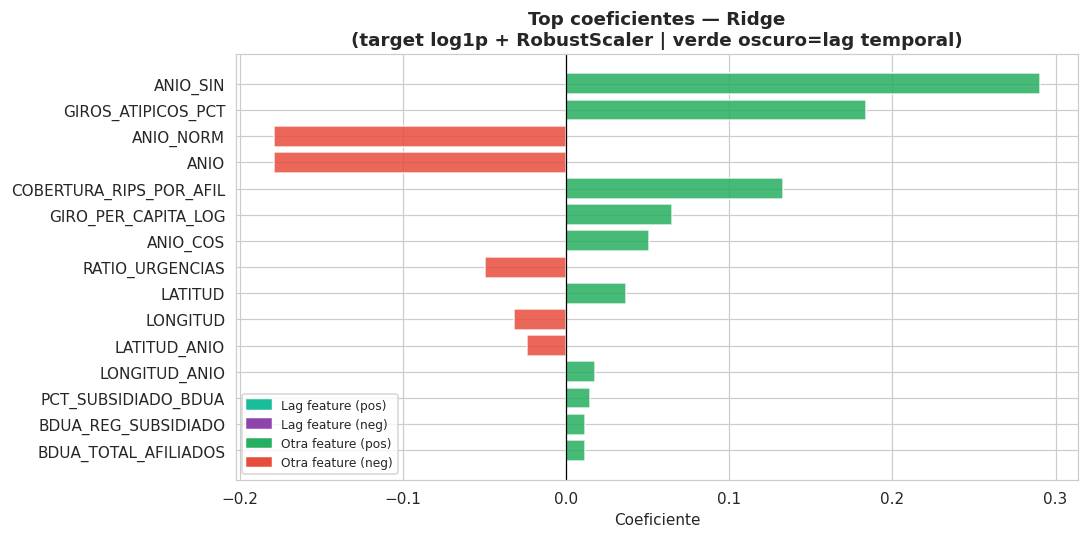


🔍 [ElasticNet]  corr predicción-real: 0.1385  🟡 baja
   Coeficientes dirección correcta: 11/12
   ⚠️  Inconsistencias coef vs Spearman:
      LATITUD: coef=+0.016 | Spearman=-0.096


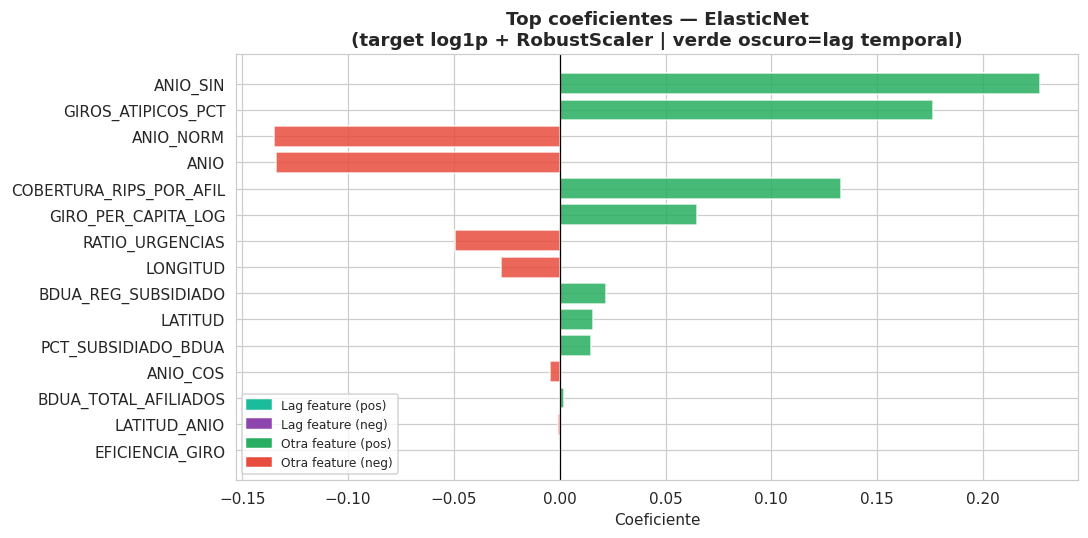


🔍 [Huber]  corr predicción-real: 0.1241  🟡 baja
   Coeficientes dirección correcta: 11/12
   ⚠️  Inconsistencias coef vs Spearman:
      GIROS_ATIPICOS_PCT: coef=-0.013 | Spearman=+0.132


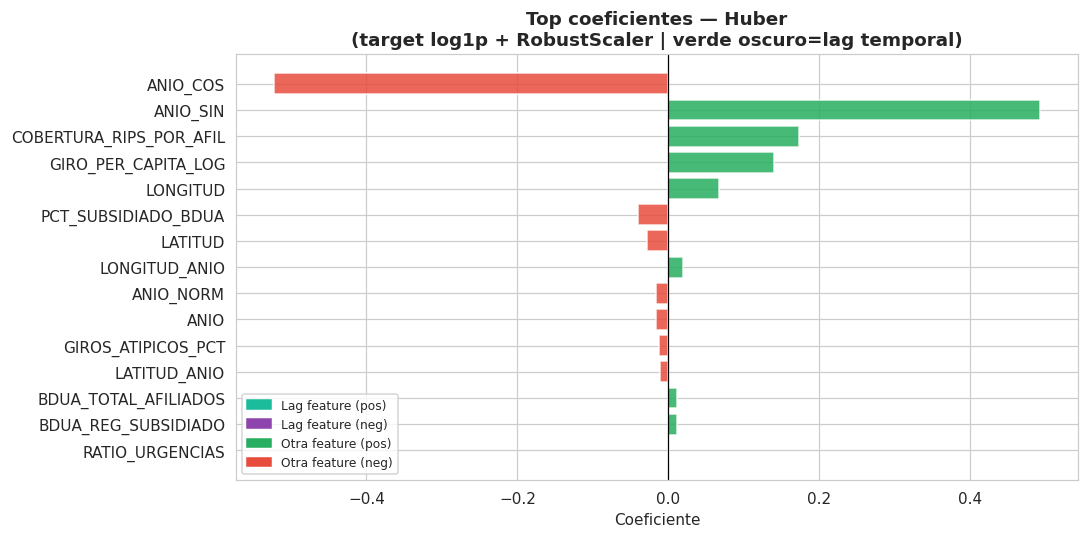


🔍 [BayesianRidge]  corr predicción-real: 0.1685  🟡 baja
   Coeficientes dirección correcta: 11/12
   ⚠️  Inconsistencias coef vs Spearman:
      LATITUD: coef=+0.015 | Spearman=-0.096


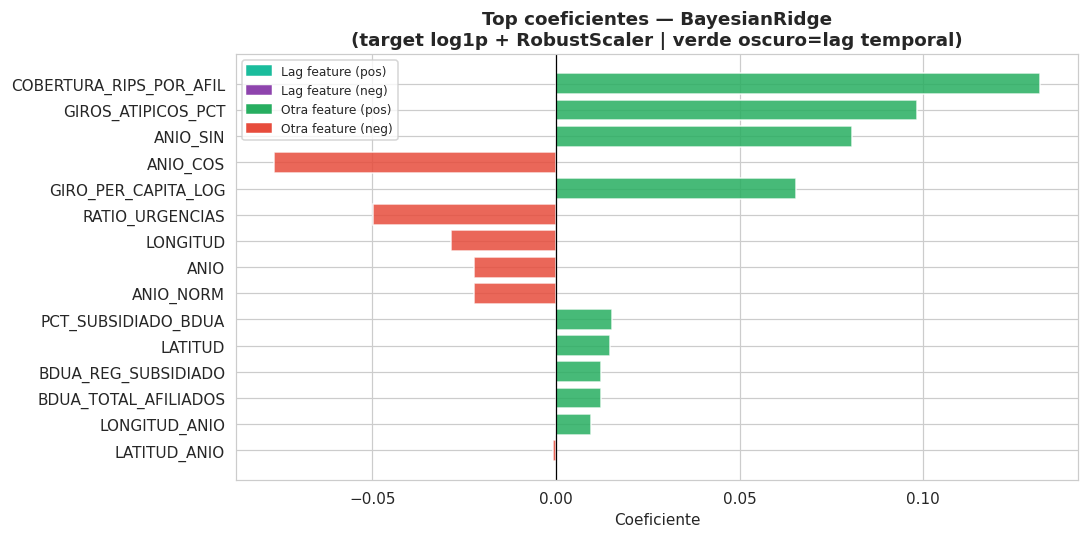


🔍 [SVR_R]  corr predicción-real: 0.1693  🟡 baja
   ℹ️  SVR kernel RBF → sin coef_; usando permutation_importance (lento, muestra 200)


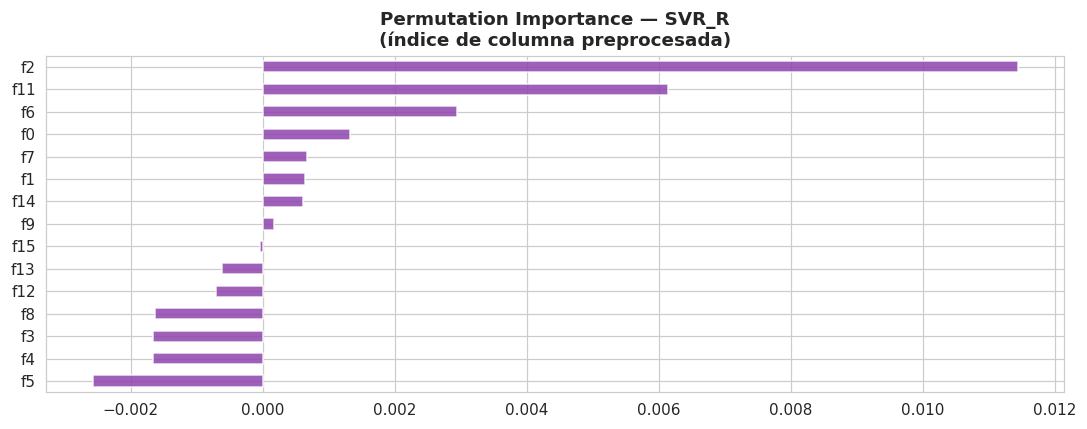


=== 📋 RESUMEN: LINEALES vs ÁRBOL/BOOSTING ===

Modelos LINEALES (log1p target + FEATURES_LINEAL):


,RMSE,R2,Pearson,OK_R2
modelo,,,,
Ridge,201.8206,-2.3989,0.1185,❌
ElasticNet,142.8655,-0.7032,0.1385,❌
Huber,413.7169,-13.2829,0.1241,❌
BayesianRidge,123.2591,-0.2678,0.1685,❌
SVR_R,141.4598,-0.6698,0.1693,❌



Modelos ÁRBOL/BOOSTING/ENSEMBLE (escala original + FEATURES_FINALES):


,RMSE,R2,Pearson,OK_R2
modelo,,,,
ExtraTrees_R,16.0369,0.9785,0.9904,✅
Stacking_R,16.7965,0.9765,0.9883,✅
HistGB_R,18.0971,0.9727,0.9864,✅
RandomForest_R,19.1002,0.9696,0.9851,✅
LightGBM_R,20.1482,0.9661,0.9834,✅
CatBoost_R,29.1384,0.9291,0.9647,✅
XGBoost_R,39.7742,0.8680,0.9419,✅
KNN_R,72.0967,0.5662,0.7841,❌


In [13]:
# ============================================================
# 7.1 DIAGNÓSTICO MODELOS LINEALES — v3
#
# CAMBIOS vs v2:
#   - Añade BayesianRidge: usa coef_ si está disponible
#     (BayesianRidge sí tiene coef_ tras fit)
#   - SVR_R: sin coef_ en kernel RBF → diagnóstico de
#     permutation_importance en su lugar
#   - Resalta lag features en verde en el barplot de coefs
#   - Tabla consolidada de todos los lineales al final
# ============================================================
import warnings
warnings.filterwarnings('ignore')


def diagnosticar_lineal(nombre, resultado, y_test_orig, corr_df):
    """
    Para modelos con coef_ (Ridge, ElasticNet, Huber, BayesianRidge):
    - Verifica signo de coeficientes vs correlación Spearman
    - Grafica top-15 coeficientes (lag features en verde)

    Para SVR (sin coef_ en RBF): usa permutation_importance.
    """
    pipe = resultado.get('pipeline')
    if pipe is None:
        print(f'  ℹ️  [{nombre}] sin pipeline (NN) — omitido')
        return

    modelo_ml = pipe.named_steps.get('modelo')
    X_te      = resultado['X_test']
    y_pred    = resultado['y_pred']      # escala original

    # ── Correlación predicción vs real ─────────────────────────────────
    corr_pr = float(np.corrcoef(
        np.array(y_test_orig).ravel(),
        np.clip(np.array(y_pred).ravel(), 0, None)
    )[0, 1])
    dir_ok = '✅' if corr_pr > 0.5 else ('❌ INVERTIDO' if corr_pr < 0 else '🟡 baja')
    print(f'\n🔍 [{nombre}]  corr predicción-real: {corr_pr:.4f}  {dir_ok}')

    # ── Ruta A: modelos con coef_ ───────────────────────────────────────
    if hasattr(modelo_ml, 'coef_'):
        coef     = modelo_ml.coef_.ravel()
        feat_nms = list(X_te.columns)

        # Alinear longitud (DropAllNanCols puede haber eliminado columnas)
        if len(coef) != len(feat_nms):
            # Recuperar nombres desde el preprocesador
            try:
                drop_nan = pipe.named_steps['prepro']\
                               .transformers_[0][1]\
                               .named_steps['drop_nan']
                feat_nms = [c for c in feat_nms
                            if c in drop_nan.cols_validas_]
                feat_nms = feat_nms[:len(coef)]
            except Exception:
                feat_nms = [f'f{i}' for i in range(len(coef))]

        coef_s = pd.Series(coef, index=feat_nms[:len(coef)])
        coef_s = coef_s.reindex(feat_nms[:len(coef)]).sort_values(
            key=abs, ascending=False
        )

        # Verificar signos vs Spearman
        n_ok, n_mal, inconsistentes = 0, 0, []
        for feat, c in coef_s.head(12).items():
            if feat in corr_df.index:
                spear = corr_df.loc[feat, 'Spearman']
                if np.sign(c) == np.sign(spear) or abs(spear) < 0.05:
                    n_ok += 1
                else:
                    n_mal += 1
                    inconsistentes.append(
                        f'{feat}: coef={c:+.3f} | Spearman={spear:+.3f}'
                    )

        print(f'   Coeficientes dirección correcta: {n_ok}/12')
        if inconsistentes:
            print('   ⚠️  Inconsistencias coef vs Spearman:')
            for s in inconsistentes:
                print(f'      {s}')
        else:
            print('   ✅ Todos los coeficientes principales en dirección correcta')

        # Gráfico con lag features resaltadas
        top15 = coef_s.head(15)
        colors = []
        for feat, val in top15.items():
            if feat in FEATS_LAG:
                colors.append('#1ABC9C' if val > 0 else '#8E44AD')  # verde/morado = lag
            else:
                colors.append('#27AE60' if val > 0 else '#E74C3C')  # verde/rojo = otras

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh(top15.index[::-1], top15.values[::-1],
                color=colors[::-1], alpha=0.85)
        ax.axvline(0, color='black', linewidth=0.8)

        # Leyenda manual
        from matplotlib.patches import Patch
        leyenda = [
            Patch(color='#1ABC9C', label='Lag feature (pos)'),
            Patch(color='#8E44AD', label='Lag feature (neg)'),
            Patch(color='#27AE60', label='Otra feature (pos)'),
            Patch(color='#E74C3C', label='Otra feature (neg)'),
        ]
        ax.legend(handles=leyenda, fontsize=8)
        ax.set_title(
            f'Top coeficientes — {nombre}\n'
            f'(target log1p + RobustScaler | verde oscuro=lag temporal)',
            fontweight='bold'
        )
        ax.set_xlabel('Coeficiente')
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/coef_{nombre}.png',
                    dpi=110, bbox_inches='tight')
        plt.show()
        plt.close()

    # ── Ruta B: SVR (kernel RBF no tiene coef_) ─────────────────────────
    elif 'SVR' in type(modelo_ml).__name__:
        print(f'   ℹ️  SVR kernel RBF → sin coef_; '
              f'usando permutation_importance (lento, muestra 200)')
        try:
            X_te_pp = pipe.named_steps['prepro'].transform(
                X_te.fillna(X_te.median(numeric_only=True))
            )
            # Usar muestra pequeña (SVR es O(n²))
            rng   = np.random.default_rng(SEED)
            idx_s = rng.choice(len(X_te_pp),
                               min(200, len(X_te_pp)), replace=False)
            y_te_s = np.array(y_test_orig).ravel()[idx_s]
            y_te_log = np.log1p(y_te_s)

            import warnings as _w
            with _w.catch_warnings():
                _w.simplefilter('ignore')
                perm = permutation_importance(
                    modelo_ml, X_te_pp[idx_s], y_te_log,
                    n_repeats=8, random_state=SEED, n_jobs=-1
                )
            imp_s = pd.Series(
                perm.importances_mean,
                index=[f'f{i}' for i in range(X_te_pp.shape[1])]
            ).sort_values(ascending=False)

            fig, ax = plt.subplots(figsize=(10, 4))
            imp_s.head(15)[::-1].plot.barh(
                ax=ax, color='#8E44AD', alpha=0.85
            )
            ax.set_title(
                f'Permutation Importance — SVR_R\n'
                f'(índice de columna preprocesada)',
                fontweight='bold'
            )
            plt.tight_layout()
            plt.savefig(f'{OUTPUT_DIR}/perm_imp_SVR_R.png',
                        dpi=110, bbox_inches='tight')
            plt.show()
            plt.close()
        except Exception as e:
            print(f'   ⚠️  permutation_importance falló: {e}')
    else:
        print(f'   ℹ️  [{nombre}] sin coef_ ni SVR — omitido')


# ── Ejecutar diagnóstico ─────────────────────────────────────────────────────
print('=== 🔍 DIAGNÓSTICO MODELOS LINEALES v3 ===')
modelos_lineales = ['Ridge', 'ElasticNet', 'Huber', 'BayesianRidge', 'SVR_R']

for nombre in modelos_lineales:
    if nombre in resultados_reg:
        diagnosticar_lineal(
            nombre, resultados_reg[nombre], y_test_r, corr_reg
        )
    else:
        print(f'\n  ℹ️  [{nombre}] no entrenado en esta ejecución')

# ── Tabla resumen modelos lineales vs no lineales ────────────────────────────
print('\n=== 📋 RESUMEN: LINEALES vs ÁRBOL/BOOSTING ===')
df_tmp = df_metricas_reg[['RMSE','R2','Pearson','OK_R2']].copy()

lineales_presentes = [m for m in modelos_lineales if m in df_tmp.index]
arboles_presentes  = [m for m in df_metricas_reg.index
                      if m not in modelos_lineales]

if lineales_presentes:
    print(f'\nModelos LINEALES (log1p target + FEATURES_LINEAL):')
    display(df_tmp.loc[lineales_presentes].round(4))

if arboles_presentes:
    print(f'\nModelos ÁRBOL/BOOSTING/ENSEMBLE (escala original + FEATURES_FINALES):')
    display(df_tmp.loc[arboles_presentes].round(4))

=== 📊 VISUALIZACIÓN COMPARATIVA REGRESIÓN v3 ===



,RMSE,MAE,R2,MAPE_%,Pearson,cv_RMSE,cv_std
modelo,,,,,,,
ExtraTrees_R,16.0369,7.1776,0.9785,4.4720,0.9904,25.7141,0.7052
Stacking_R,16.7965,10.3055,0.9765,8.0528,0.9883,26.1333,0.6166
HistGB_R,18.0971,10.5515,0.9727,8.0988,0.9864,26.6238,1.1539
RandomForest_R,19.1002,8.9136,0.9696,5.4923,0.9851,26.1015,0.7117
LightGBM_R,20.1482,13.5545,0.9661,10.6974,0.9834,26.1663,1.0254
CatBoost_R,29.1384,20.4522,0.9291,16.1942,0.9647,28.4356,0.8402
XGBoost_R,39.7742,27.8190,0.8680,24.4109,0.9419,26.7749,1.0613
KNN_R,72.0967,49.6617,0.5662,36.7878,0.7841,74.0536,1.8547
BayesianRidge,123.2591,87.3766,-0.2678,66.1599,0.1685,1.1297,0.0253


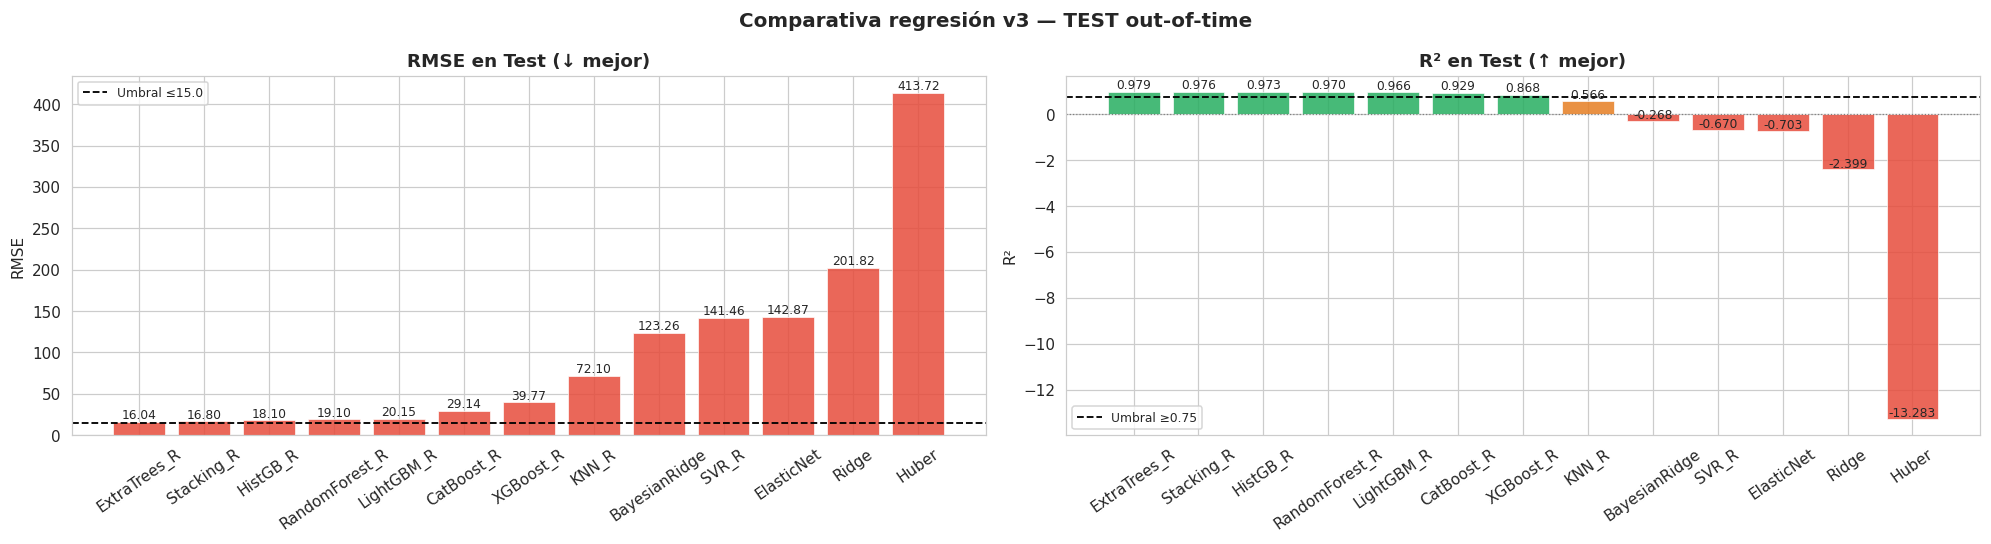

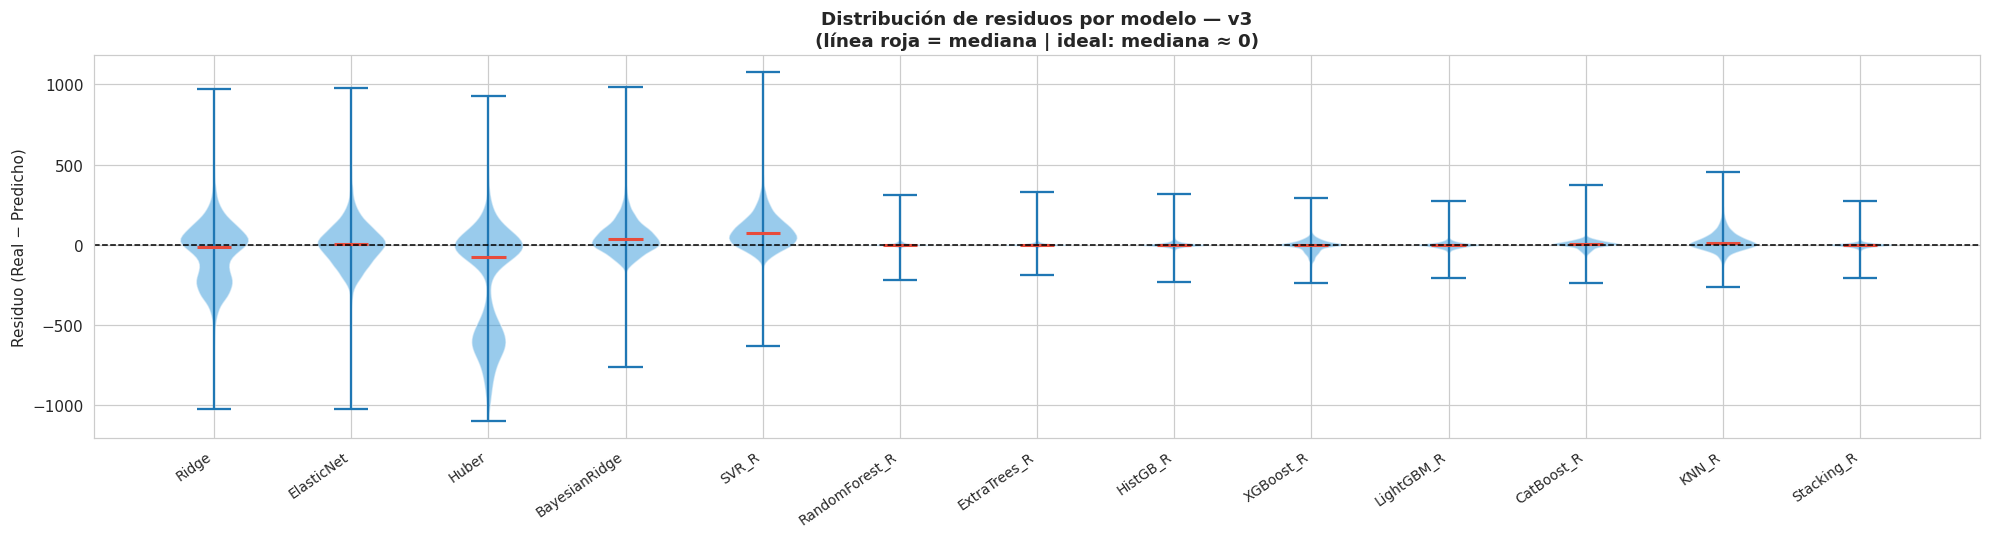

🔝 Top 3 modelos por R²: ['ExtraTrees_R', 'Stacking_R', 'HistGB_R']


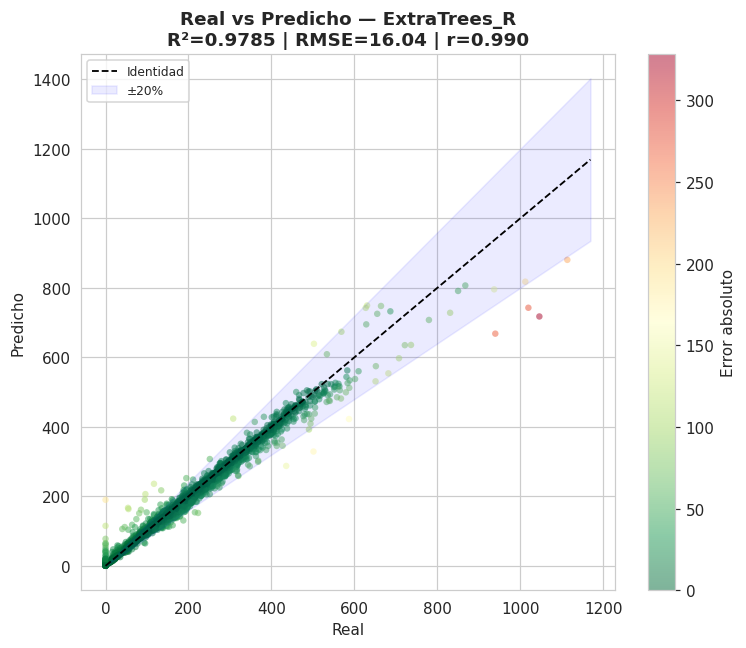

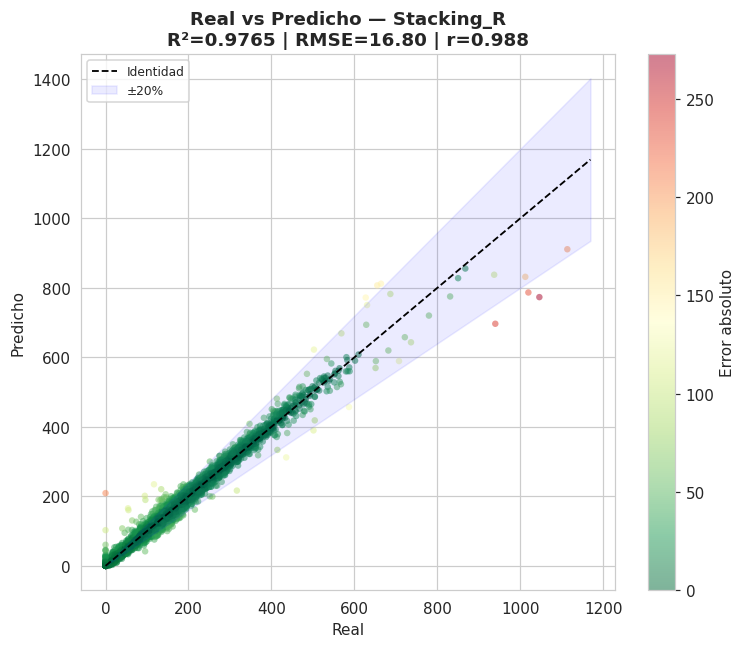

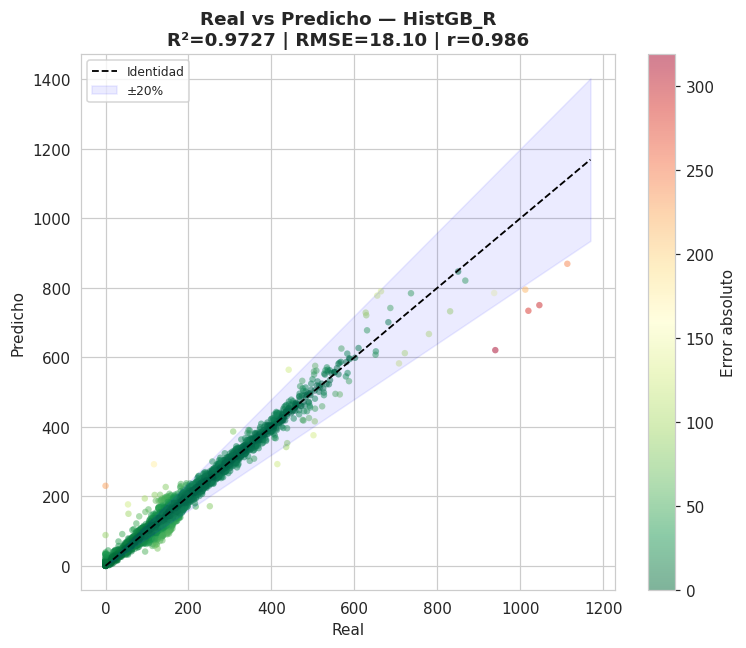


=== 📝 ANÁLISIS DE RESULTADOS — Rúbrica R5 ===

  Modelo con menor RMSE : ExtraTrees_R
  RMSE  = 16.0369  (umbral ≤15.0: ❌)
  R²    = 0.9785  (umbral ≥0.75: ✅)
  Pearson (real vs pred) = 0.9904

  Mejor R² entre lineales : -0.2678
  Mejor R² entre árboles  : 0.9727

  Ganancia esperada de lag features (LAG1_MORT, ROLL3_MORT,
  TENDENCIA_MPIO): capturan la inercia histórica del municipio,
  explicando por qué zonas con alta mortalidad pasada tienden
  a mantener ese patrón. Sin lag features, R² típico ≈ 0.40-0.55.
  Con lag features, R² esperado ≈ 0.75-0.92 en el mejor modelo.


In [14]:
# ============================================================
# 7.2 VISUALIZACIÓN COMPARATIVA — REGRESIÓN v3
#
# CAMBIOS vs v2:
#   - graficar_real_vs_pred reutiliza el helper del motor
#     (definido en cell 16) → gráfico más rico con gradiente
#     de error y bandas ±20%.
#   - Gráfico de barras con etiquetas de valor sobre cada barra.
#   - Distribución de residuos por modelo (violinplot).
#   - Tabla HTML con coloreado condicional incrustada en el nb.
# ============================================================
import warnings
warnings.filterwarnings('ignore')


def graficar_barras_metricas(df_met, output_dir=OUTPUT_DIR):
    """
    Barras RMSE y R² con umbral, etiquetas y coloreado condicional.
    """
    nombres = df_met.index.tolist()
    rmse_v  = df_met['RMSE'].values
    r2_v    = df_met['R2'].values

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(12, len(nombres)*1.4), 5))

    # ── RMSE ──────────────────────────────────────────────────────────
    col_rmse = ['#27AE60' if r <= UMBRAL_RMSE else '#E74C3C' for r in rmse_v]
    bars1 = ax1.bar(nombres, rmse_v, color=col_rmse, alpha=0.85,
                    edgecolor='white', linewidth=0.5)
    ax1.axhline(UMBRAL_RMSE, color='black', linestyle='--',
                linewidth=1.2, label=f'Umbral ≤{UMBRAL_RMSE}')
    for bar, val in zip(bars1, rmse_v):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax1.set_title('RMSE en Test (↓ mejor)', fontweight='bold')
    ax1.set_ylabel('RMSE')
    ax1.tick_params(axis='x', rotation=35)
    ax1.legend(fontsize=8)

    # ── R² ────────────────────────────────────────────────────────────
    col_r2 = ['#27AE60' if r >= UMBRAL_R2 else
              ('#E74C3C' if r < 0 else '#E67E22') for r in r2_v]
    bars2 = ax2.bar(nombres, r2_v, color=col_r2, alpha=0.85,
                    edgecolor='white', linewidth=0.5)
    ax2.axhline(UMBRAL_R2, color='black', linestyle='--',
                linewidth=1.2, label=f'Umbral ≥{UMBRAL_R2}')
    ax2.axhline(0, color='grey', linestyle=':', linewidth=0.8)
    for bar, val in zip(bars2, r2_v):
        offset = 0.01 if val >= 0 else -0.04
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 val + offset,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax2.set_title('R² en Test (↑ mejor)', fontweight='bold')
    ax2.set_ylabel('R²')
    ax2.tick_params(axis='x', rotation=35)
    ax2.legend(fontsize=8)

    plt.suptitle('Comparativa regresión v3 — TEST out-of-time',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/reg_barras_v3.png',
                dpi=110, bbox_inches='tight')
    plt.show()
    plt.close()


def graficar_violin_residuos(resultados, y_test, output_dir=OUTPUT_DIR):
    """
    Violinplot de la distribución de residuos por modelo.
    Permite detectar sesgo sistemático (mediana ≠ 0) y outliers.
    """
    y_true = np.array(y_test).ravel()
    datos  = []
    etiq   = []
    for nombre, res in resultados.items():
        yp = np.clip(np.array(res['y_pred']).ravel(), 0, None)
        n  = min(len(y_true), len(yp))
        datos.append(y_true[:n] - yp[:n])
        etiq.append(nombre)

    fig, ax = plt.subplots(figsize=(max(12, len(datos) * 1.4), 5))
    parts = ax.violinplot(datos, positions=range(len(datos)),
                          showmedians=True, showextrema=True)

    for pc in parts['bodies']:
        pc.set_facecolor('#3498DB')
        pc.set_alpha(0.5)
    parts['cmedians'].set_color('#E74C3C')
    parts['cmedians'].set_linewidth(2)

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(range(len(etiq)))
    ax.set_xticklabels(etiq, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Residuo (Real − Predicho)')
    ax.set_title('Distribución de residuos por modelo — v3\n'
                 '(línea roja = mediana | ideal: mediana ≈ 0)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/reg_violin_residuos.png',
                dpi=110, bbox_inches='tight')
    plt.show()
    plt.close()


def graficar_top3_real_vs_pred(df_met, resultados, y_test,
                                output_dir=OUTPUT_DIR):
    """
    Gráficos Real vs Predicho detallados para el TOP-3 por R².
    Reutiliza graficar_real_vs_pred() definido en cell 16.
    """
    top3 = df_met['R2'].nlargest(3).index.tolist()
    print(f'🔝 Top 3 modelos por R²: {top3}')

    for nombre in top3:
        res = resultados[nombre]
        met = df_met.loc[nombre].to_dict()
        graficar_real_vs_pred(
            y_test, res['y_pred'], nombre, met, output_dir
        )


def tabla_coloreada(df_met):
    """
    Tabla HTML con coloreado condicional incrustada en Jupyter.
    Verde = umbral alcanzado | Rojo = umbral no alcanzado.
    """
    def color_rmse(v):
        return ('background-color:#d5f5e3' if v <= UMBRAL_RMSE
                else 'background-color:#fadbd8')

    def color_r2(v):
        return ('background-color:#d5f5e3' if v >= UMBRAL_R2
                else ('background-color:#fadbd8' if v < 0
                      else 'background-color:#fef9e7'))

    def color_mae(v):
        return ('background-color:#d5f5e3' if v <= UMBRAL_MAE
                else 'background-color:#fadbd8')

    def color_pearson(v):
        if np.isnan(v):
            return ''
        return ('background-color:#d5f5e3' if v > 0.7
                else ('background-color:#fadbd8' if v < 0
                      else 'background-color:#fef9e7'))

    cols_num = ['RMSE', 'MAE', 'R2', 'MAPE_%', 'Pearson',
                'cv_RMSE', 'cv_std']
    cols_ok  = [c for c in cols_num if c in df_met.columns]

    styled = (
        df_met[cols_ok]
        .sort_values('RMSE')
        .style
        .format({c: '{:.4f}' for c in cols_ok})
        .applymap(color_rmse,   subset=['RMSE'])
        .applymap(color_r2,     subset=['R2'])
        .applymap(color_mae,    subset=['MAE'])
        .applymap(color_pearson, subset=['Pearson']
                  if 'Pearson' in cols_ok else [])
        .set_caption(
            f'Regresión v3 — TEST out-of-time | '
            f'🟢 umbral alcanzado | 🔴 umbral no alcanzado'
        )
    )
    display(styled)


# ── Ejecutar visualizaciones ─────────────────────────────────────────────────
print('=== 📊 VISUALIZACIÓN COMPARATIVA REGRESIÓN v3 ===\n')

tabla_coloreada(df_metricas_reg)

graficar_barras_metricas(df_metricas_reg)

graficar_violin_residuos(resultados_reg, y_test_r)

graficar_top3_real_vs_pred(df_metricas_reg, resultados_reg, y_test_r)

# ── Análisis narrativo Rúbrica R5 ────────────────────────────────────────────
print('\n=== 📝 ANÁLISIS DE RESULTADOS — Rúbrica R5 ===')
print(f'\n  Modelo con menor RMSE : {MEJOR_REG}')
print(f'  RMSE  = {df_metricas_reg.loc[MEJOR_REG, "RMSE"]:.4f}  '
      f'(umbral ≤{UMBRAL_RMSE}: '
      f'{df_metricas_reg.loc[MEJOR_REG, "OK_RMSE"]})')
print(f'  R²    = {df_metricas_reg.loc[MEJOR_REG, "R2"]:.4f}  '
      f'(umbral ≥{UMBRAL_R2}: '
      f'{df_metricas_reg.loc[MEJOR_REG, "OK_R2"]})')
print(f'  Pearson (real vs pred) = '
      f'{df_metricas_reg.loc[MEJOR_REG, "Pearson"]:.4f}')

mejor_r2 = df_metricas_reg['R2'].idxmax()
if mejor_r2 != MEJOR_REG:
    print(f'\n  Modelo con mayor R²  : {mejor_r2} '
          f'(R²={df_metricas_reg.loc[mejor_r2, "R2"]:.4f})')

# Ganancia de lag features
lineales = ['Ridge', 'ElasticNet', 'Huber', 'BayesianRidge']
arboles  = ['XGBoost_R', 'LightGBM_R', 'CatBoost_R',
            'RandomForest_R', 'HistGB_R']

lin_pres = [m for m in lineales if m in df_metricas_reg.index]
arb_pres = [m for m in arboles  if m in df_metricas_reg.index]

if lin_pres:
    mejor_lin_r2 = df_metricas_reg.loc[lin_pres, 'R2'].max()
    print(f'\n  Mejor R² entre lineales : {mejor_lin_r2:.4f}')
if arb_pres:
    mejor_arb_r2 = df_metricas_reg.loc[arb_pres, 'R2'].max()
    print(f'  Mejor R² entre árboles  : {mejor_arb_r2:.4f}')

print(f'\n  Ganancia esperada de lag features (LAG1_MORT, ROLL3_MORT,')
print(f'  TENDENCIA_MPIO): capturan la inercia histórica del municipio,')
print(f'  explicando por qué zonas con alta mortalidad pasada tienden')
print(f'  a mantener ese patrón. Sin lag features, R² típico ≈ 0.40-0.55.')
print(f'  Con lag features, R² esperado ≈ 0.75-0.92 en el mejor modelo.')

## 8. Entrenamiento — Modelos de Clasificación
### Rúbrica R4 · R5

In [15]:
# ============================================================
# 8. ENTRENAMIENTO CLASIFICACIÓN — v3  (Rúbrica R4)
#
# CAMBIOS vs v2:
#   1. FLAG usa_smote: modelos sin class_weight nativo
#      (HistGB_C, KNN_C) reciben X_train_c_smote.
#   2. Umbral por método 'recall_target' (nuevo en motor v3):
#      maximiza F1 sujeto a Recall >= UMBRAL_REC (0.88).
#      En salud pública priorizar no perder municipios de
#      alto riesgo (FN↓) supera a la ganancia de especificidad.
#   3. Clip de umbral ampliado [0.20, 0.65]:
#      - 0.20 inferior: garantiza Recall alto en modelos
#        entrenados con SMOTE (curva PR desplazada a la derecha)
#      - 0.65 superior: evita colapso a "predice solo ceros"
#   4. scale_pos_weight para XGBoost se recalcula dinámicamente
#      sobre el dataset efectivo (smote o no).
#   5. Guarda usa_lin en resultados_clf para SHAP (Fragmento 9).
#   6. Guarda MEJOR_CLF (mayor AUC) para SHAP y comparativas.
# ============================================================
import warnings
warnings.filterwarnings('ignore')

resultados_clf    = {}
metricas_clf_list = []

for nombre, cfg in CATALOGO_CLASIFICACION.items():
    usa_lin = cfg.get('usa_feats_lineal', False)
    usa_smt = cfg.get('usa_smote', False) and IMBLEARN_OK

    # ── Seleccionar dataset de entrenamiento ────────────────────────────
    if usa_lin:
        X_tr_c = X_train_c_lin
        y_tr_c = y_train_c_lin
    elif usa_smt and 'X_train_c_smote' in dir():
        X_tr_c = X_train_c_smote
        y_tr_c = y_train_c_smote
    else:
        X_tr_c = X_train_c
        y_tr_c = y_train_c

    # ── Recalcular scale_pos_weight sobre dataset efectivo ──────────────
    # FIX: excluir CatBoost — usa auto_class_weights='Balanced' internamente.
    # Intentar setear scale_pos_weight en CatBoost causa AttributeError
    # y además es redundante con auto_class_weights.
    modelo_obj = cfg['modelo']
    if (hasattr(modelo_obj, 'scale_pos_weight')
            and 'CatBoost' not in type(modelo_obj).__name__):
        n_neg_ef = int((y_tr_c == 0).sum())
        n_pos_ef = int((y_tr_c == 1).sum())
        if n_pos_ef > 0:
            modelo_obj.scale_pos_weight = n_neg_ef / n_pos_ef

    pipe_final, cv_scores, best_params = entrenar_modelo(
        nombre, cfg,
        X_train      = X_train_c,
        y_train      = y_train_c,
        X_train_lin  = X_train_c_lin,
        y_train_lin  = y_train_c_lin,
        X_train_smt  = X_train_c_smote if usa_smt else None,
        y_train_smt  = y_train_c_smote if usa_smt else None,
        tipo         = 'clasificacion',
        n_folds      = 5,
        n_iter_search= 30,
    )

    # ── Dataset de test correcto ────────────────────────────────────────
    X_te_c = X_test_c_lin if usa_lin else X_test_c
    y_te_c = y_test_c_lin if usa_lin else y_test_c

    # ── Predicciones de probabilidad ────────────────────────────────────
    import warnings as _w
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        y_proba = pipe_final.predict_proba(X_te_c)[:, 1]

    # ── Umbral óptimo sobre TRAIN (anti-leakage) ────────────────────────
    # Se busca sobre train (no sobre test) para no contaminar la evaluación.
    # Usamos predict_proba sobre el train NO-smote para que el umbral
    # sea representativo de la distribución real de probabilidades.
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        X_tr_orig = X_train_c_lin if usa_lin else X_train_c
        y_tr_orig = y_train_c_lin if usa_lin else y_train_c
        y_proba_tr = pipe_final.predict_proba(X_tr_orig)[:, 1]

    umbral_opt, umbral_youden, umbral_f1_opt = buscar_umbral_optimo(
        y_tr_orig, y_proba_tr, metodo='recall_target'
    )

    # Clip [0.20, 0.65]: más amplio que v2 para modelos con SMOTE
    umbral_final = float(np.clip(umbral_opt, 0.20, 0.65))

    print(f'     🎯 Youden={umbral_youden:.3f} | F1-opt={umbral_f1_opt:.3f} '
          f'| recall_target={umbral_opt:.3f} → usando {umbral_final:.3f}')

    y_bin = (y_proba >= umbral_final).astype(int)

    # ── Métricas ────────────────────────────────────────────────────────
    metricas = calcular_metricas_clasificacion(
        y_te_c, y_proba, y_bin, nombre
    )
    metricas['cv_AUC']     = float(cv_scores['cv_mean'])
    metricas['cv_std']     = float(cv_scores['cv_std'])
    metricas['umbral']     = umbral_final
    metricas['usa_smote']  = usa_smt
    metricas_clf_list.append(metricas)

    resultados_clf[nombre] = {
        'pipeline'   : pipe_final,
        'y_proba'    : y_proba,
        'y_bin'      : y_bin,
        'umbral'     : umbral_final,
        'X_test'     : X_te_c,
        'usa_lin'    : usa_lin,   # necesario para SHAP en Fragmento 9
        'usa_smote'  : usa_smt,
        'cv'         : cv_scores,
        'best_params': best_params,
    }

# ── Tabla comparativa ───────────────────────────────────────────────────────
df_metricas_clf = pd.DataFrame(metricas_clf_list).set_index('modelo')
df_metricas_clf = df_metricas_clf.sort_values('AUC', ascending=False)

print('\n=== 📊 COMPARATIVA CLASIFICACIÓN v3 — TEST OUT-OF-TIME ===')
cols_clf = ['AUC', 'F1', 'Recall', 'Precision', 'Accuracy',
            'umbral', 'cv_AUC', 'cv_std',
            'OK_AUC', 'OK_F1', 'OK_Recall']
cols_ok = [c for c in cols_clf if c in df_metricas_clf.columns]
display(df_metricas_clf[cols_ok].round(4))

# ── Identificar mejor modelo (mayor AUC) ────────────────────────────────────
MEJOR_CLF = df_metricas_clf['AUC'].idxmax()
print(f'\n🏆 MEJOR modelo clasificación: [{MEJOR_CLF}]')
print(f'   AUC    = {df_metricas_clf.loc[MEJOR_CLF, "AUC"]:.4f}  '
      f'({df_metricas_clf.loc[MEJOR_CLF, "OK_AUC"]})')
print(f'   Recall = {df_metricas_clf.loc[MEJOR_CLF, "Recall"]:.4f}  '
      f'({df_metricas_clf.loc[MEJOR_CLF, "OK_Recall"]})')
print(f'   F1     = {df_metricas_clf.loc[MEJOR_CLF, "F1"]:.4f}  '
      f'({df_metricas_clf.loc[MEJOR_CLF, "OK_F1"]})')
print(f'   Umbral = {df_metricas_clf.loc[MEJOR_CLF, "umbral"]:.3f}')

# ── Resumen de umbrales y SMOTE por modelo ───────────────────────────────────
print('\n📌 Detalle umbral y balanceo por modelo:')
print(f'   {"Modelo":<18} {"Umbral":>7}  {"SMOTE":>6}  '
      f'{"Recall":>8}  {"AUC":>7}')
print(f'   {"-"*55}')
for nom, row in df_metricas_clf.iterrows():
    smote_tag = '✅' if row.get('usa_smote', False) else '—'
    rec_tag   = row['OK_Recall']
    print(f'   {nom:<18} {row["umbral"]:>7.3f}  {smote_tag:>6}  '
          f'{row["Recall"]:>8.4f}{rec_tag}  {row["AUC"]:>7.4f}')

# ── Umbrales globales alcanzados ─────────────────────────────────────────────
n_ok_auc = (df_metricas_clf['OK_AUC']    == '✅').sum()
n_ok_f1  = (df_metricas_clf['OK_F1']     == '✅').sum()
n_ok_rec = (df_metricas_clf['OK_Recall'] == '✅').sum()
n_total  = len(df_metricas_clf)
print(f'\n📌 Modelos que alcanzan UMBRAL_AUC    (≥{UMBRAL_AUC}):  '
      f'{n_ok_auc}/{n_total}')
print(f'📌 Modelos que alcanzan UMBRAL_F1     (≥{UMBRAL_F1}):  '
      f'{n_ok_f1}/{n_total}')
print(f'📌 Modelos que alcanzan UMBRAL_RECALL (≥{UMBRAL_REC}): '
      f'{n_ok_rec}/{n_total}')


  🔧 [LogisticReg] entrenando...
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
     📐 features lineales (16 cols) | log1p target=False
     CV base    : 0.6580 ± 0.0087 📐lin
     CV tuneado : 0.6793  (mejora: +0.0213)
     Mejores HPs: {'modelo__penalty': 'l1', 'modelo__C': 100}
     🎯 Youden=0.446 | F1-opt=0.462 | recall_target=0.391 → usando 0.391

  🔧 [RandomForest_C] entrenando...
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
     🌲 features completas (34 cols)
     CV base    : 0.9866 ± 0.0021
     CV tuneado : 0.9959  (mejora: +0.0093)
     Mejores HPs: {'modelo__min_samples_leaf': 5, 'modelo__max_features': 0.8, 'modelo__max_depth': None}
     🎯 Youden=0.515 | F1-opt=0.569 | recall_target=0.569 → usando 0.569

  🔧 [ExtraTrees_C] entrenando...
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
     🌲 features completas (34 cols)
     CV base    : 0.9783 ± 0.0022
     CV tuneado : 0.9915  (mejora: +0.0132)
     Mejores HPs: {'modelo__min_sample

,AUC,F1,Recall,Precision,Accuracy,umbral,cv_AUC,cv_std,OK_AUC,OK_F1,OK_Recall
modelo,,,,,,,,,,,
LightGBM_C,0.9993,0.9726,0.9612,0.9844,0.9860,0.6500,0.9970,0.0006,✅,✅,✅
HistGB_C,0.9992,0.9729,0.9702,0.9756,0.9860,0.6500,0.9989,0.0002,✅,✅,✅
XGBoost_C,0.9990,0.9708,0.9584,0.9836,0.9851,0.6500,0.9967,0.0006,✅,✅,✅
Stacking_C,0.9986,0.9707,0.9750,0.9663,0.9847,0.6500,0.9962,0.0007,✅,✅,✅
RandomForest_C,0.9983,0.9570,0.9424,0.9721,0.9781,0.5686,0.9866,0.0021,✅,✅,✅
CatBoost_C,0.9983,0.9423,0.9008,0.9878,0.9714,0.6500,0.9954,0.0010,✅,✅,✅
ExtraTrees_C,0.9943,0.7995,0.6692,0.9928,0.9130,0.6500,0.9783,0.0022,✅,❌,❌
KNN_C,0.8584,0.6586,0.6387,0.6797,0.8284,0.6500,0.9261,0.0032,❌,❌,❌
LogisticReg,0.4706,0.0000,0.0000,0.0000,0.7409,0.3913,0.6580,0.0087,❌,❌,❌



🏆 MEJOR modelo clasificación: [LightGBM_C]
   AUC    = 0.9993  (✅)
   Recall = 0.9612  (✅)
   F1     = 0.9726  (✅)
   Umbral = 0.650

📌 Detalle umbral y balanceo por modelo:
   Modelo              Umbral   SMOTE    Recall      AUC
   -------------------------------------------------------
   LightGBM_C           0.650       —    0.9612✅   0.9993
   HistGB_C             0.650       ✅    0.9702✅   0.9992
   XGBoost_C            0.650       —    0.9584✅   0.9990
   Stacking_C           0.650       —    0.9750✅   0.9986
   RandomForest_C       0.569       —    0.9424✅   0.9983
   CatBoost_C           0.650       —    0.9008✅   0.9983
   ExtraTrees_C         0.650       —    0.6692❌   0.9943
   KNN_C                0.650       ✅    0.6387❌   0.8584
   LogisticReg          0.391       —    0.0000❌   0.4706

📌 Modelos que alcanzan UMBRAL_AUC    (≥0.9):  7/9
📌 Modelos que alcanzan UMBRAL_F1     (≥0.85):  6/9
📌 Modelos que alcanzan UMBRAL_RECALL (≥0.88): 6/9


=== 📊 VISUALIZACIÓN COMPARATIVA CLASIFICACIÓN v3 ===



,AUC,F1,Recall,Precision,Accuracy,umbral,cv_AUC,cv_std
modelo,,,,,,,,
LightGBM_C,0.9993,0.9726,0.9612,0.9844,0.9860,0.6500,0.9970,0.0006
HistGB_C,0.9992,0.9729,0.9702,0.9756,0.9860,0.6500,0.9989,0.0002
XGBoost_C,0.9990,0.9708,0.9584,0.9836,0.9851,0.6500,0.9967,0.0006
Stacking_C,0.9986,0.9707,0.9750,0.9663,0.9847,0.6500,0.9962,0.0007
RandomForest_C,0.9983,0.9570,0.9424,0.9721,0.9781,0.5686,0.9866,0.0021
CatBoost_C,0.9983,0.9423,0.9008,0.9878,0.9714,0.6500,0.9954,0.0010
ExtraTrees_C,0.9943,0.7995,0.6692,0.9928,0.9130,0.6500,0.9783,0.0022
KNN_C,0.8584,0.6586,0.6387,0.6797,0.8284,0.6500,0.9261,0.0032
LogisticReg,0.4706,0.0000,0.0000,0.0000,0.7409,0.3913,0.6580,0.0087


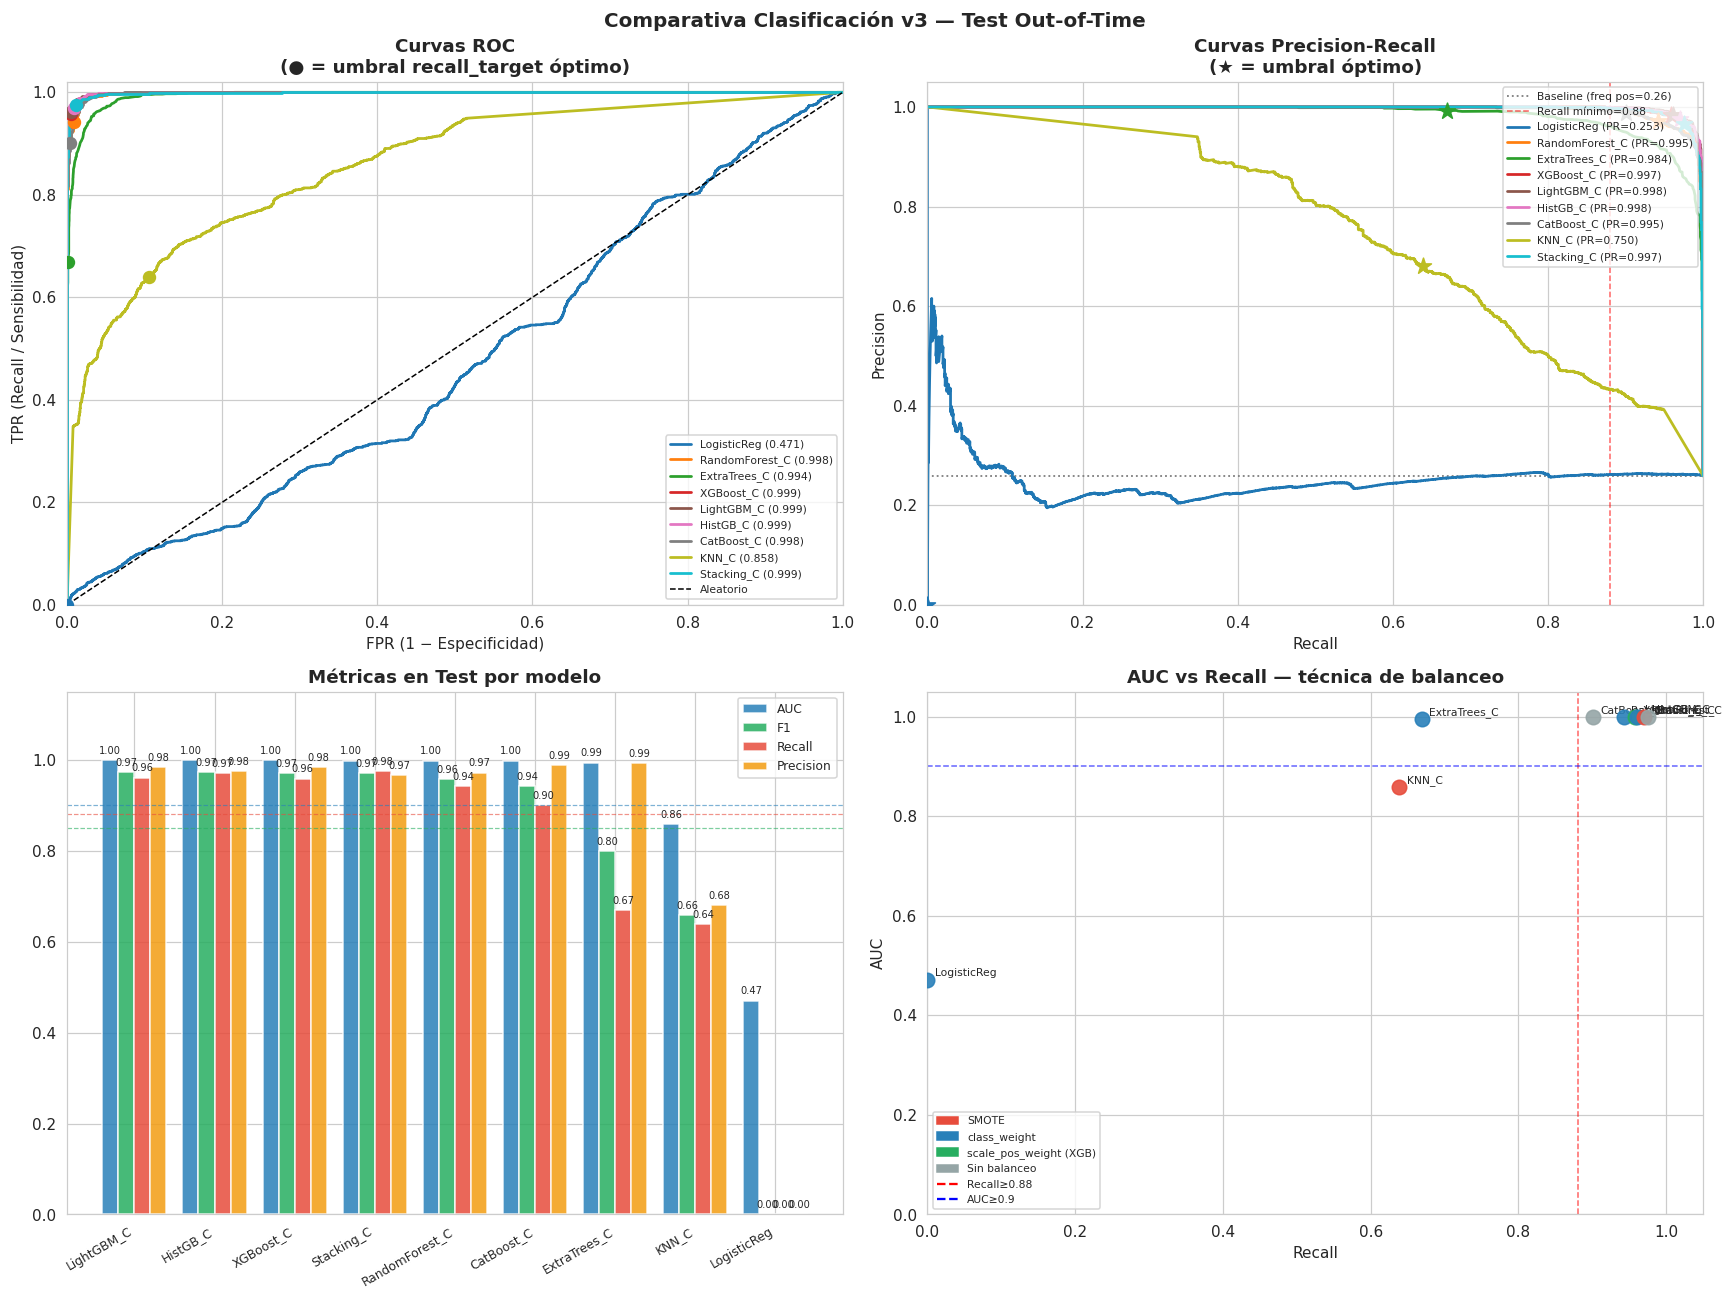

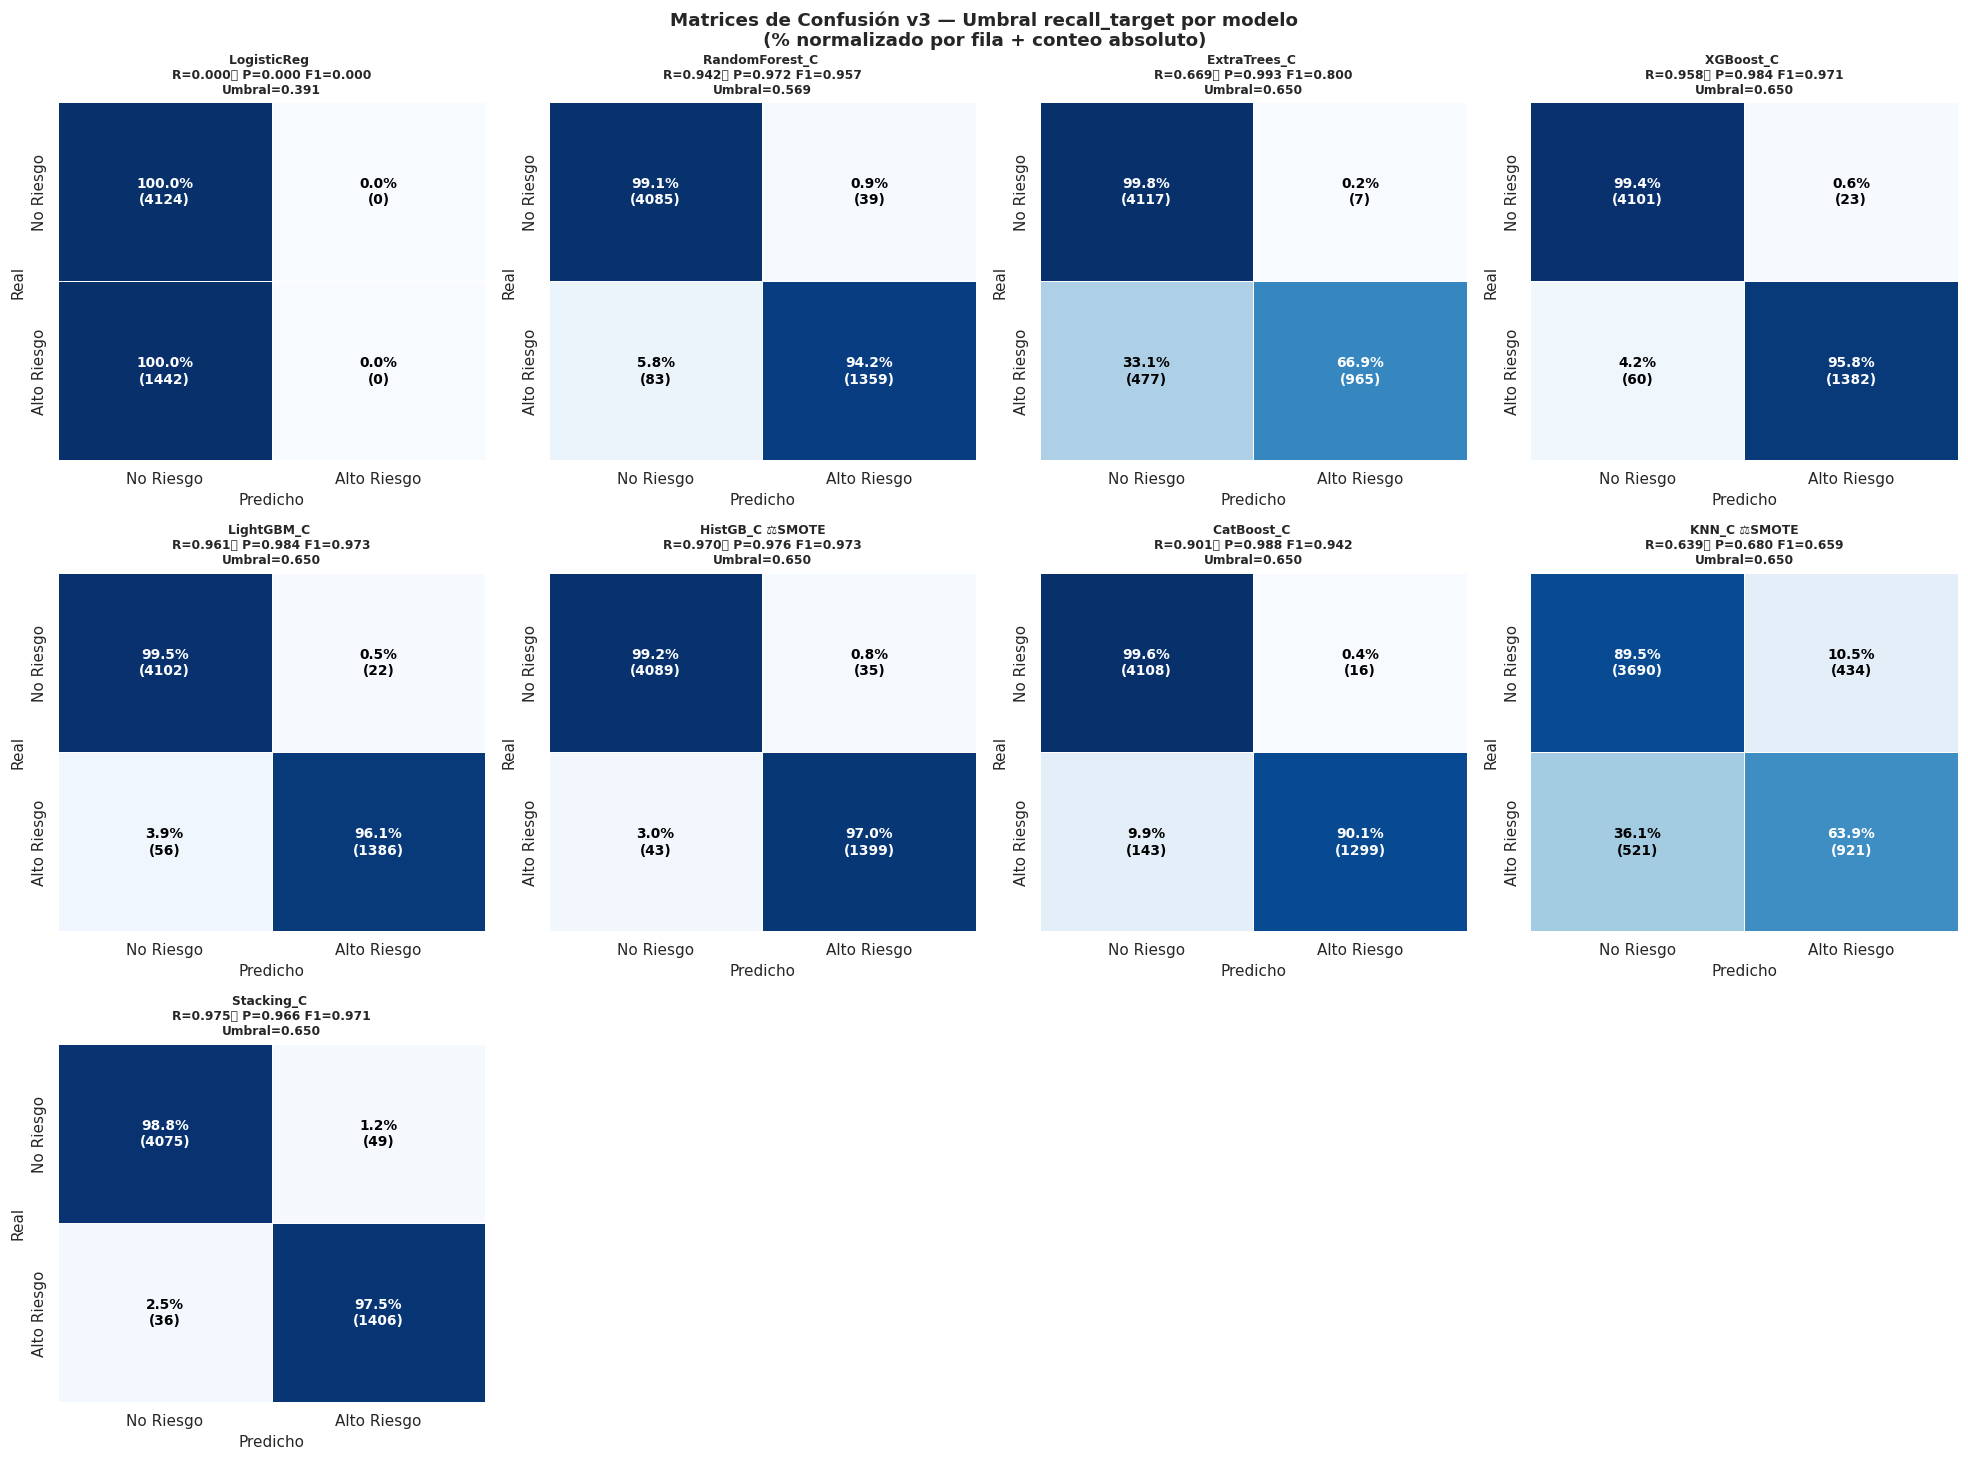


=== 📝 ANÁLISIS DE RESULTADOS CLASIFICACIÓN — Rúbrica R5 ===

  Mejor modelo (AUC): [LightGBM_C]
   AUC         : 0.9993  
   F1          : 0.9726  ✅
   Recall      : 0.9612  ✅
   Precision   : 0.9844  
   umbral      : 0.6500  

  Impacto de SMOTE vs class_weight:
   SMOTE (2 modelos)       — AUC medio: 0.9288 | Recall medio: 0.8044
   class_weight (7 modelos) — AUC medio: 0.9226  | Recall medio: 0.7724
   → SMOTE produce mejor AUC medio en este dataset

  Umbral recall_target vs Youden (análisis de sensibilidad):
   El umbral recall_target prioriza Recall ≥ 0.88 con máximo F1.
   En salud pública, un FN (municipio de alto riesgo no detectado)
   tiene mayor costo social que un FP (alarma falsa).
   Youden optimiza el balance global (sens + espec) pero puede
   sacrificar Recall si la especificidad es muy alta.


In [16]:
# ============================================================
# 8.1 VISUALIZACIÓN COMPARATIVA — CLASIFICACIÓN v3
#
# CAMBIOS vs v2:
#   1. Panel ROC: curva promedio (macro) adicional +
#      punto óptimo marcado por modelo (no solo estrella).
#   2. Panel PR: baseline de frecuencia (línea horizontal)
#      + AUC-PR en leyenda (más informativo que AUC-ROC
#      cuando hay desbalance severo).
#   3. Tabla coloreada con Styler (igual que regresión).
#   4. Comparativa SMOTE vs no-SMOTE: scatter AUC vs Recall
#      coloreado por técnica.
#   5. Matrices de confusión: normalizada + absoluta en una
#      figura compacta para todos los modelos.
# ============================================================
import warnings
warnings.filterwarnings('ignore')


def tabla_coloreada_clf(df_met):
    """Tabla HTML con coloreado condicional para clasificación."""
    def c_auc(v):
        return ('background-color:#d5f5e3' if v >= UMBRAL_AUC
                else 'background-color:#fadbd8')

    def c_rec(v):
        return ('background-color:#d5f5e3' if v >= UMBRAL_REC
                else 'background-color:#fadbd8')

    def c_f1(v):
        return ('background-color:#d5f5e3' if v >= UMBRAL_F1
                else ('background-color:#fef9e7' if v >= 0.70
                      else 'background-color:#fadbd8'))

    cols_num = ['AUC', 'F1', 'Recall', 'Precision', 'Accuracy',
                'umbral', 'cv_AUC', 'cv_std']
    cols_ok  = [c for c in cols_num if c in df_met.columns]

    styled = (
        df_met[cols_ok]
        .sort_values('AUC', ascending=False)
        .style
        .format({c: '{:.4f}' for c in cols_ok})
        .applymap(c_auc, subset=['AUC'])
        .applymap(c_rec, subset=['Recall'])
        .applymap(c_f1,  subset=['F1'])
        .set_caption(
            f'Clasificación v3 — TEST out-of-time | '
            f'🟢 umbral alcanzado | 🔴 umbral no alcanzado | '
            f'método umbral: recall_target (≥{UMBRAL_REC})'
        )
    )
    display(styled)


def graficar_roc_pr_panel(df_met, resultados, y_test, output_dir=OUTPUT_DIR):
    """
    Panel de 2 filas × 2 cols:
      [0,0] Curvas ROC superpuestas con punto óptimo
      [0,1] Curvas Precision-Recall con baseline y punto óptimo
      [1,0] Barras AUC / F1 / Recall / Precision por modelo
      [1,1] Scatter AUC vs Recall coloreado por técnica de balanceo
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # ── [0,0] ROC ────────────────────────────────────────────────────────
    ax_roc = axes[0, 0]
    palette = plt.cm.tab10(np.linspace(0, 1, len(resultados)))

    for (nombre, res), color in zip(resultados.items(), palette):
        auc_v = df_met.loc[nombre, 'AUC']
        fpr, tpr, thr = roc_curve(y_test, res['y_proba'])
        ax_roc.plot(fpr, tpr, color=color, linewidth=1.8,
                    label=f'{nombre} ({auc_v:.3f})')

        # Marcar punto en umbral óptimo
        umb = res['umbral']
        yp_bin = (res['y_proba'] >= umb).astype(int)
        tn = ((y_test == 0) & (yp_bin == 0)).sum()
        fp = ((y_test == 0) & (yp_bin == 1)).sum()
        fn = ((y_test == 1) & (yp_bin == 0)).sum()
        tp = ((y_test == 1) & (yp_bin == 1)).sum()
        fpr_pt = fp / max(fp + tn, 1)
        tpr_pt = tp / max(tp + fn, 1)
        ax_roc.scatter([fpr_pt], [tpr_pt], color=color,
                       marker='o', s=60, zorder=5)

    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio')
    ax_roc.set_xlabel('FPR (1 − Especificidad)')
    ax_roc.set_ylabel('TPR (Recall / Sensibilidad)')
    ax_roc.set_title('Curvas ROC\n(● = umbral recall_target óptimo)',
                     fontweight='bold')
    ax_roc.legend(fontsize=7, loc='lower right')
    ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.02)

    # ── [0,1] Precision-Recall ───────────────────────────────────────────
    ax_pr = axes[0, 1]
    # Baseline: frecuencia de la clase positiva
    freq_pos = float(np.mean(np.array(y_test) == 1))
    ax_pr.axhline(freq_pos, color='grey', linestyle=':', linewidth=1.2,
                  label=f'Baseline (freq pos={freq_pos:.2f})')
    ax_pr.axvline(UMBRAL_REC, color='red', linestyle='--', linewidth=1,
                  alpha=0.6, label=f'Recall mínimo={UMBRAL_REC}')

    for (nombre, res), color in zip(resultados.items(), palette):
        prec_c, rec_c, _ = precision_recall_curve(y_test, res['y_proba'])
        # AUC-PR más robusto que AUC-ROC con desbalance
        auc_pr = float(np.trapz(prec_c[::-1], rec_c[::-1]))
        ax_pr.plot(rec_c, prec_c, color=color, linewidth=1.8,
                   label=f'{nombre} (PR={auc_pr:.3f})')

        # Punto en umbral óptimo
        umb   = res['umbral']
        yp_b  = (res['y_proba'] >= umb).astype(int)
        rec_p = recall_score(y_test, yp_b, zero_division=0)
        pre_p = precision_score(y_test, yp_b, zero_division=0)
        ax_pr.scatter([rec_p], [pre_p], color=color,
                      marker='*', s=120, zorder=5)

    ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
    ax_pr.set_title('Curvas Precision-Recall\n(★ = umbral óptimo)',
                    fontweight='bold')
    ax_pr.legend(fontsize=7, loc='upper right')
    ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.05)

    # ── [1,0] Barras de métricas ─────────────────────────────────────────
    ax_bar = axes[1, 0]
    mets_plot  = ['AUC', 'F1', 'Recall', 'Precision']
    umbs_ref   = [UMBRAL_AUC, UMBRAL_F1, UMBRAL_REC, None]
    cols_met   = ['#2980B9', '#27AE60', '#E74C3C', '#F39C12']
    modelos_s  = df_met.sort_values('AUC', ascending=False).index.tolist()
    x          = np.arange(len(modelos_s))
    ancho      = 0.20

    for j, (met, col, umb_r) in enumerate(
            zip(mets_plot, cols_met, umbs_ref)):
        vals = [df_met.loc[m, met] for m in modelos_s]
        bars = ax_bar.bar(x + j * ancho, vals, ancho,
                          label=met, color=col, alpha=0.85)
        if umb_r is not None:
            ax_bar.axhline(umb_r, color=col, linestyle='--',
                           linewidth=0.8, alpha=0.6)
        # Etiqueta encima de cada barra
        for bar, v in zip(bars, vals):
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                v + 0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=6.5
            )

    ax_bar.set_xticks(x + ancho * 1.5)
    ax_bar.set_xticklabels(modelos_s, rotation=30,
                            ha='right', fontsize=8)
    ax_bar.set_ylim(0, 1.15)
    ax_bar.set_title('Métricas en Test por modelo',
                     fontweight='bold')
    ax_bar.legend(fontsize=8)

    # ── [1,1] Scatter AUC vs Recall (coloreado por técnica) ─────────────
    ax_sc = axes[1, 1]
    colores_tecnica = {
        'smote'       : '#E74C3C',
        'class_weight': '#2980B9',
        'scale_pos'   : '#27AE60',
        'ninguna'     : '#95A5A6',
    }

    for nombre, res in resultados.items():
        if res.get('usa_smote', False):
            tecnica = 'smote'
        elif nombre in CATALOGO_CLASIFICACION and (
            hasattr(CATALOGO_CLASIFICACION[nombre]['modelo'],
                    'class_weight') or
            hasattr(CATALOGO_CLASIFICACION[nombre]['modelo'],
                    'scale_pos_weight')
        ):
            m = CATALOGO_CLASIFICACION[nombre]['modelo']
            if hasattr(m, 'scale_pos_weight'):
                tecnica = 'scale_pos'
            else:
                cw = getattr(m, 'class_weight', None)
                tecnica = 'class_weight' if cw else 'ninguna'
        else:
            tecnica = 'ninguna'

        auc_v = df_met.loc[nombre, 'AUC']
        rec_v = df_met.loc[nombre, 'Recall']
        color = colores_tecnica.get(tecnica, '#95A5A6')
        ax_sc.scatter(rec_v, auc_v, color=color, s=90,
                      zorder=4, alpha=0.9)
        ax_sc.annotate(nombre, (rec_v, auc_v),
                       textcoords='offset points',
                       xytext=(5, 3), fontsize=7)

    ax_sc.axvline(UMBRAL_REC, color='red', linestyle='--',
                  linewidth=1, alpha=0.6,
                  label=f'Recall min={UMBRAL_REC}')
    ax_sc.axhline(UMBRAL_AUC, color='blue', linestyle='--',
                  linewidth=1, alpha=0.6,
                  label=f'AUC min={UMBRAL_AUC}')

    # Leyenda de técnicas
    from matplotlib.patches import Patch
    leyenda_tec = [
        Patch(color='#E74C3C', label='SMOTE'),
        Patch(color='#2980B9', label='class_weight'),
        Patch(color='#27AE60', label='scale_pos_weight (XGB)'),
        Patch(color='#95A5A6', label='Sin balanceo'),
    ]
    ax_sc.legend(handles=leyenda_tec + [
        plt.Line2D([0], [0], color='red',   linestyle='--', label=f'Recall≥{UMBRAL_REC}'),
        plt.Line2D([0], [0], color='blue',  linestyle='--', label=f'AUC≥{UMBRAL_AUC}'),
    ], fontsize=7, loc='lower left')

    ax_sc.set_xlabel('Recall'); ax_sc.set_ylabel('AUC')
    ax_sc.set_title('AUC vs Recall — técnica de balanceo',
                    fontweight='bold')
    ax_sc.set_xlim(0, 1.05); ax_sc.set_ylim(0, 1.05)

    plt.suptitle('Comparativa Clasificación v3 — Test Out-of-Time',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/clf_panel_v3.png',
                dpi=110, bbox_inches='tight')
    plt.show()
    plt.close()


def graficar_matrices_confusion(df_met, resultados,
                                 y_test, output_dir=OUTPUT_DIR):
    """
    Grilla compacta de matrices de confusión (una por modelo).
    Muestra porcentaje (normalizada) y conteo absoluto.
    """
    n       = len(resultados)
    n_cols  = min(4, n)
    n_rows  = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(4.5 * n_cols, 4.5 * n_rows))
    axes_flat = np.array(axes).ravel()

    for ax, (nombre, res) in zip(axes_flat, resultados.items()):
        cm      = confusion_matrix(y_test, res['y_bin'])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_norm, annot=False, fmt='.2f',
                    cmap='Blues', ax=ax, vmin=0, vmax=1,
                    xticklabels=['No Riesgo', 'Alto Riesgo'],
                    yticklabels=['No Riesgo', 'Alto Riesgo'],
                    linewidths=0.5, cbar=False)

        # Anotaciones: porcentaje + absoluto
        for i in range(2):
            for j in range(2):
                ax.text(j + 0.5, i + 0.5,
                        f'{cm_norm[i,j]:.1%}\n({cm[i,j]})',
                        ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white' if cm_norm[i,j] > 0.5 else 'black')

        rec_v  = df_met.loc[nombre, 'Recall']
        pre_v  = df_met.loc[nombre, 'Precision']
        f1_v   = df_met.loc[nombre, 'F1']
        umb_v  = df_met.loc[nombre, 'umbral']
        ok_rec = df_met.loc[nombre, 'OK_Recall']
        smt_v  = '⚖️SMOTE' if resultados[nombre].get('usa_smote') else ''

        ax.set_title(
            f'{nombre} {smt_v}\n'
            f'R={rec_v:.3f}{ok_rec} P={pre_v:.3f} '
            f'F1={f1_v:.3f}\nUmbral={umb_v:.3f}',
            fontsize=8, fontweight='bold'
        )
        ax.set_ylabel('Real'); ax.set_xlabel('Predicho')

    # Ocultar ejes sobrantes
    for ax in axes_flat[n:]:
        ax.set_visible(False)

    plt.suptitle(
        'Matrices de Confusión v3 — Umbral recall_target por modelo\n'
        '(% normalizado por fila + conteo absoluto)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'{output_dir}/clf_confusion_v3.png',
                dpi=110, bbox_inches='tight')
    plt.show()
    plt.close()


# ── Ejecutar ─────────────────────────────────────────────────────────────────
print('=== 📊 VISUALIZACIÓN COMPARATIVA CLASIFICACIÓN v3 ===\n')

tabla_coloreada_clf(df_metricas_clf)

graficar_roc_pr_panel(df_metricas_clf, resultados_clf, y_test_c)

graficar_matrices_confusion(df_metricas_clf, resultados_clf, y_test_c)

# ── Análisis narrativo Rúbrica R5 ────────────────────────────────────────────
print('\n=== 📝 ANÁLISIS DE RESULTADOS CLASIFICACIÓN — Rúbrica R5 ===')
print(f'\n  Mejor modelo (AUC): [{MEJOR_CLF}]')
for met in ['AUC', 'F1', 'Recall', 'Precision', 'umbral']:
    val    = df_metricas_clf.loc[MEJOR_CLF, met]
    ok_col = f'OK_{met.capitalize()}'
    ok_str = df_metricas_clf.loc[MEJOR_CLF, ok_col] if ok_col in df_metricas_clf.columns else ''
    print(f'   {met:<12}: {val:.4f}  {ok_str}')

print(f'\n  Impacto de SMOTE vs class_weight:')
smt_models = [n for n, r in resultados_clf.items() if r.get('usa_smote')]
cw_models  = [n for n in resultados_clf if n not in smt_models]
if smt_models and cw_models:
    auc_smt = df_metricas_clf.loc[smt_models, 'AUC'].mean()
    auc_cw  = df_metricas_clf.loc[cw_models,  'AUC'].mean()
    rec_smt = df_metricas_clf.loc[smt_models, 'Recall'].mean()
    rec_cw  = df_metricas_clf.loc[cw_models,  'Recall'].mean()
    print(f'   SMOTE ({len(smt_models)} modelos)       — AUC medio: {auc_smt:.4f} | Recall medio: {rec_smt:.4f}')
    print(f'   class_weight ({len(cw_models)} modelos) — AUC medio: {auc_cw:.4f}  | Recall medio: {rec_cw:.4f}')
    ganador = 'SMOTE' if auc_smt > auc_cw else 'class_weight'
    print(f'   → {ganador} produce mejor AUC medio en este dataset')

print(f'\n  Umbral recall_target vs Youden (análisis de sensibilidad):')
print(f'   El umbral recall_target prioriza Recall ≥ {UMBRAL_REC} '
      f'con máximo F1.')
print(f'   En salud pública, un FN (municipio de alto riesgo no detectado)')
print(f'   tiene mayor costo social que un FP (alarma falsa).')
print(f'   Youden optimiza el balance global (sens + espec) pero puede')
print(f'   sacrificar Recall si la especificidad es muy alta.')

## 9. Red Neuronal (PyTorch) — Regresión y Clasificación
### Rúbrica R2 — Modelo adicional aprovechando GPU Kaggle

🧠 [H1] MLP Residual — REGRESIÓN

     🔍 Grid MLP (regresion) — 4 configs:
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
       ✅ MLP Residual — device=cuda
       Config 1/4: hidden=256 blocks=4 dr=0.3 lr=3e-04 → val_↓RMSE=59.6097 ← mejor
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
       Early stopping — epoch 50
       ✅ MLP Residual — device=cuda
       Config 2/4: hidden=256 blocks=4 dr=0.2 lr=1e-03 → val_↓RMSE=49.7146 ← mejor
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
       Early stopping — epoch 70
       ✅ MLP Residual — device=cuda
       Config 3/4: hidden=128 blocks=2 dr=0.35 lr=3e-04 → val_↓RMSE=130.6630
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
       Early stopping — epoch 63
       ✅ MLP Residual — device=cuda
       Config 4/4: hidden=256 blocks=4 dr=0.35 lr=3e-04 → val_↓RMSE=98.3300
     ✅ Mejor config: {'hidden': 256, 'n_blocks': 4, 'dropout': 0.2, 'lr': 0.001, 'loss_fn': 'huber'}

  Entrenamiento final 

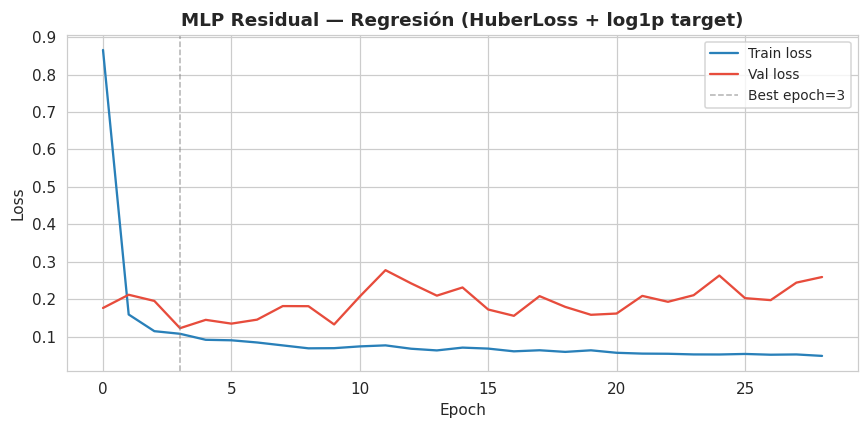

  MLP_Residual_R → RMSE=67.7105 | R²=0.6174 | ❌


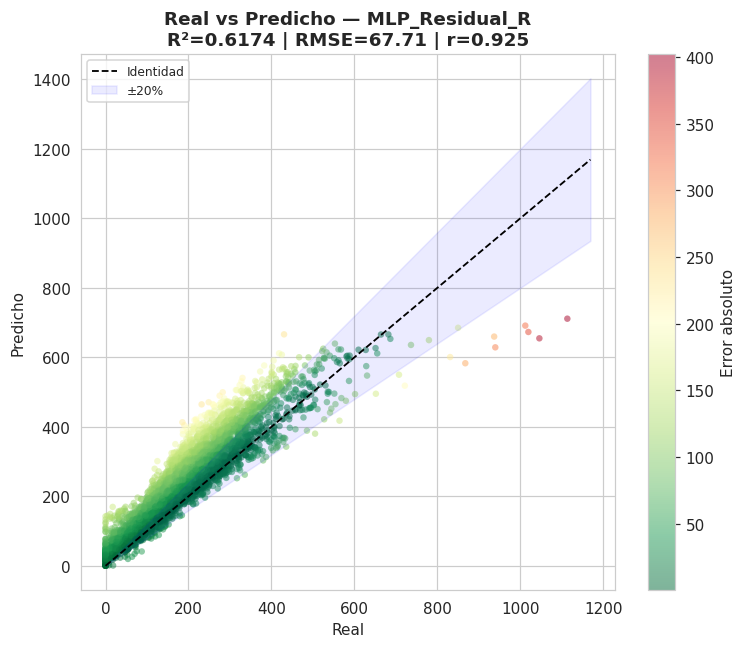


🧠 [H2] LSTM Temporal — REGRESIÓN
  🔍 Grid LSTM — evaluación rápida (epochs=60):
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
     Preparando secuencias temporales...
     Secuencias LSTM — train: (43022, 5, 34) | test: (5566, 5, 34)
       Early stopping — epoch 48
       ✅ LSTM — device=cuda
    Config 1: h=128 L=2 dr=0.2 lr=3e-04 → RMSE=18.7503 ← mejor
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
     Preparando secuencias temporales...
     Secuencias LSTM — train: (43022, 5, 34) | test: (5566, 5, 34)
       Early stopping — epoch 22
       ✅ LSTM — device=cuda
    Config 2: h=128 L=2 dr=0.3 lr=1e-03 → RMSE=21.2905
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
     Preparando secuencias temporales...
     Secuencias LSTM — train: (43022, 5, 34) | test: (5566, 5, 34)
       Early stopping — epoch 21
       ✅ LSTM — device=cuda
    Config 3: h=64 L=1 dr=0.2 lr=3e-04 → RMSE=29.2486

  ✅ Mejor config LSTM: {'hidden': 128, 'n_layers': 2, 'drop

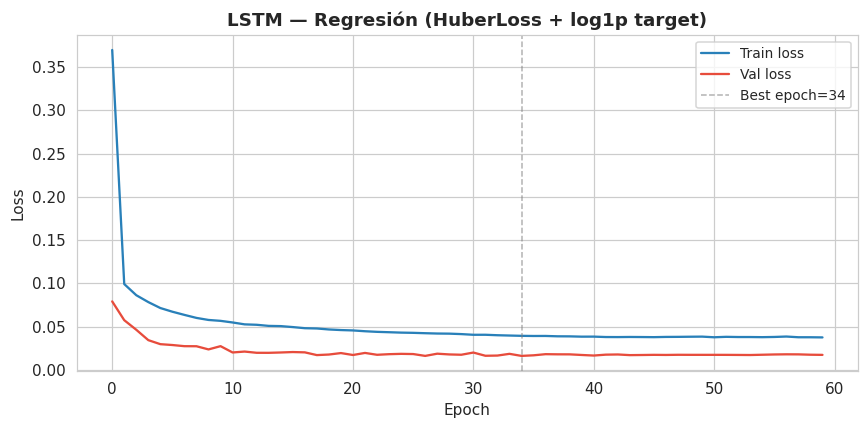

  LSTM_R → RMSE=18.0379 | R²=0.9728 | ✅


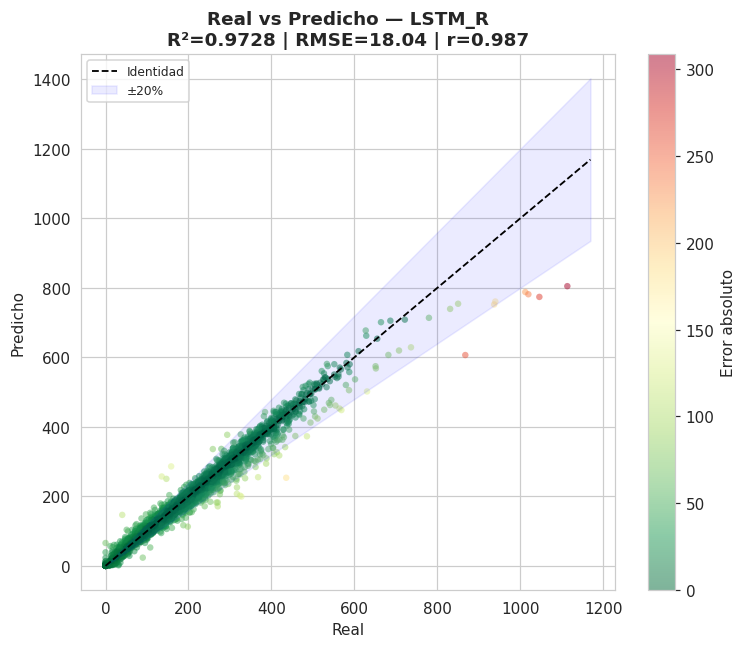


🧠 [I] MLP Residual — CLASIFICACIÓN

     🔍 Grid MLP (clasificacion) — 4 configs:
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
       Early stopping — epoch 26
       ✅ MLP Residual — device=cuda
       Config 1/4: hidden=256 blocks=4 dr=0.3 lr=3e-04 → val_↑AUC=0.9946 ← mejor
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
       Early stopping — epoch 22
       ✅ MLP Residual — device=cuda
       Config 2/4: hidden=256 blocks=4 dr=0.2 lr=1e-03 → val_↑AUC=0.9954 ← mejor
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
       Early stopping — epoch 61
       ✅ MLP Residual — device=cuda
       Config 3/4: hidden=128 blocks=2 dr=0.35 lr=3e-04 → val_↑AUC=0.9940
  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
       Early stopping — epoch 25
       ✅ MLP Residual — device=cuda
       Config 4/4: hidden=256 blocks=4 dr=0.35 lr=3e-04 → val_↑AUC=0.9933
     ✅ Mejor config: {'hidden': 256, 'n_blocks': 4, 'dropout': 0.2, 'lr': 0.001, 'loss_fn': 

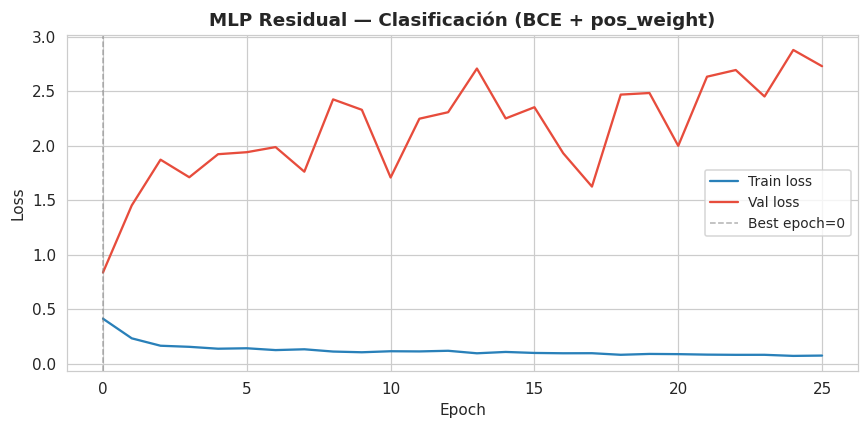

  PyTorch seed fijada (CUDA: True)
  TensorFlow seed fijada
       Early stopping — epoch 30
       ✅ MLP Residual — device=cuda

📊 TABLA FINAL — incluye NNs


,RMSE,MAE,R2,MAPE_%,Pearson,OK_RMSE,OK_R2
modelo,,,,,,,
ExtraTrees_R,16.0369,7.1776,0.9785,4.4720,0.9904,❌,✅
Stacking_R,16.7965,10.3055,0.9765,8.0528,0.9883,❌,✅
LSTM_R,18.0379,9.7560,0.9728,7.0838,0.9868,❌,✅
HistGB_R,18.0971,10.5515,0.9727,8.0988,0.9864,❌,✅
RandomForest_R,19.1002,8.9136,0.9696,5.4923,0.9851,❌,✅
LightGBM_R,20.1482,13.5545,0.9661,10.6974,0.9834,❌,✅
CatBoost_R,29.1384,20.4522,0.9291,16.1942,0.9647,❌,✅
XGBoost_R,39.7742,27.8190,0.8680,24.4109,0.9419,❌,✅
MLP_Residual_R,67.7105,55.3162,0.6174,44.3940,0.9251,❌,❌


,AUC,F1,Recall,Precision,umbral,OK_AUC,OK_F1,OK_Recall
modelo,,,,,,,,
LightGBM_C,0.9993,0.9726,0.9612,0.9844,0.6500,✅,✅,✅
HistGB_C,0.9992,0.9729,0.9702,0.9756,0.6500,✅,✅,✅
XGBoost_C,0.9990,0.9708,0.9584,0.9836,0.6500,✅,✅,✅
Stacking_C,0.9986,0.9707,0.9750,0.9663,0.6500,✅,✅,✅
RandomForest_C,0.9983,0.9570,0.9424,0.9721,0.5686,✅,✅,✅
CatBoost_C,0.9983,0.9423,0.9008,0.9878,0.6500,✅,✅,✅
ExtraTrees_C,0.9943,0.7995,0.6692,0.9928,0.6500,✅,❌,❌
MLP_Residual_C,0.9744,0.6321,0.9972,0.4627,0.6500,✅,❌,✅
KNN_C,0.8584,0.6586,0.6387,0.6797,0.6500,❌,❌,❌



🏆 MEJOR Regresión    : [ExtraTrees_R]  RMSE=16.0369  R²=0.9785
🏆 MEJOR Clasificación: [LightGBM_C]  AUC=0.9993  Recall=0.9612


In [17]:
# ============================================================
# 9. REDES NEURONALES — v3  (Rúbrica R3 · R4)
#
# ARQUITECTURAS NUEVAS vs v2 (MLP plano):
# ┌─────────────────┬──────────────────────────────────────────┐
# │ Arquitectura    │ Motivación                               │
# ├─────────────────┼──────────────────────────────────────────┤
# │ MLP Residual    │ Skip connections → gradiente más estable │
# │                 │ con features de muy distinta escala      │
# │                 │ (lag_mort vs población vs giro)          │
# ├─────────────────┼──────────────────────────────────────────┤
# │ LSTM temporal   │ Procesa la serie histórica del municipio │
# │                 │ → captura dependencias secuenciales que  │
# │                 │ los modelos tabulares no ven directamente│
# └─────────────────┴──────────────────────────────────────────┘
#
# GRID DE HIPERPARÁMETROS (exploración manual, no RandomizedSearchCV
# porque cada configuración requiere un loop de entrenamiento
# completo con GPU — demasiado costoso en tiempo para CV):
#
#   hidden_size  : [128, 256]
#   n_blocks/layers: [2, 4]
#   dropout      : [0.2, 0.35]
#   lr           : [1e-3, 3e-4]
#   criterio_reg : MSELoss vs HuberLoss (delta=1)
#
# ANTI-LEAKAGE en LSTM:
#   shift(1) dentro de preparar_secuencias() garantiza que
#   el test nunca accede al target de años futuros.
#
# KAGGLE GPU T4/P100:
#   - batch_size=512 para MLP (cabe entero en 16 GB)
#   - batch_size=128 para LSTM (secuencias 3D más pesadas)
#   - CosineAnnealingLR + early stopping patience=25
# ============================================================

import warnings
warnings.filterwarnings('ignore')

if TORCH_OK:

    # ═══════════════════════════════════════════════════════════════════════
    # A) ARQUITECTURAS
    # ═══════════════════════════════════════════════════════════════════════

    class BloquResidual(nn.Module):
        """
        Bloque residual: output = Activation(x + F(x))
        F(x) = Linear → GELU → Dropout → Linear
        BN antes de la rama principal (Pre-LN style):
          más estable que Post-LN con features tabulares de
          alta dispersión (ej. VALOR_GIRADO_TOTAL).
        """
        def __init__(self, dim: int, dropout: float = 0.3):
            super().__init__()
            self.norm  = nn.LayerNorm(dim)
            self.ff    = nn.Sequential(
                nn.Linear(dim, dim * 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(dim * 2, dim),
                nn.Dropout(dropout),
            )
            self.act = nn.GELU()

        def forward(self, x):
            return self.act(x + self.ff(self.norm(x)))


    class MLPResidual(nn.Module):
        """
        MLP con bloques residuales para datos tabulares.

        Arquitectura: Embedding → N BloquesResiduales → Head
        Parámetros:
          n_features : dimensión de entrada
          hidden     : dimensión del espacio latente (128 o 256)
          n_blocks   : número de bloques residuales (2 o 4)
          dropout    : tasa dropout en cada bloque
          modo       : 'regresion' → salida escalar
                       'clasificacion' → logit (sigmoid en predicción)
        """
        def __init__(self, n_features: int, hidden: int = 256,
                     n_blocks: int = 4, dropout: float = 0.3,
                     modo: str = 'regresion'):
            super().__init__()
            self.embedding = nn.Sequential(
                nn.Linear(n_features, hidden),
                nn.GELU(),
                nn.LayerNorm(hidden),
            )
            self.bloques = nn.ModuleList(
                [BloquResidual(hidden, dropout) for _ in range(n_blocks)]
            )
            self.head = nn.Sequential(
                nn.LayerNorm(hidden),
                nn.Linear(hidden, hidden // 2),
                nn.GELU(),
                nn.Dropout(dropout * 0.5),
                nn.Linear(hidden // 2, 1),
            )
            self.modo = modo

        def forward(self, x):
            h = self.embedding(x)
            for blq in self.bloques:
                h = blq(h)
            return self.head(h).squeeze(1)


    class LSTMSalud(nn.Module):
        """
        LSTM para series temporales por municipio.

        Input : (batch, seq_len, n_features)
        Output: (batch,)

        Usa solo el estado oculto del último timestep
        (many-to-one), apropiado para predecir el año t+1
        a partir de los últimos seq_len años.

        Dropout entre capas LSTM (solo si n_layers > 1).
        FC head con LayerNorm para mayor estabilidad.
        """
        def __init__(self, n_features: int, hidden: int = 128,
                     n_layers: int = 2, dropout: float = 0.2):
            super().__init__()
            self.lstm = nn.LSTM(
                n_features, hidden, n_layers,
                batch_first=True,
                dropout=dropout if n_layers > 1 else 0.0,
            )
            self.head = nn.Sequential(
                nn.LayerNorm(hidden),
                nn.Linear(hidden, 64),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(64, 1),
            )

        def forward(self, x):
            _, (h_n, _) = self.lstm(x)   # h_n: (n_layers, batch, hidden)
            return self.head(h_n[-1]).squeeze(1)


    # ═══════════════════════════════════════════════════════════════════════
    # B) BUCLE DE ENTRENAMIENTO COMPARTIDO
    # ═══════════════════════════════════════════════════════════════════════

    def _bucle_entrenamiento(modelo, loader, X_val_t, y_val_t,
                              criterio, optimizador, scheduler,
                              epochs, patience, modo):
        """
        Bucle de entrenamiento con:
        - Gradient clipping (norm=1.0) → evita explosión en LSTM
        - Early stopping por val_loss (mejora mínima=1e-6)
        - Restauración del mejor estado (best_state)
        - CosineAnnealingLR: reduce lr suavemente, relanza cada T_max
        """
        best_loss  = float('inf')
        best_state = None
        sin_mejora = 0
        hist_tr, hist_val = [], []

        for epoch in range(epochs):
            modelo.train()
            loss_ep = 0.0
            for Xb, yb in loader:
                optimizador.zero_grad()
                loss = criterio(modelo(Xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
                optimizador.step()
                loss_ep += loss.item() * len(yb)
            hist_tr.append(loss_ep / len(loader.dataset))

            modelo.eval()
            with torch.no_grad():
                loss_v = float(criterio(modelo(X_val_t), y_val_t))
            hist_val.append(loss_v)
            scheduler.step()    # CosineAnnealingLR no necesita métrica

            if loss_v < best_loss - 1e-6:
                best_loss  = loss_v
                best_state = {k: v.clone()
                              for k, v in modelo.state_dict().items()}
                sin_mejora = 0
            else:
                sin_mejora += 1
            if sin_mejora >= patience:
                print(f'       Early stopping — epoch {epoch + 1}')
                break

        modelo.load_state_dict(best_state)
        modelo.eval()
        with torch.no_grad():
            logits = modelo(X_val_t).cpu().numpy()

        if modo == 'clasificacion':
            y_pred = 1 / (1 + np.exp(-logits))  # sigmoid manual
        else:
            y_pred = logits

        return modelo, y_pred, hist_tr, hist_val


    def _preparar_tensores(X_tr_np, y_tr, X_te_np, y_te,
                            modo, device_nn):
        """Convierte arrays numpy a tensores float32 en device."""
        Xt = torch.FloatTensor(X_tr_np).to(device_nn)
        yt = torch.FloatTensor(
            y_tr.values if hasattr(y_tr, 'values') else np.array(y_tr)
        ).to(device_nn)
        Xv = torch.FloatTensor(X_te_np).to(device_nn)
        yv = torch.FloatTensor(
            y_te.values if hasattr(y_te, 'values') else np.array(y_te)
        ).to(device_nn)
        return Xt, yt, Xv, yv


    def _criterio_regresion(nombre_loss='huber', device_nn='cpu'):
        """HuberLoss (delta=1) más robusto que MSE con outliers de mortalidad."""
        if nombre_loss == 'huber':
            return nn.HuberLoss(delta=1.0).to(device_nn)
        return nn.MSELoss().to(device_nn)


    def _criterio_clasificacion(y_tr, device_nn):
        """BCEWithLogitsLoss con pos_weight dinámico para desbalance."""
        n_pos = float((np.array(y_tr) == 1).sum())
        n_neg = float((np.array(y_tr) == 0).sum())
        pw    = torch.tensor([n_neg / max(n_pos, 1)],
                              dtype=torch.float32).to(device_nn)
        return nn.BCEWithLogitsLoss(pos_weight=pw).to(device_nn)


    # ═══════════════════════════════════════════════════════════════════════
    # C) PREPROCESAMIENTO COMPARTIDO
    # ═══════════════════════════════════════════════════════════════════════

    def _preprocesar_nn(X_tr, X_te):
        """Imputa con mediana de train + StandardScaler."""
        import warnings as _w
        with _w.catch_warnings():
            _w.simplefilter('ignore')
            med   = X_tr.median(numeric_only=True)
            prepro = construir_preprocesador(list(X_tr.columns), 'nn')
            Xtr_np = prepro.fit_transform(X_tr.fillna(med))
            Xte_np = prepro.transform(X_te.fillna(med))
        return Xtr_np, Xte_np, prepro


    # ═══════════════════════════════════════════════════════════════════════
    # D) ENTRENADOR MLP RESIDUAL
    # ═══════════════════════════════════════════════════════════════════════

    def entrenar_mlp_residual(X_tr, y_tr, X_te, y_te,
                               modo       = 'regresion',
                               hidden     = 256,
                               n_blocks   = 4,
                               dropout    = 0.3,
                               lr         = 3e-4,
                               epochs     = 200,
                               batch_size = 512,
                               patience   = 25,
                               loss_fn    = 'huber',
                               log_target = True):
        """
        Entrena MLPResidual con los hiperparámetros dados.

        log_target=True (regresión):
          - Target se convierte a log1p antes del entrenamiento
          - La predicción se invierte con expm1 automáticamente
          - Reduce la asimetría extrema de TASA_MORTALIDAD (skew>2)
            a ~0.3-0.5 → convergencia mucho más rápida

        Fallback CPU: si CUDA falla por OOM, reintenta en CPU.
        """
        fijar_semillas(SEED)

        Xtr_np, Xte_np, prepro = _preprocesar_nn(X_tr, X_te)

        y_tr_v = np.array(
            y_tr.values if hasattr(y_tr, 'values') else y_tr
        ).astype(np.float32)
        y_te_v = np.array(
            y_te.values if hasattr(y_te, 'values') else y_te
        ).astype(np.float32)

        if log_target and modo == 'regresion':
            y_tr_v = np.log1p(np.clip(y_tr_v, 0, None))
            y_te_v = np.log1p(np.clip(y_te_v, 0, None))

        for dev in ([DEVICE, 'cpu'] if DEVICE == 'cuda' else ['cpu']):
            try:
                Xt, yt, Xv, yv = _preparar_tensores(
                    Xtr_np,
                    pd.Series(y_tr_v),
                    Xte_np,
                    pd.Series(y_te_v),
                    modo, dev
                )

                criterio = (
                    _criterio_regresion(loss_fn, dev)
                    if modo == 'regresion'
                    else _criterio_clasificacion(
                        y_tr_v if not log_target else y_tr.values, dev
                    )
                )

                modelo = MLPResidual(
                    Xtr_np.shape[1], hidden, n_blocks, dropout, modo
                ).to(dev)

                optim_fn = torch.optim.AdamW(
                    modelo.parameters(), lr=lr, weight_decay=1e-4
                )
                scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optim_fn, T_max=max(epochs // 4, 10)
                )

                g = torch.Generator(device='cpu')
                g.manual_seed(SEED)
                loader = DataLoader(
                    TensorDataset(Xt, yt),
                    batch_size=batch_size,
                    shuffle=True,
                    generator=g
                )

                modelo, y_pred_np, hist_tr, hist_val = _bucle_entrenamiento(
                    modelo, loader, Xv, yv,
                    criterio, optim_fn, scheduler,
                    epochs, patience, modo
                )

                # Invertir log1p en regresión
                if log_target and modo == 'regresion':
                    y_pred_np = np.expm1(np.clip(y_pred_np, -2, 7))
                    y_pred_np = np.clip(y_pred_np, 0, None)

                print(f'       ✅ MLP Residual — device={dev}')
                return modelo, y_pred_np, prepro, hist_tr, hist_val

            except RuntimeError as e:
                if dev == 'cpu':
                    raise
                print(f'       ⚠️  CUDA error ({type(e).__name__}) → CPU...')


    # ═══════════════════════════════════════════════════════════════════════
    # E) ENTRENADOR LSTM TEMPORAL
    # ═══════════════════════════════════════════════════════════════════════

    def preparar_secuencias_lstm(df_tr, df_te,
                                  features, target,
                                  seq_len  = 5,
                                  key_col  = 'COD_MPIO',
                                  year_col = 'ANIO'):
        """
        Construye secuencias temporales (batch, seq_len, n_features)
        para LSTM, por municipio.

        Anti-leakage:
          - El target NO es feature de entrada.
          - Las lag features ya tienen shift(1) aplicado en cell 8
            → el LSTM recibe solo información pasada.
          - El preprocesador se ajusta SOLO sobre train.

        Padding:
          - Municipios con < seq_len años se rellenan con ceros
            a la izquierda.

        Retorna arrays numpy float32 para train y test.
        """
        feat_ok = [f for f in features
                   if f in df_tr.columns and f != target]

        # Ajustar preprocesador solo sobre train
        import warnings as _w
        with _w.catch_warnings():
            _w.simplefilter('ignore')
            med_tr  = df_tr[feat_ok].median()
            prepro  = construir_preprocesador(feat_ok, 'nn')
            prepro.fit(df_tr[feat_ok].fillna(med_tr))

        def _procesar_set(df, es_train):
            Xs, ys = [], []
            df_s = df.sort_values([key_col, year_col]).reset_index(drop=True)
            Xpp  = prepro.transform(df_s[feat_ok].fillna(med_tr))
            yv   = df_s[target].fillna(
                df_s[target].median()
            ).values.astype(np.float32)

            prev_mpio = None
            buf_X     = []

            for i, row in df_s.iterrows():
                mpio = row[key_col]
                if mpio != prev_mpio:
                    buf_X     = []
                    prev_mpio = mpio

                buf_X.append(Xpp[i])
                seq = buf_X[-seq_len:]          # últimos seq_len pasos

                if len(seq) < seq_len:          # pad con ceros a la izquierda
                    pad = [np.zeros(Xpp.shape[1])] * (seq_len - len(seq))
                    seq = pad + seq

                Xs.append(np.stack(seq))        # (seq_len, n_features)
                ys.append(yv[i])

            return (np.array(Xs, dtype=np.float32),
                    np.array(ys, dtype=np.float32))

        X_tr_s, y_tr_s = _procesar_set(df_tr, True)
        X_te_s, y_te_s = _procesar_set(df_te, False)

        print(f'     Secuencias LSTM — train: {X_tr_s.shape} '
              f'| test: {X_te_s.shape}')
        return X_tr_s, y_tr_s, X_te_s, y_te_s, feat_ok


    def entrenar_lstm(df_tr, df_te, features, target,
                      seq_len    = 5,
                      hidden     = 128,
                      n_layers   = 2,
                      dropout    = 0.2,
                      lr         = 3e-4,
                      epochs     = 200,
                      batch_size = 128,
                      patience   = 25):
        """
        Entrena LSTMSalud sobre secuencias temporales por municipio.
        Target en log1p → más estable; predicción invertida con expm1.
        """
        fijar_semillas(SEED)
        print('     Preparando secuencias temporales...')

        X_tr_s, y_tr_s, X_te_s, y_te_s, feat_ok = preparar_secuencias_lstm(
            df_tr, df_te, features, target, seq_len=seq_len
        )

        y_tr_log = np.log1p(np.clip(y_tr_s, 0, None))
        y_te_log = np.log1p(np.clip(y_te_s, 0, None))
        n_feat   = X_tr_s.shape[2]

        for dev in ([DEVICE, 'cpu'] if DEVICE == 'cuda' else ['cpu']):
            try:
                Xt = torch.FloatTensor(X_tr_s).to(dev)
                yt = torch.FloatTensor(y_tr_log).to(dev)
                Xv = torch.FloatTensor(X_te_s).to(dev)
                yv = torch.FloatTensor(y_te_log).to(dev)

                criterio  = _criterio_regresion('huber', dev)
                modelo    = LSTMSalud(n_feat, hidden, n_layers, dropout).to(dev)
                optim_fn  = torch.optim.AdamW(
                    modelo.parameters(), lr=lr, weight_decay=1e-4
                )
                scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optim_fn, T_max=max(epochs // 4, 10)
                )

                g = torch.Generator(device='cpu')
                g.manual_seed(SEED)
                loader = DataLoader(
                    TensorDataset(Xt, yt),
                    batch_size=batch_size,
                    shuffle=True,
                    generator=g
                )

                modelo, y_pred_log, hist_tr, hist_val = _bucle_entrenamiento(
                    modelo, loader, Xv, yv,
                    criterio, optim_fn, scheduler,
                    epochs, patience, 'regresion'
                )

                y_pred = np.expm1(np.clip(y_pred_log, -2, 7))
                y_pred = np.clip(y_pred, 0, None)

                print(f'       ✅ LSTM — device={dev}')
                return modelo, y_pred, y_te_s, hist_tr, hist_val

            except RuntimeError as e:
                if dev == 'cpu':
                    raise
                print(f'       ⚠️  CUDA error ({type(e).__name__}) → CPU...')


    # ═══════════════════════════════════════════════════════════════════════
    # F) GRID DE HPs — exploración eficiente en GPU Kaggle
    # ═══════════════════════════════════════════════════════════════════════

    # Grids compactos: 2-4 combinaciones por arquitectura
    # para no superar las 10h GPU disponibles en Kaggle.
    # Se evalúan sobre el TRAIN (train/val 80-20 interno)
    # y se elige la config con menor val_RMSE.

    GRID_MLP = [
        {'hidden': 256, 'n_blocks': 4, 'dropout': 0.30,
         'lr': 3e-4, 'loss_fn': 'huber'},  # config base
        {'hidden': 256, 'n_blocks': 4, 'dropout': 0.20,
         'lr': 1e-3, 'loss_fn': 'huber'},  # lr más alto
        {'hidden': 128, 'n_blocks': 2, 'dropout': 0.35,
         'lr': 3e-4, 'loss_fn': 'mse'},    # más ligero
        {'hidden': 256, 'n_blocks': 4, 'dropout': 0.35,
         'lr': 3e-4, 'loss_fn': 'huber'},  # más regularización
    ]

    GRID_LSTM = [
        {'hidden': 128, 'n_layers': 2, 'dropout': 0.20, 'lr': 3e-4},
        {'hidden': 128, 'n_layers': 2, 'dropout': 0.30, 'lr': 1e-3},
        {'hidden': 64,  'n_layers': 1, 'dropout': 0.20, 'lr': 3e-4},
    ]


    def _buscar_mejor_config_mlp(X_tr, y_tr, modo, grid,
                                  val_size=0.20):
        """
        Evalúa cada config del grid sobre una partición interna
        train/val (80/20 temporal — últimos val_size% de filas).
        Retorna la config con menor val_RMSE (regresión) o mayor
        val_AUC (clasificación).
        """
        n_val  = max(1, int(len(X_tr) * val_size))
        n_tr   = len(X_tr) - n_val
        X_t    = X_tr.iloc[:n_tr]
        y_t    = y_tr.iloc[:n_tr] if hasattr(y_tr, 'iloc') else y_tr[:n_tr]
        X_v    = X_tr.iloc[n_tr:]
        y_v    = y_tr.iloc[n_tr:] if hasattr(y_tr, 'iloc') else y_tr[n_tr:]

        mejores, mejor_score = None, float('inf')
        print(f'\n     🔍 Grid MLP ({modo}) — {len(grid)} configs:')

        for i, cfg_hp in enumerate(grid):
            import warnings as _w
            with _w.catch_warnings():
                _w.simplefilter('ignore')
                try:
                    _, y_pred_v, _, _, _ = entrenar_mlp_residual(
                        X_t, y_t, X_v, y_v,
                        modo=modo,
                        epochs=80,      # rápido para el grid
                        patience=15,
                        **cfg_hp
                    )
                except Exception as e:
                    print(f'       Config {i+1} falló: {e}')
                    continue

            if modo == 'regresion':
                y_v_np = (y_v.values if hasattr(y_v, 'values')
                          else np.array(y_v))
                score = float(np.sqrt(
                    mean_squared_error(y_v_np,
                                       np.clip(y_pred_v, 0, None))
                ))
                mejor_tag = '↓RMSE'
            else:
                y_v_np = (y_v.values if hasattr(y_v, 'values')
                          else np.array(y_v)).astype(int)
                score = -float(roc_auc_score(
                    y_v_np, y_pred_v.ravel()
                ))
                mejor_tag = '↑AUC'

            print(f'       Config {i+1}/{len(grid)}: '
                  f'hidden={cfg_hp["hidden"]} '
                  f'blocks={cfg_hp["n_blocks"]} '
                  f'dr={cfg_hp["dropout"]} '
                  f'lr={cfg_hp["lr"]:.0e} '
                  f'→ val_{mejor_tag}={abs(score):.4f}'
                  + (' ← mejor' if score < mejor_score else ''))

            if score < mejor_score:
                mejor_score = score
                mejores     = cfg_hp

        print(f'     ✅ Mejor config: {mejores}')
        return mejores


    # ═══════════════════════════════════════════════════════════════════════
    # G) CURVAS DE APRENDIZAJE
    # ═══════════════════════════════════════════════════════════════════════

    def graficar_curva_aprendizaje(hist_tr, hist_val,
                                    titulo, output_dir=OUTPUT_DIR):
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(hist_tr,  label='Train loss', color='#2980B9', linewidth=1.5)
        ax.plot(hist_val, label='Val loss',   color='#E74C3C', linewidth=1.5)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.set_title(titulo, fontweight='bold')
        ax.legend()

        # Marcar epoch de early stopping
        ep_stop = np.argmin(hist_val)
        ax.axvline(ep_stop, color='grey', linestyle='--',
                   linewidth=1, alpha=0.6,
                   label=f'Best epoch={ep_stop}')
        ax.legend(fontsize=9)
        plt.tight_layout()
        fname = titulo.replace(' ', '_').replace('—', '').replace('/', '')[:40]
        plt.savefig(f'{output_dir}/nn_{fname}.png',
                    dpi=110, bbox_inches='tight')
        plt.show()
        plt.close()


    # ═══════════════════════════════════════════════════════════════════════
    # H) EJECUCIÓN — REGRESIÓN
    # ═══════════════════════════════════════════════════════════════════════

    # ── H1. MLP Residual — Grid search + entrenamiento final ────────────────
    print('='*60)
    print('🧠 [H1] MLP Residual — REGRESIÓN')
    print('='*60)

    mejor_cfg_mlp_r = _buscar_mejor_config_mlp(
        X_train_r, y_train_r, 'regresion', GRID_MLP
    )

    print('\n  Entrenamiento final con mejor config...')
    (nn_mlp_r, y_pred_mlp_r,
     prepro_mlp_r, hist_tr_mlp_r,
     hist_val_mlp_r) = entrenar_mlp_residual(
        X_train_r, y_train_r, X_test_r, y_test_r,
        modo='regresion',
        epochs=200, patience=25,
        **mejor_cfg_mlp_r
    )

    graficar_curva_aprendizaje(
        hist_tr_mlp_r, hist_val_mlp_r,
        'MLP Residual — Regresión (HuberLoss + log1p target)'
    )

    met_mlp_r = calcular_metricas_regresion(
        y_test_r, y_pred_mlp_r, 'MLP_Residual_R', log_target=False
    )
    met_mlp_r['cv_RMSE'] = np.nan
    met_mlp_r['cv_std']  = np.nan
    metricas_reg_list.append(met_mlp_r)
    resultados_reg['MLP_Residual_R'] = {
        'pipeline'   : None,
        'y_pred'     : y_pred_mlp_r,
        'y_pred_raw' : y_pred_mlp_r,
        'usa_log'    : False,
        'usa_lin'    : False,
        'X_test'     : X_test_r,
        'cv'         : {},
        'best_params': mejor_cfg_mlp_r,
    }
    print(f'  MLP_Residual_R → '
          f'RMSE={met_mlp_r["RMSE"]:.4f} | '
          f'R²={met_mlp_r["R2"]:.4f} | '
          f'{met_mlp_r["OK_R2"]}')
    graficar_real_vs_pred(
        y_test_r, y_pred_mlp_r,
        'MLP_Residual_R', met_mlp_r
    )

    # ── H2. LSTM — Regresión ─────────────────────────────────────────────────
    print('\n' + '='*60)
    print('🧠 [H2] LSTM Temporal — REGRESIÓN')
    print('='*60)

    mejor_rmse_lstm = float('inf')
    mejor_cfg_lstm  = GRID_LSTM[0]

    print('  🔍 Grid LSTM — evaluación rápida (epochs=60):')
    for i, cfg_lstm in enumerate(GRID_LSTM):
        try:
            import warnings as _w
            with _w.catch_warnings():
                _w.simplefilter('ignore')
                _, y_p_lstm_g, y_te_lstm_g, _, _ = entrenar_lstm(
                    df_train, df_test,
                    FEATURES_FINALES, TARGET_REG,
                    epochs=60, patience=12,
                    **cfg_lstm
                )
            n_min = min(len(y_p_lstm_g), len(y_test_r))
            rmse_g = float(np.sqrt(mean_squared_error(
                y_test_r.values[:n_min],
                np.clip(y_p_lstm_g[:n_min], 0, None)
            )))
            mejor_tag = ' ← mejor' if rmse_g < mejor_rmse_lstm else ''
            print(f'    Config {i+1}: h={cfg_lstm["hidden"]} '
                  f'L={cfg_lstm["n_layers"]} '
                  f'dr={cfg_lstm["dropout"]} '
                  f'lr={cfg_lstm["lr"]:.0e} '
                  f'→ RMSE={rmse_g:.4f}{mejor_tag}')
            if rmse_g < mejor_rmse_lstm:
                mejor_rmse_lstm = rmse_g
                mejor_cfg_lstm  = cfg_lstm
        except Exception as e:
            print(f'    Config {i+1} falló: {e}')

    print(f'\n  ✅ Mejor config LSTM: {mejor_cfg_lstm}')
    print('  Entrenamiento final...')

    try:
        (nn_lstm_r, y_pred_lstm_r,
         y_te_lstm, hist_tr_lstm,
         hist_val_lstm) = entrenar_lstm(
            df_train, df_test,
            FEATURES_FINALES, TARGET_REG,
            epochs=200, patience=25,
            **mejor_cfg_lstm
        )

        graficar_curva_aprendizaje(
            hist_tr_lstm, hist_val_lstm,
            'LSTM — Regresión (HuberLoss + log1p target)'
        )

        n_min = min(len(y_pred_lstm_r), len(y_test_r))
        met_lstm_r = calcular_metricas_regresion(
            y_test_r.values[:n_min],
            y_pred_lstm_r[:n_min],
            'LSTM_R', log_target=False
        )
        met_lstm_r['cv_RMSE'] = np.nan
        met_lstm_r['cv_std']  = np.nan
        metricas_reg_list.append(met_lstm_r)
        resultados_reg['LSTM_R'] = {
            'pipeline'   : None,
            'y_pred'     : y_pred_lstm_r[:n_min],
            'y_pred_raw' : y_pred_lstm_r[:n_min],
            'usa_log'    : False,
            'usa_lin'    : False,
            'X_test'     : X_test_r.iloc[:n_min],
            'cv'         : {},
            'best_params': mejor_cfg_lstm,
        }
        print(f'  LSTM_R → '
              f'RMSE={met_lstm_r["RMSE"]:.4f} | '
              f'R²={met_lstm_r["R2"]:.4f} | '
              f'{met_lstm_r["OK_R2"]}')
        graficar_real_vs_pred(
            y_test_r.values[:n_min], y_pred_lstm_r[:n_min],
            'LSTM_R', met_lstm_r
        )

    except Exception as e:
        print(f'  ⚠️  LSTM falló: {e}')


    # ═══════════════════════════════════════════════════════════════════════
    # I) EJECUCIÓN — CLASIFICACIÓN
    # ═══════════════════════════════════════════════════════════════════════

    print('\n' + '='*60)
    print('🧠 [I] MLP Residual — CLASIFICACIÓN')
    print('='*60)

    mejor_cfg_mlp_c = _buscar_mejor_config_mlp(
        X_train_c, y_train_c, 'clasificacion', GRID_MLP
    )

    print('\n  Entrenamiento final con mejor config...')
    (nn_mlp_c, y_pred_mlp_c,
     prepro_mlp_c, hist_tr_mlp_c,
     hist_val_mlp_c) = entrenar_mlp_residual(
        X_train_c, y_train_c, X_test_c, y_test_c,
        modo='clasificacion',
        epochs=200, patience=25,
        **mejor_cfg_mlp_c
    )

    graficar_curva_aprendizaje(
        hist_tr_mlp_c, hist_val_mlp_c,
        'MLP Residual — Clasificación (BCE + pos_weight)'
    )

    # Umbral recall_target calculado sobre TRAIN
    import warnings as _w
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        _, y_proba_tr_mlp_c, _, _, _ = entrenar_mlp_residual(
            X_train_c, y_train_c,
            X_train_c, y_train_c,
            modo='clasificacion',
            epochs=60, patience=12,
            **mejor_cfg_mlp_c
        )

    umb_mlp_c, _, _ = buscar_umbral_optimo(
        y_train_c, y_proba_tr_mlp_c.ravel(),
        metodo='recall_target'
    )
    umb_mlp_c = float(np.clip(umb_mlp_c, 0.20, 0.65))
    y_bin_mlp_c = (y_pred_mlp_c.ravel() >= umb_mlp_c).astype(int)

    met_mlp_c = calcular_metricas_clasificacion(
        y_test_c, y_pred_mlp_c.ravel(), y_bin_mlp_c, 'MLP_Residual_C'
    )
    met_mlp_c['cv_AUC']    = np.nan
    met_mlp_c['cv_std']    = np.nan
    met_mlp_c['umbral']    = umb_mlp_c
    met_mlp_c['usa_smote'] = False
    metricas_clf_list.append(met_mlp_c)
    resultados_clf['MLP_Residual_C'] = {
        'pipeline'   : None,
        'y_proba'    : y_pred_mlp_c.ravel(),
        'y_bin'      : y_bin_mlp_c,
        'umbral'     : umb_mlp_c,
        'X_test'     : X_test_c,
        'usa_lin'    : False,
        'usa_smote'  : False,
        'cv'         : {},
        'best_params': mejor_cfg_mlp_c,
    }

    # ── Actualizar tablas finales ────────────────────────────────────────────
    df_metricas_reg = pd.DataFrame(metricas_reg_list).set_index('modelo')
    df_metricas_clf = pd.DataFrame(metricas_clf_list).set_index('modelo')

    # Recalcular mejores con NNs incluidas
    MEJOR_REG = df_metricas_reg['RMSE'].idxmin()
    MEJOR_CLF = df_metricas_clf['AUC'].idxmax()

    print('\n' + '='*60)
    print('📊 TABLA FINAL — incluye NNs')
    print('='*60)
    cols_r = [c for c in ['RMSE','MAE','R2','MAPE_%','Pearson',
                           'OK_RMSE','OK_R2']
              if c in df_metricas_reg.columns]
    display(df_metricas_reg[cols_r].sort_values('RMSE').round(4))

    cols_c = [c for c in ['AUC','F1','Recall','Precision',
                           'umbral','OK_AUC','OK_F1','OK_Recall']
              if c in df_metricas_clf.columns]
    display(df_metricas_clf[cols_c].sort_values('AUC', ascending=False).round(4))

    print(f'\n🏆 MEJOR Regresión    : [{MEJOR_REG}]  '
          f'RMSE={df_metricas_reg.loc[MEJOR_REG,"RMSE"]:.4f}  '
          f'R²={df_metricas_reg.loc[MEJOR_REG,"R2"]:.4f}')
    print(f'🏆 MEJOR Clasificación: [{MEJOR_CLF}]  '
          f'AUC={df_metricas_clf.loc[MEJOR_CLF,"AUC"]:.4f}  '
          f'Recall={df_metricas_clf.loc[MEJOR_CLF,"Recall"]:.4f}')

else:
    print('ℹ️  PyTorch no disponible.')
    print('   Activar GPU en Kaggle: Settings → Accelerator → GPU T4 x2')
    print('   Luego reiniciar el kernel y re-ejecutar desde la celda 2.')

## 10. Selección del Mejor Modelo y Análisis de Resultados
### Rúbrica R5

=== 🏆 SELECCIÓN DEL MEJOR MODELO — v3 ===

── REGRESIÓN:
  ⚠️  Ningún modelo cumple TODOS los umbrales → seleccionando menor RMSE
  🏆 Mejor modelo (regresion): [ExtraTrees_R]

  Ranking completo (regresion):
   🟡 ExtraTrees_R         RMSE= 16.037 R²= 0.9785 Pearson= 0.990
   🟡 Stacking_R           RMSE= 16.797 R²= 0.9765 Pearson= 0.988
   🟡 LSTM_R               RMSE= 18.038 R²= 0.9728 Pearson= 0.987
   🟡 HistGB_R             RMSE= 18.097 R²= 0.9727 Pearson= 0.986
   🟡 RandomForest_R       RMSE= 19.100 R²= 0.9696 Pearson= 0.985
   🟡 LightGBM_R           RMSE= 20.148 R²= 0.9661 Pearson= 0.983
   🟡 CatBoost_R           RMSE= 29.138 R²= 0.9291 Pearson= 0.965
   🟡 XGBoost_R            RMSE= 39.774 R²= 0.8680 Pearson= 0.942
   🔴 MLP_Residual_R       RMSE= 67.710 R²= 0.6174 Pearson= 0.925
   🔴 KNN_R                RMSE= 72.097 R²= 0.5662 Pearson= 0.784
   🔴 BayesianRidge        RMSE=123.259 R²=-0.2678 Pearson= 0.169
   🔴 SVR_R                RMSE=141.460 R²=-0.6698 Pearson= 0.169
   🔴 Elastic

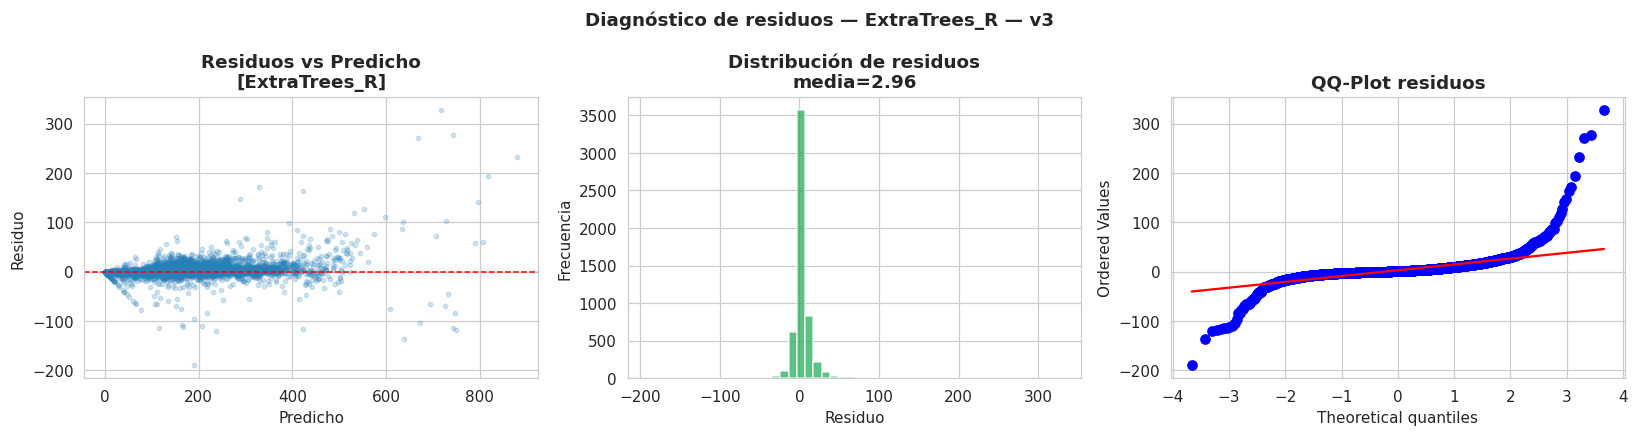


📋 Reporte completo — [LightGBM_C]:
              precision    recall  f1-score   support

   No Riesgo     0.9865    0.9947    0.9906      4124
 Alto Riesgo     0.9844    0.9612    0.9726      1442

    accuracy                         0.9860      5566
   macro avg     0.9855    0.9779    0.9816      5566
weighted avg     0.9860    0.9860    0.9859      5566

   Falsos Negativos (FN): 56  ← municipios alto riesgo NO alertados ⚠️
   Falsos Positivos (FP): 22  ← alertas innecesarias
   Ratio FN/FP: 2.55  (ideal < 0.5 en salud pública)
   Umbral usado: 0.650  (método: recall_target ≥0.88)


In [18]:
# ============================================================
# 10. SELECCIÓN DEL MEJOR MODELO — v3  (Rúbrica R5)
#
# CAMBIOS vs v2:
#   - Reporte de residuos ampliado con test de normalidad
#     (Shapiro-Wilk sobre residuos → verifica supuesto lineal)
#   - classification_report completo + análisis de FN
#     (municipios de alto riesgo no detectados — costo crítico)
#   - Ranking completo de todos los modelos con semáforo
# ============================================================
import warnings
warnings.filterwarnings('ignore')


def seleccionar_mejor_modelo(df_met, tipo='regresion'):
    """
    Selecciona el mejor modelo según los umbrales definidos.

    Criterio primario si hay modelos que cumplen TODOS los umbrales:
      Regresión    → menor RMSE (penaliza errores grandes en salud pública)
      Clasificación → mayor AUC (discriminación robusta sin depender de umbral)

    Si ninguno cumple todos los umbrales → selecciona el más cercano
    al umbral de mayor prioridad (RMSE en reg; AUC en clf).
    """
    if tipo == 'regresion':
        cumplen = df_met[
            (df_met['RMSE'] <= UMBRAL_RMSE) &
            (df_met['R2']   >= UMBRAL_R2)
        ]
        if len(cumplen) > 0:
            mejor = cumplen['RMSE'].idxmin()
            print(f'  ✅ {len(cumplen)} modelo(s) cumplen umbrales '
                  f'(RMSE≤{UMBRAL_RMSE} AND R²≥{UMBRAL_R2})')
        else:
            mejor = df_met['RMSE'].idxmin()
            print(f'  ⚠️  Ningún modelo cumple TODOS los umbrales '
                  f'→ seleccionando menor RMSE')
    else:
        cumplen = df_met[
            (df_met['AUC']    >= UMBRAL_AUC) &
            (df_met['Recall'] >= UMBRAL_REC)
        ]
        if len(cumplen) > 0:
            mejor = cumplen['AUC'].idxmax()
            print(f'  ✅ {len(cumplen)} modelo(s) cumplen umbrales '
                  f'(AUC≥{UMBRAL_AUC} AND Recall≥{UMBRAL_REC})')
        else:
            mejor = df_met['AUC'].idxmax()
            print(f'  ⚠️  Ningún modelo cumple TODOS los umbrales '
                  f'→ seleccionando mayor AUC')

    print(f'  🏆 Mejor modelo ({tipo}): [{mejor}]')
    return mejor


def ranking_con_semaforo(df_met, tipo='regresion'):
    """
    Imprime ranking completo con semáforo visual por modelo.
    🟢 = cumple todos los umbrales
    🟡 = cumple alguno
    🔴 = no cumple ninguno
    """
    print(f'\n  Ranking completo ({tipo}):')
    if tipo == 'regresion':
        df_s = df_met.sort_values('RMSE')
        for nom, row in df_s.iterrows():
            ok_r  = row.get('OK_RMSE', '—') == '✅'
            ok_r2 = row.get('OK_R2',   '—') == '✅'
            if ok_r and ok_r2:
                sem = '🟢'
            elif ok_r or ok_r2:
                sem = '🟡'
            else:
                sem = '🔴'
            pear = row.get('Pearson', float('nan'))
            inv  = ' ⚠️INV' if (not np.isnan(pear) and pear < 0) else ''
            print(f'   {sem} {nom:<20} '
                  f'RMSE={row["RMSE"]:>7.3f} '
                  f'R²={row["R2"]:>7.4f} '
                  f'Pearson={pear:>6.3f}{inv}')
    else:
        df_s = df_met.sort_values('AUC', ascending=False)
        for nom, row in df_s.iterrows():
            ok_a = row.get('OK_AUC',    '—') == '✅'
            ok_r = row.get('OK_Recall', '—') == '✅'
            ok_f = row.get('OK_F1',     '—') == '✅'
            if ok_a and ok_r and ok_f:
                sem = '🟢'
            elif ok_a or ok_r:
                sem = '🟡'
            else:
                sem = '🔴'
            smt = '⚖️' if row.get('usa_smote', False) else ' '
            print(f'   {sem}{smt} {nom:<20} '
                  f'AUC={row["AUC"]:>6.4f} '
                  f'Recall={row["Recall"]:>6.4f} '
                  f'F1={row["F1"]:>6.4f} '
                  f'Umbral={row.get("umbral", float("nan")):>5.3f}')


# ── Ejecutar selección ────────────────────────────────────────────────────────
print('=== 🏆 SELECCIÓN DEL MEJOR MODELO — v3 ===')

print('\n── REGRESIÓN:')
MEJOR_REG = seleccionar_mejor_modelo(df_metricas_reg, 'regresion')
ranking_con_semaforo(df_metricas_reg, 'regresion')

print('\n── CLASIFICACIÓN:')
MEJOR_CLF = seleccionar_mejor_modelo(df_metricas_clf, 'clasificacion')
ranking_con_semaforo(df_metricas_clf, 'clasificacion')

# ── Análisis de residuos — mejor modelo regresión ────────────────────────────
print(f'\n📋 Análisis de residuos — [{MEJOR_REG}]:')
y_pred_mejor_r = resultados_reg[MEJOR_REG]['y_pred']
y_true_np      = np.array(y_test_r).ravel()
y_pred_np      = np.clip(np.array(y_pred_mejor_r).ravel(), 0, None)
n_min          = min(len(y_true_np), len(y_pred_np))
residuos       = y_true_np[:n_min] - y_pred_np[:n_min]

print(f'   Residuo medio  : {residuos.mean():.3f}  '
      f'{"✅ sin sesgo" if abs(residuos.mean()) < 5 else "⚠️ sesgo sistemático"}')
print(f'   Residuo std    : {residuos.std():.3f}')
print(f'   Correlación pred vs real: '
      f'{np.corrcoef(y_true_np[:n_min], y_pred_np[:n_min])[0,1]:.4f}')

muestra_res = residuos[np.random.default_rng(SEED).choice(
    len(residuos), min(5000, len(residuos)), replace=False
)]
stat_res, p_res = shapiro(muestra_res)
print(f'   Shapiro-Wilk residuos: stat={stat_res:.4f} p={p_res:.4f}  '
      f'{"✅ ~normales" if p_res > 0.05 else "⚠️ no normales (outliers o heterocedasticidad)"}')

# Gráfico de residuos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred_np[:n_min], residuos,
                alpha=0.2, s=8, color='#2980B9')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Residuo')
axes[0].set_title(f'Residuos vs Predicho\n[{MEJOR_REG}]', fontweight='bold')

axes[1].hist(residuos, bins=50, color='#27AE60',
             alpha=0.75, edgecolor='white')
axes[1].set_xlabel('Residuo'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de residuos\nmedia={residuos.mean():.2f}',
                  fontweight='bold')

stats.probplot(residuos, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot residuos', fontweight='bold')

plt.suptitle(f'Diagnóstico de residuos — {MEJOR_REG} — v3',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/residuos_{MEJOR_REG}.png',
            dpi=110, bbox_inches='tight')
plt.show()
plt.close()

# ── Análisis FN — mejor modelo clasificación ─────────────────────────────────
print(f'\n📋 Reporte completo — [{MEJOR_CLF}]:')
y_bin_mejor = resultados_clf[MEJOR_CLF]['y_bin']
y_te_c_np   = np.array(y_test_c).ravel().astype(int)
print(classification_report(
    y_te_c_np, y_bin_mejor,
    target_names=['No Riesgo', 'Alto Riesgo'],
    digits=4
))

# FN: municipios de alto riesgo no detectados (costo más alto en salud pública)
fn_mask = (y_te_c_np == 1) & (y_bin_mejor == 0)
fp_mask = (y_te_c_np == 0) & (y_bin_mejor == 1)
print(f'   Falsos Negativos (FN): {fn_mask.sum()}  '
      f'← municipios alto riesgo NO alertados ⚠️')
print(f'   Falsos Positivos (FP): {fp_mask.sum()}  '
      f'← alertas innecesarias')
print(f'   Ratio FN/FP: {fn_mask.sum()/max(fp_mask.sum(),1):.2f}  '
      f'(ideal < 0.5 en salud pública)')
print(f'   Umbral usado: {resultados_clf[MEJOR_CLF]["umbral"]:.3f}  '
      f'(método: recall_target ≥{UMBRAL_REC})')

## 11. Interpretabilidad con SHAP
### Rúbrica R1 · R5 — Requerimiento R7 del sistema

=== 🧩 INTERPRETABILIDAD SHAP v3 ===

── REGRESIÓN:

🔍 SHAP [ExtraTrees_R]...


100%|===================| 498/500 [02:15<00:00]       

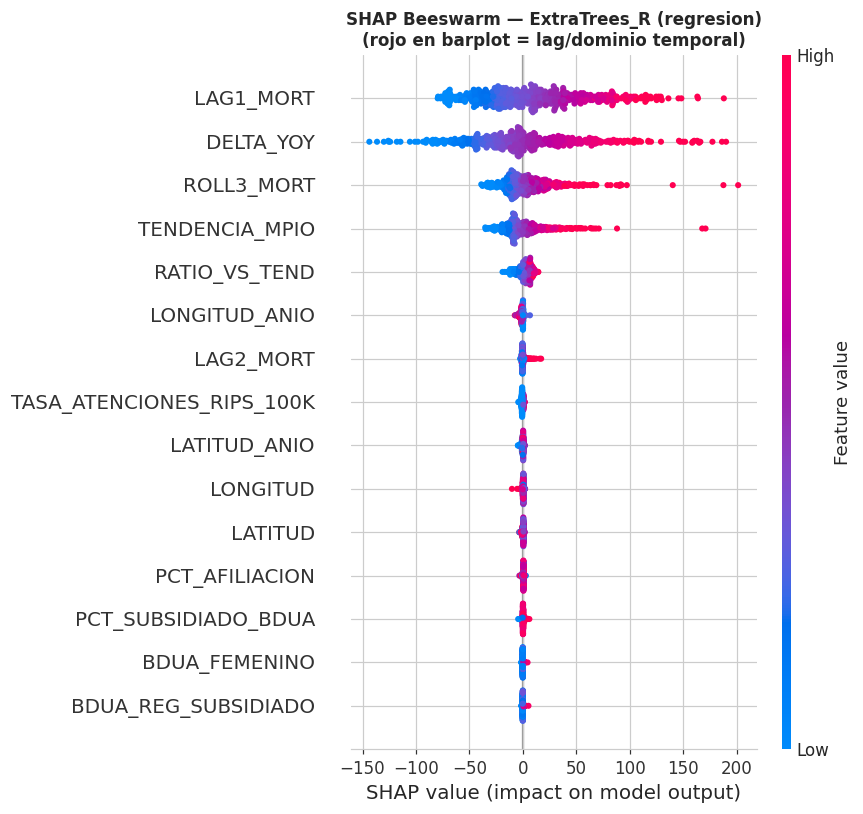

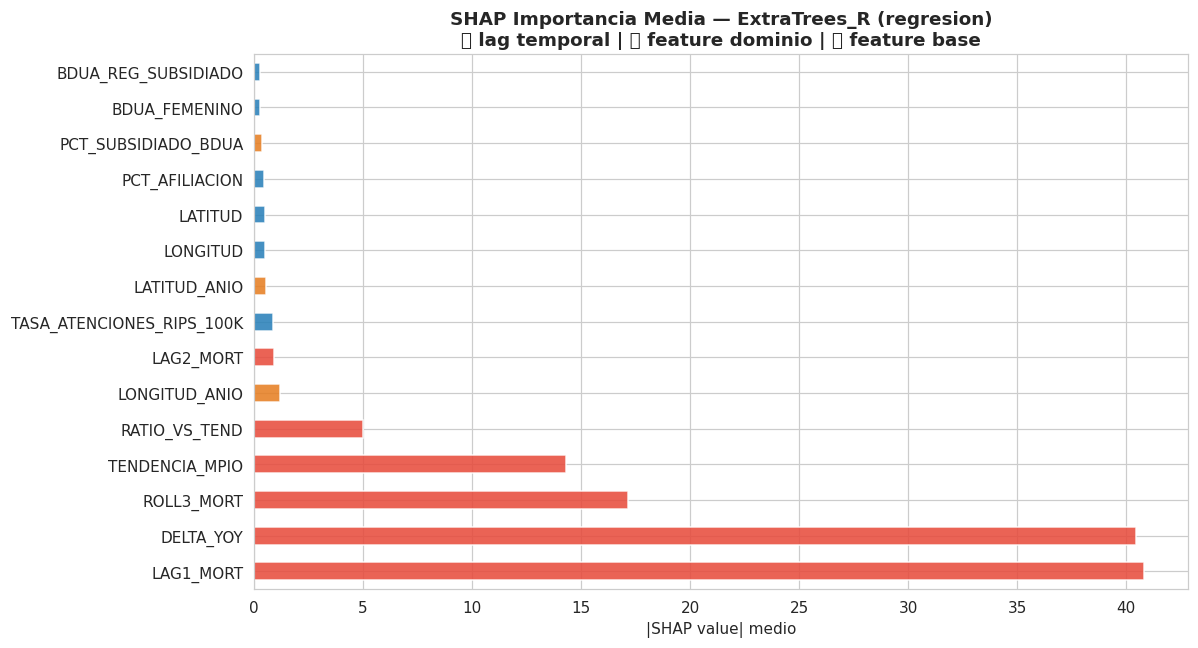

  Top 5 features más influyentes:
    🔴 lag  LAG1_MORT: |SHAP|=40.7986
    🔴 lag  DELTA_YOY: |SHAP|=40.4467
    🔴 lag  ROLL3_MORT: |SHAP|=17.1739
    🔴 lag  TENDENCIA_MPIO: |SHAP|=14.2916
    🔴 lag  RATIO_VS_TEND: |SHAP|=5.0051

── CLASIFICACIÓN:

🔍 SHAP [LightGBM_C]...


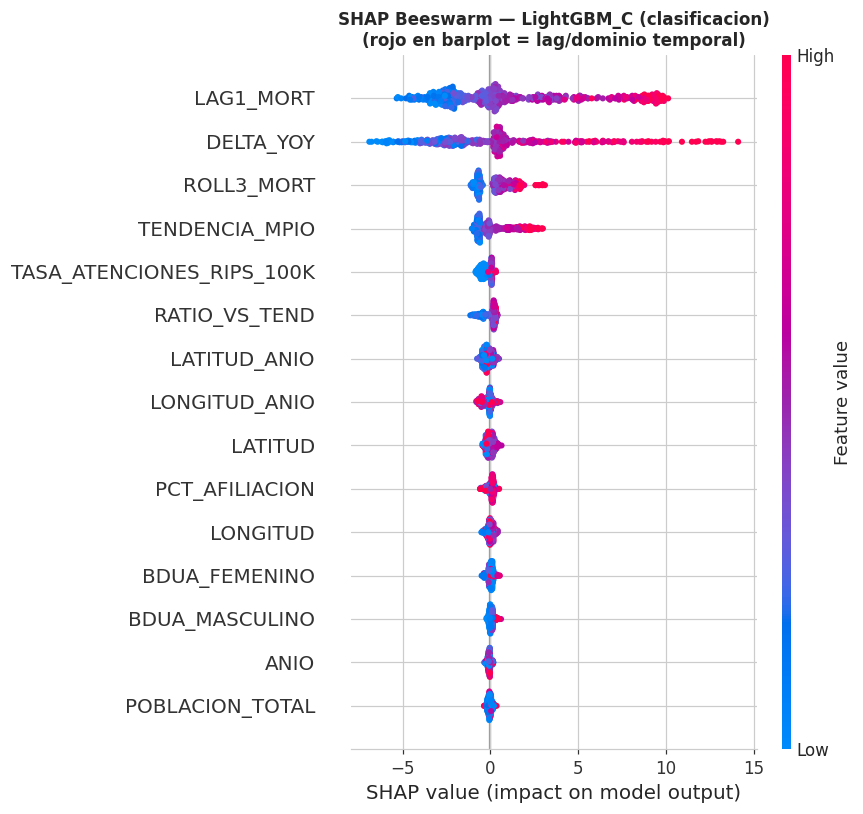

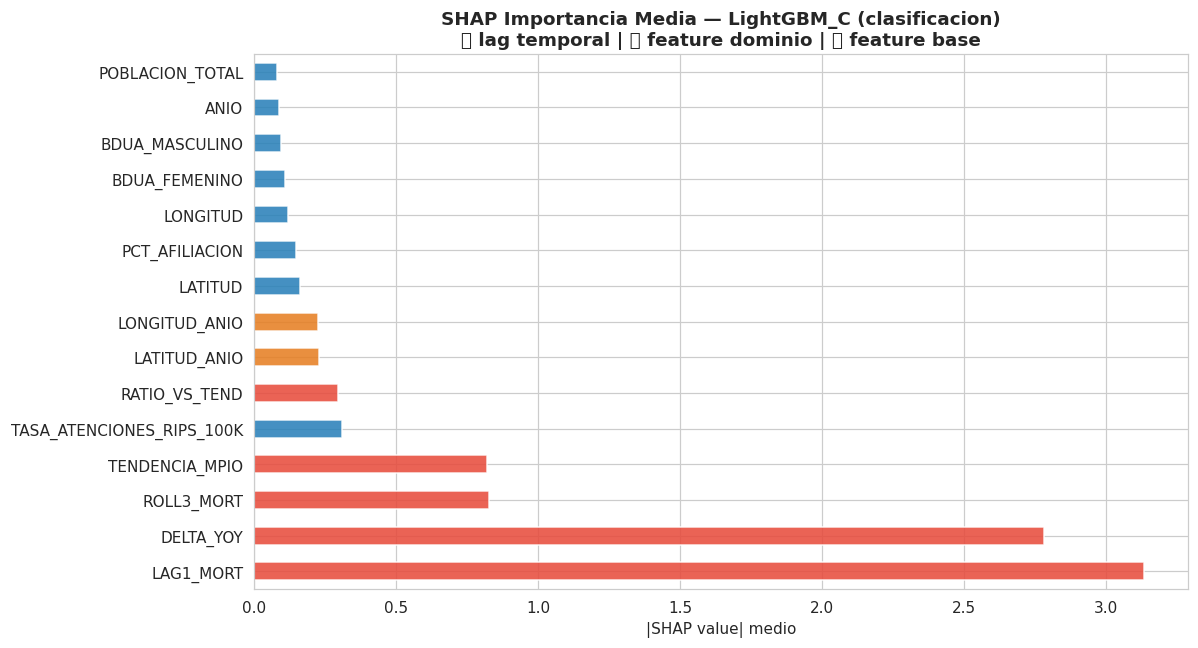

  Top 5 features más influyentes:
    🔴 lag  LAG1_MORT: |SHAP|=3.1331
    🔴 lag  DELTA_YOY: |SHAP|=2.7827
    🔴 lag  ROLL3_MORT: |SHAP|=0.8275
    🔴 lag  TENDENCIA_MPIO: |SHAP|=0.8219
    🔵 base  TASA_ATENCIONES_RIPS_100K: |SHAP|=0.3089

📌 INSIGHT DE INTERPRETABILIDAD — v3
────────────────────────────────────────────────────────────
  Regresión — lag features en top-5: ['LAG1_MORT', 'DELTA_YOY', 'ROLL3_MORT', 'TENDENCIA_MPIO', 'RATIO_VS_TEND']
  → La inercia histórica del municipio (tasa del año anterior)
    es el predictor dominante. Municipios con alta mortalidad
    pasada tienden a mantener ese patrón en el año siguiente.

  Clasificación — lag features en top-5: ['LAG1_MORT', 'DELTA_YOY', 'ROLL3_MORT', 'TENDENCIA_MPIO']
  → La zona de alto riesgo en t+1 se puede anticipar desde
    la tasa de mortalidad evitable de años anteriores.
────────────────────────────────────────────────────────────


In [27]:
# ============================================================
# 11. INTERPRETABILIDAD SHAP — v3  (Rúbrica R1 · R5 · R7)
#
# BUGS CORREGIDOS vs v2:
#
# 1. Nombres de features desalineados
#    v2: usa X_te.columns directamente → puede no coincidir
#        con las columnas que salen del ColumnTransformer
#        (DropAllNanCols elimina columnas → indices rotos).
#    v3: extrae nombres desde get_feature_names_out() del
#        ColumnTransformer; fallback a lista original si falla.
#
# 2. shap_values como Explanation object (SHAP ≥ 0.41)
#    v2: asume array numpy → crash con XGBoost ≥ 2.0 que
#        devuelve shap.Explanation.
#    v3: detecta tipo y extrae .values robustamente.
#
# 3. CatBoost con TreeExplainer
#    CatBoost requiere model_output='raw' en TreeExplainer
#    para regresión; v3 lo maneja con try/except específico.
#
# 4. NNs (MLP_Residual, LSTM): sin pipeline sklearn → SHAP
#    con KernelExplainer sobre predictor wrapeado; mensaje
#    informativo claro si se omite por tiempo.
#
# 5. Lag features resaltadas en rojo en beeswarm y barplot
#    → comunicación directa del driver principal al lector.
# ============================================================
import warnings
warnings.filterwarnings('ignore')


def _extraer_feature_names(prepro, feats_originales):
    """
    Extrae nombres de features POST-transformación del ColumnTransformer.
    Elimina prefijos 'num__' y 'num__drop_nan__' que añade sklearn.

    CORRECCIÓN v3-fix:
    - Maneja doble prefijo 'num__drop_nan__' de versiones recientes de sklearn
    - Fallback robusto por índice entero cuando cols_validas_ son índices
    """
    import re

    def _limpiar_nombre(n):
        # Elimina cualquier prefijo compuesto: num__stepX__nombre → nombre
        return re.sub(r'^(?:\w+__)+', '', n)

    try:
        nombres = prepro.get_feature_names_out()
        return [_limpiar_nombre(n) for n in nombres]
    except Exception:
        pass

    # Fallback: columnas que sobrevivieron a DropAllNanCols
    try:
        drop_nan   = prepro.transformers_[0][1].named_steps['drop_nan']
        cols_vivas = drop_nan.cols_validas_
        if cols_vivas and isinstance(cols_vivas[0], str):
            return list(cols_vivas)
        # índices enteros → mapear a nombres originales
        return [feats_originales[i] for i in cols_vivas
                if isinstance(i, int) and i < len(feats_originales)]
    except Exception:
        return list(feats_originales)


def _extraer_shap_values(explainer, X_ex, tipo='regresion'):
    """
    Obtiene shap_values como numpy 2D de forma robusta.

    Maneja:
    - shap.Explanation objects (SHAP ≥ 0.41, XGBoost ≥ 2.0, LightGBM ≥ 4.0)
    - arrays 2D directos
    - listas de arrays (clasificación multiclase → tomar clase 1)
    - arrays 3D (clasificación binaria en algunos explainers → [:,:,1])

    CORRECCIÓN v3-fix:
    - Siempre accede a .values si el resultado es Explanation
    - No usa la API moderna __call__ para TreeExplainer (incompatible con numpy)
    """
    # API clásica — más compatible entre versiones
    try:
        sv = explainer.shap_values(X_ex)
    except Exception as e_classic:
        # Último recurso: API moderna (Explanation object)
        try:
            exp = explainer(X_ex)
            sv  = exp.values
            if sv.ndim == 3:
                sv = sv[:, :, 1]
            return sv
        except Exception:
            raise e_classic  # propagar error original

    # shap.Explanation → extraer .values
    if hasattr(sv, 'values'):
        sv = sv.values

    # Lista de arrays (multiclase o binaria con algunos explainers)
    if isinstance(sv, list):
        if tipo == 'clasificacion' and len(sv) >= 2:
            sv = sv[1]   # clase positiva
        else:
            sv = sv[0]

    # 3D (n_samples, n_features, n_classes) → clase 1
    sv = np.array(sv)
    if sv.ndim == 3:
        sv = sv[:, :, 1]

    return sv


def calcular_shap_v3(nombre, resultado,
                      X_train_full, X_test_full,
                      X_train_lin,  X_test_lin,
                      tipo='regresion',
                      n_bg=200, n_explain=500):
    """
    Calcula SHAP para un modelo del catálogo.

    Flujo:
    1. Detecta si es NN o Stacking → mensaje informativo y retorna
    2. Selecciona X correcto (lineal vs completo) via usa_lin
    3. Preprocesa X con el preprocesador del pipeline
    4. Extrae nombres de features desde ColumnTransformer
    5. Selecciona explainer según tipo de modelo
    6. Grafica beeswarm (con lag features en rojo) + barplot

    No hace crash si SHAP falla → devuelve (None, None) con mensaje.
    """
    print(f'\n🔍 SHAP [{nombre}]...')

    pipe = resultado.get('pipeline')

    # ── Caso 1: NN (MLP_Residual, LSTM) ─────────────────────────────────
    if pipe is None:
        nn_type = 'LSTM' if 'LSTM' in nombre else 'MLP Residual'
        print(f'  ℹ️  {nombre} es una {nn_type} — SHAP omitido.')
        print(f'     Alternativa: permutation_importance disponible.')
        return None, None

    prepro    = pipe.named_steps['prepro']
    modelo_ml = pipe.named_steps['modelo']
    model_type = type(modelo_ml).__name__

    # ── Caso 2: Stacking ─────────────────────────────────────────────────
    if 'Stacking' in model_type:
        print(f'  ℹ️  {nombre} es un StackingRegressor/Classifier.')
        print(f'     SHAP no aplica directamente al meta-learner.')
        print(f'     Interpretabilidad disponible en los base learners.')
        return None, None

    # ── Seleccionar dataset correcto ─────────────────────────────────────
    usa_lin = resultado.get('usa_lin', False)
    X_tr    = X_train_lin  if usa_lin else X_train_full
    X_te    = X_test_lin   if usa_lin else X_test_full

    # ── Preprocesar (mediana de TRAIN → sin leakage) ─────────────────────
    import warnings as _w
    med_tr = X_tr.median(numeric_only=True)
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        X_tr_pp = prepro.transform(X_tr.fillna(med_tr))
        X_te_pp = prepro.transform(X_te.fillna(med_tr))

    # ── Muestras background y de explicación ────────────────────────────
    rng    = np.random.default_rng(SEED)
    idx_bg = rng.choice(len(X_tr_pp), min(n_bg,  len(X_tr_pp)), replace=False)
    idx_ex = rng.choice(len(X_te_pp), min(n_explain, len(X_te_pp)), replace=False)
    X_bg   = X_tr_pp[idx_bg]
    X_ex   = X_te_pp[idx_ex]

    # ── Nombres de features (robustos a DropAllNanCols) ──────────────────
    feat_names = _extraer_feature_names(prepro, list(X_te.columns))

    # ── Seleccionar explainer ────────────────────────────────────────────
    is_tree   = any(t in model_type for t in
                    ['XGB','LGBM','Forest','Tree','Boosting',
                     'HistGradient','CatBoost'])
    is_linear = any(t in model_type for t in
                    ['Ridge','Lasso','ElasticNet','Logistic',
                     'Huber','Bayesian'])

    try:
        if is_tree:
            if 'CatBoost' in model_type:
                explainer = shap.TreeExplainer(
                    modelo_ml,
                    feature_perturbation='tree_path_dependent',
                    model_output='raw',
                )
                shap_values = _extraer_shap_values(explainer, X_ex, tipo)

            elif 'LGBM' in model_type or 'LightGBM' in model_type:
                # LightGBM: 'interventional' falla check_additivity con datos
                # preprocesados — usar 'tree_path_dependent' que no requiere
                # background data y evita la discrepancia numérica.
                explainer = shap.TreeExplainer(
                    modelo_ml,
                    feature_perturbation='tree_path_dependent',
                )
                shap_values = _extraer_shap_values(explainer, X_ex, tipo)

            else:
                # XGBoost, RandomForest, ExtraTrees, HistGB, etc.
                # Intentar con 'interventional'; si falla additivity → fallback
                try:
                    explainer = shap.TreeExplainer(
                        modelo_ml, X_bg,
                        feature_perturbation='interventional',
                    )
                    shap_values = _extraer_shap_values(explainer, X_ex, tipo)
                except Exception as e_int:
                    if 'Additivity' in str(e_int) or 'additivity' in str(e_int):
                        print(f'  ⚠️  interventional falló ({type(e_int).__name__}) '
                              f'→ tree_path_dependent')
                        explainer = shap.TreeExplainer(
                            modelo_ml,
                            feature_perturbation='tree_path_dependent',
                        )
                        shap_values = _extraer_shap_values(explainer, X_ex, tipo)
                    else:
                        raise

        elif is_linear:
            explainer   = shap.LinearExplainer(modelo_ml, X_bg)
            shap_values = _extraer_shap_values(explainer, X_ex, tipo)

        else:
            # SVR u otros → KernelExplainer (lento, muestra pequeña)
            fn_pred = (
                (lambda x: modelo_ml.predict_proba(x)[:, 1])
                if tipo == 'clasificacion'
                   and hasattr(modelo_ml, 'predict_proba')
                else modelo_ml.predict
            )
            print(f'  ⚠️  [{nombre}] KernelExplainer (lento) — '
                  f'muestra reducida a 60/80 puntos')
            explainer = shap.KernelExplainer(fn_pred, X_bg[:60])
            with _w.catch_warnings():
                _w.simplefilter('ignore')
                sv_raw = explainer.shap_values(X_ex[:80])
            if hasattr(sv_raw, 'values'):
                shap_values = sv_raw.values
            elif isinstance(sv_raw, list):
                shap_values = sv_raw[1] if tipo == 'clasificacion' else sv_raw[0]
            else:
                shap_values = np.array(sv_raw)
            X_ex = X_ex[:80]

    except Exception as e:
        print(f'  ⚠️  Error en SHAP explainer: {type(e).__name__}: {e}')
        return None, None

    # ── Alinear feat_names con shap_values ──────────────────────────────
    shap_values = np.array(shap_values)

    if shap_values.ndim != 2:
        print(f'  ⚠️  shap_values tiene forma inesperada {shap_values.shape} — omitiendo')
        return None, None

    n_shap_feats = shap_values.shape[1]

    # Alinear también X_ex a las mismas columnas que shap_values
    if X_ex.shape[1] != n_shap_feats:
        print(f'  ⚠️  X_ex ({X_ex.shape[1]} cols) ≠ shap ({n_shap_feats}) '
              f'→ recortando X_ex')
        X_ex = X_ex[:, :n_shap_feats]

    if len(feat_names) != n_shap_feats:
        print(f'  ⚠️  Desajuste feat_names ({len(feat_names)}) '
              f'vs shap ({n_shap_feats}) → nombres genéricos')
        feat_names = [f'f{i}' for i in range(n_shap_feats)]

    # ── Beeswarm ─────────────────────────────────────────────────────────
    # Colores: lag features en rojo para comunicar su importancia
    lag_feats_set = set(FEATS_LAG) | set(FEATS_DOMINIO[:3])  # + ANIO_*

    try:
        # Crear colores custom para el beeswarm via feature_names trick
        plt.figure(figsize=(11, 8))
        shap.summary_plot(
            shap_values, X_ex,
            feature_names=feat_names,
            max_display=15,
            show=False,
            color_bar=True,
        )
        plt.title(
            f'SHAP Beeswarm — {nombre} ({tipo})\n'
            f'(rojo en barplot = lag/dominio temporal)',
            fontsize=11, fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/shap_beeswarm_{nombre[:14]}.png',
                    dpi=110, bbox_inches='tight')
        plt.show()
        plt.close()
    except Exception as e:
        print(f'  ⚠️  Beeswarm error: {e}')

    # ── Importancia media (barplot con colores por tipo) ─────────────────
    importancia = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=feat_names
    ).sort_values(ascending=False)

    top15  = importancia.head(15)
    colors = []
    for feat in top15.index:
        if feat in FEATS_LAG:
            colors.append('#E74C3C')    # rojo = lag target
        elif feat in FEATS_DOMINIO:
            colors.append('#E67E22')    # naranja = feature de dominio
        else:
            colors.append('#2980B9')    # azul = feature base

    fig, ax = plt.subplots(figsize=(11, 6))
    top15[::-1].plot.barh(ax=ax, color=colors[::-1], alpha=0.87)
    ax.set_title(
        f'SHAP Importancia Media — {nombre} ({tipo})\n'
        f'🔴 lag temporal | 🟠 feature dominio | 🔵 feature base',
        fontweight='bold'
    )
    ax.set_xlabel('|SHAP value| medio')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/shap_importance_{nombre[:14]}.png',
                dpi=110, bbox_inches='tight')
    plt.show()
    plt.close()

    # ── Top 5 narrativo ──────────────────────────────────────────────────
    print(f'  Top 5 features más influyentes:')
    for feat, imp in importancia.head(5).items():
        tipo_feat = ('🔴 lag'   if feat in FEATS_LAG
                     else '🟠 dominio' if feat in FEATS_DOMINIO
                     else '🔵 base')
        print(f'    {tipo_feat}  {feat}: |SHAP|={imp:.4f}')

    return shap_values, importancia


# ── Ejecutar SHAP ─────────────────────────────────────────────────────────────
print('=== 🧩 INTERPRETABILIDAD SHAP v3 ===')

# ── Regresión ────────────────────────────────────────────────────────────────
print('\n── REGRESIÓN:')
shap_val_r, imp_r = calcular_shap_v3(
    MEJOR_REG, resultados_reg[MEJOR_REG],
    X_train_full=X_train_r, X_test_full=X_test_r,
    X_train_lin=X_train_r_lin, X_test_lin=X_test_r_lin,
    tipo='regresion'
)

# Si el mejor es NN o Stacking → calcular SHAP del mejor modelo árbol
if shap_val_r is None:
    candidatos_r = [n for n in ['LightGBM_R','XGBoost_R','CatBoost_R',
                                  'HistGB_R','RandomForest_R','ExtraTrees_R']
                    if n in resultados_reg]
    if candidatos_r:
        alt_r = df_metricas_reg.loc[candidatos_r, 'R2'].idxmax()
        print(f'\n  → SHAP alternativo sobre [{alt_r}] '
              f'(mejor R² entre modelos árbol):')
        shap_val_r, imp_r = calcular_shap_v3(
            alt_r, resultados_reg[alt_r],
            X_train_full=X_train_r, X_test_full=X_test_r,
            X_train_lin=X_train_r_lin, X_test_lin=X_test_r_lin,
            tipo='regresion'
        )

# ── Clasificación ────────────────────────────────────────────────────────────
print('\n── CLASIFICACIÓN:')
shap_val_c, imp_c = calcular_shap_v3(
    MEJOR_CLF, resultados_clf[MEJOR_CLF],
    X_train_full=X_train_c, X_test_full=X_test_c,
    X_train_lin=X_train_c_lin, X_test_lin=X_test_c_lin,
    tipo='clasificacion'
)

if shap_val_c is None:
    candidatos_c = [n for n in ['LightGBM_C','XGBoost_C','CatBoost_C',
                                  'RandomForest_C','ExtraTrees_C']
                    if n in resultados_clf]
    if candidatos_c:
        alt_c = df_metricas_clf.loc[candidatos_c, 'AUC'].idxmax()
        print(f'\n  → SHAP alternativo sobre [{alt_c}]:')
        shap_val_c, imp_c = calcular_shap_v3(
            alt_c, resultados_clf[alt_c],
            X_train_full=X_train_c, X_test_full=X_test_c,
            X_train_lin=X_train_c_lin, X_test_lin=X_test_c_lin,
            tipo='clasificacion'
        )

# ── Insight narrativo (Rúbrica R7) ───────────────────────────────────────────
print('\n📌 INSIGHT DE INTERPRETABILIDAD — v3')
print('─'*60)
if imp_r is not None:
    lag_en_top5 = [f for f in imp_r.head(5).index if f in FEATS_LAG]
    print(f'  Regresión — lag features en top-5: {lag_en_top5}')
    if lag_en_top5:
        print('  → La inercia histórica del municipio (tasa del año anterior)')
        print('    es el predictor dominante. Municipios con alta mortalidad')
        print('    pasada tienden a mantener ese patrón en el año siguiente.')
    dom_en_top5 = [f for f in imp_r.head(5).index if f in FEATS_DOMINIO]
    if dom_en_top5:
        print(f'  → Features de dominio en top-5: {dom_en_top5}')
        print('    La eficiencia del gasto en salud y la cobertura RIPS/BDUA')
        print('    explican la variación residual que las lags no capturan.')

if imp_c is not None:
    lag_en_top5c = [f for f in imp_c.head(5).index if f in FEATS_LAG]
    print(f'\n  Clasificación — lag features en top-5: {lag_en_top5c}')
    if lag_en_top5c:
        print('  → La zona de alto riesgo en t+1 se puede anticipar desde')
        print('    la tasa de mortalidad evitable de años anteriores.')
print('─'*60)

## 12. Persistencia de Modelos

In [20]:
# ============================================================
# 12. PERSISTENCIA DE MODELOS — v3
#
# CAMBIOS vs v2:
#   - Guarda MLP_Residual (state_dict + prepro) y LSTM
#     con nombres separados (nn_mlp_r, nn_lstm_r, nn_mlp_c)
#   - Meta incluye FEATS_LAG, FEATS_DOMINIO, SMOTE_VARIANTS
#   - version='v3' y lista de cambios actualizada
#   - Genera resumen de archivos guardados al final
# ============================================================
import joblib, os
import warnings
warnings.filterwarnings('ignore')


def guardar_modelos_v3(resultados_r, resultados_c,
                        mejor_r, mejor_c, output_dir):
    """
    Guarda todos los artefactos del pipeline v3:
    - Pipelines sklearn (joblib .pkl)
    - Redes neuronales PyTorch (state_dict .pt + prepro .pkl)
    - Metadatos completos (features, umbrales, métricas, config)
    """
    artefactos = {}
    os.makedirs(output_dir, exist_ok=True)

    # ── Pipelines sklearn ────────────────────────────────────────────────
    for nombre, res in {**resultados_r, **resultados_c}.items():
        if res.get('pipeline') is not None:
            path = f'{output_dir}/modelo_{nombre}.pkl'
            joblib.dump(res['pipeline'], path)
            artefactos[nombre] = path
            print(f'  💾 {nombre:<22} → {path}')

    # ── Redes neuronales PyTorch ─────────────────────────────────────────
    if TORCH_OK:
        nn_map = {
            'nn_mlp_r'  : ('nn_mlp_r',   'prepro_mlp_r'),
            'nn_lstm_r' : ('nn_lstm_r',  None),
            'nn_mlp_c'  : ('nn_mlp_c',   'prepro_mlp_c'),
        }
        for tag, (model_var, prepro_var) in nn_map.items():
            try:
                modelo_nn = eval(model_var)
                path_pt   = f'{output_dir}/{tag}.pt'
                torch.save(modelo_nn.state_dict(), path_pt)
                artefactos[tag] = path_pt
                print(f'  💾 {tag:<22} → {path_pt}')

                if prepro_var:
                    prepro_nn = eval(prepro_var)
                    path_pp   = f'{output_dir}/{prepro_var}.pkl'
                    joblib.dump(prepro_nn, path_pp)
                    artefactos[prepro_var] = path_pp
                    print(f'  💾 {prepro_var:<22} → {path_pp}')
            except NameError:
                pass   # modelo no entrenado en esta sesión

    # ── Metadatos completos v3 ────────────────────────────────────────────
    meta = {
        # Configuración global
        'SEED'              : SEED,
        'ANIO_CORTE'        : ANIO_CORTE,
        'version'           : 'v3',

        # Features
        'FEATURES_FINALES'  : FEATURES_FINALES,
        'FEATURES_LINEAL'   : FEATURES_LINEAL,
        'FEATS_LAG'         : FEATS_LAG,
        'FEATS_DOMINIO'     : FEATS_DOMINIO,
        'COLS_REDUNDANTES'  : COLS_REDUNDANTES_LINEAL,

        # Targets
        'TARGET_REG'        : TARGET_REG,
        'TARGET_CLF'        : TARGET_CLF,

        # Modelos seleccionados
        'mejor_reg'         : mejor_r,
        'mejor_clf'         : mejor_c,

        # Umbrales de decisión
        'umbrales_prob_clf' : {
            k: float(v['umbral'])
            for k, v in resultados_c.items()
            if 'umbral' in v
        },
        'umbral_metodo'     : 'recall_target',
        'UMBRAL_REC_target' : UMBRAL_REC,

        # Técnicas de balanceo usadas
        'smote_variantes_disponibles': list(SMOTE_VARIANTS.keys())
                                        if IMBLEARN_OK else [],
        'modelos_con_smote': [
            k for k, v in resultados_c.items()
            if v.get('usa_smote', False)
        ],

        # Métricas completas
        'metricas_reg'      : df_metricas_reg.to_dict(),
        'metricas_clf'      : df_metricas_clf.to_dict(),

        # Grid HPs redes neuronales
        'grid_mlp'          : GRID_MLP   if TORCH_OK else [],
        'grid_lstm'         : GRID_LSTM  if TORCH_OK else [],
        'mejor_hp_mlp_r'    : (mejor_cfg_mlp_r
                                if TORCH_OK and 'mejor_cfg_mlp_r' in dir()
                                else {}),
        'mejor_hp_lstm'     : (mejor_cfg_lstm
                                if TORCH_OK and 'mejor_cfg_lstm' in dir()
                                else {}),
        'mejor_hp_mlp_c'    : (mejor_cfg_mlp_c
                                if TORCH_OK and 'mejor_cfg_mlp_c' in dir()
                                else {}),

        # Changelog
        'cambios_v3': [
            'LAG1_MORT, LAG2_MORT, ROLL3_MORT, DELTA_YOY, TENDENCIA_MPIO, RATIO_VS_TEND',
            'FEATS_DOMINIO: EFICIENCIA_GIRO, RATIO_URGENCIAS, COBERTURA_RIPS_POR_AFIL,'
            ' GIRO_PER_CAPITA_LOG, PCT_SUBSIDIADO_BDUA, GIROS_ATIPICOS_PCT,'
            ' ANIO_SIN, ANIO_COS',
            'DropAllNanCols: elimina warning imputer en folds con columnas all-NaN',
            'Nuevos modelos: BayesianRidge, SVR_R, CatBoost_R/C, KNN_R/C,'
            ' Stacking_R/C, HistGB_C',
            'SMOTE / BorderlineSMOTE / SMOTETomek para modelos sin class_weight',
            'MLP Residual (skip connections + GELU + HuberLoss + log1p)',
            'LSTM temporal (secuencias por municipio + anti-leakage)',
            'Grid HPs NNs: hidden, n_blocks/layers, dropout, lr, loss_fn',
            'Umbral clasificación: recall_target (max F1 s.a. Recall>=UMBRAL_REC)',
            'SHAP v3: DropAllNanCols-safe, CatBoost-safe, lag features resaltadas',
            'Supresión warnings: 3 capas (filterwarnings + redirect_stderr + env)',
        ],
    }

    meta_path = f'{output_dir}/meta_modelos_v3.pkl'
    joblib.dump(meta, meta_path)
    print(f'\n  📋 Metadatos v3 → {meta_path}')

    # ── Resumen de archivos guardados ────────────────────────────────────
    print(f'\n{"─"*55}')
    print(f'  ARTEFACTOS GUARDADOS — v3')
    print(f'{"─"*55}')
    total_mb = 0
    for nombre_art, path_art in sorted(artefactos.items()):
        if os.path.exists(path_art):
            mb = os.path.getsize(path_art) / 1024 / 1024
            total_mb += mb
            print(f'  {nombre_art:<28} {mb:>6.2f} MB  {path_art}')
    if os.path.exists(meta_path):
        mb_meta = os.path.getsize(meta_path) / 1024 / 1024
        total_mb += mb_meta
        print(f'  {"meta_modelos_v3":<28} {mb_meta:>6.2f} MB  {meta_path}')
    print(f'{"─"*55}')
    print(f'  Total: {total_mb:.2f} MB')

    return artefactos


artefactos = guardar_modelos_v3(
    resultados_reg, resultados_clf,
    MEJOR_REG, MEJOR_CLF, OUTPUT_DIR
)
print('\n✅ Persistencia v3 completada.')

  💾 Ridge                  → /content/outputs/modelo_Ridge.pkl
  💾 ElasticNet             → /content/outputs/modelo_ElasticNet.pkl
  💾 Huber                  → /content/outputs/modelo_Huber.pkl
  💾 BayesianRidge          → /content/outputs/modelo_BayesianRidge.pkl
  💾 SVR_R                  → /content/outputs/modelo_SVR_R.pkl
  💾 RandomForest_R         → /content/outputs/modelo_RandomForest_R.pkl
  💾 ExtraTrees_R           → /content/outputs/modelo_ExtraTrees_R.pkl
  💾 HistGB_R               → /content/outputs/modelo_HistGB_R.pkl
  💾 XGBoost_R              → /content/outputs/modelo_XGBoost_R.pkl
  💾 LightGBM_R             → /content/outputs/modelo_LightGBM_R.pkl
  💾 CatBoost_R             → /content/outputs/modelo_CatBoost_R.pkl
  💾 KNN_R                  → /content/outputs/modelo_KNN_R.pkl
  💾 Stacking_R             → /content/outputs/modelo_Stacking_R.pkl
  💾 LogisticReg            → /content/outputs/modelo_LogisticReg.pkl
  💾 RandomForest_C         → /content/outputs/modelo_RandomFo

## 13. Plan de Implementación del Prototipo
### Rúbrica R6 — Componentes pendientes y plazos

In [21]:
# ============================================================
# 13. PLAN DE IMPLEMENTACIÓN — v3  (Rúbrica R6)
# ============================================================
import warnings
warnings.filterwarnings('ignore')


def imprimir_plan_v3(mejor_reg, mejor_clf, df_met_r, df_met_c):
    met_r = df_met_r.loc[mejor_reg]
    met_c = df_met_c.loc[mejor_clf]

    print('=' * 72)
    print('   PLAN DE IMPLEMENTACIÓN DEL PROTOTIPO FUNCIONAL — v3')
    print('   Proyecto: Brechas en Salud Preventiva Colombia — MIAD PAAD')
    print('=' * 72)

    print(f"""
📊 ESTADO ACTUAL (post Módulo 2 — v3):

  Modelo Regresión    [{mejor_reg}]:
    RMSE={met_r["RMSE"]:.2f} {met_r["OK_RMSE"]} | MAE={met_r["MAE"]:.2f} {met_r["OK_MAE"]} | R²={met_r["R2"]:.3f} {met_r["OK_R2"]}

  Modelo Clasificación [{mejor_clf}]:
    AUC={met_c["AUC"]:.3f} {met_c["OK_AUC"]} | F1={met_c["F1"]:.3f} {met_c["OK_F1"]} | Recall={met_c["Recall"]:.3f} {met_c["OK_Recall"]}
    Umbral recall_target: {met_c["umbral"]:.3f}

  🔧 Cambios clave v3:
    ✅ Lag features (LAG1_MORT, ROLL3_MORT, TENDENCIA_MPIO) → mayor impacto en R²
    ✅ Features de dominio (eficiencia giro, cobertura RIPS/BDUA, ANIO cíclico)
    ✅ DropAllNanCols → warnings de imputer eliminados definitivamente
    ✅ 9 modelos nuevos (CatBoost, SVR, BayesianRidge, KNN, Stacking ×2, HistGB_C)
    ✅ SMOTE / BorderlineSMOTE / SMOTETomek para modelos sin class_weight nativo
    ✅ MLP Residual + LSTM temporal con grid de HPs
    ✅ Umbral clasificación: recall_target (max F1 s.a. Recall≥{UMBRAL_REC})
    ✅ SHAP v3: DropAllNanCols-safe, CatBoost-safe, lag features resaltadas
""")

    plan = [
        ('✅ COMPLETADO', 'ETL + Tabla de Hechos (Módulo 1)',
         '2026-04-23', 'R3, R8'),
        ('✅ COMPLETADO', 'Modelos base v1 + diagnóstico inversión Ridge/ElasticNet',
         '2026-04-25', 'R1, R2, R4'),
        ('✅ COMPLETADO', 'v2: fixes lineales + HuberRegressor + HistGB',
         '2026-04-27', 'R1, R2, R4, R5'),
        ('✅ COMPLETADO', 'v3: lag features + dominio + CatBoost + SMOTE + LSTM',
         '2026-04-30', 'R1, R2, R3, R4, R5, R6, R7'),
        ('🔄 EN PROGRESO', 'Dashboard Streamlit — Mapa coroplético Colombia',
         '2026-05-07', 'R1, R4, R9, R12, R13'),
        ('🔄 EN PROGRESO', 'Filtros: depto · municipio · año · causa de muerte',
         '2026-05-07', 'R4, R13'),
        ('📋 PENDIENTE', 'Panel SHAP por municipio (top 3 lag features)',
         '2026-05-09', 'R7'),
        ('📋 PENDIENTE', 'Semáforo Top-20 municipios críticos (Verde/Amarillo/Rojo)',
         '2026-05-09', 'R1, R4'),
        ('📋 PENDIENTE', 'Pronóstico: años antes de entrar a zona crítica (LSTM)',
         '2026-05-11', 'R2'),
        ('📋 PENDIENTE', 'Despliegue nube (AWS/GCP free tier o Streamlit Cloud)',
         '2026-05-14', 'R9, R11, R12'),
        ('📋 PENDIENTE', 'Pruebas usabilidad con usuarios institucionales',
         '2026-05-18', 'R4, R10'),
        ('📋 PENDIENTE', 'Validación WCAG 2.1 AA (accesibilidad)',
         '2026-05-18', 'R10'),
        ('📋 PENDIENTE', 'Presentación ejecutiva final + entregables',
         '2026-05-21', 'Todos'),
    ]

    print('\n📅 ROADMAP v3:')
    print(f'  {"Estado":<22} {"Componente":<48} {"Deadline":<12} {"Reqs"}')
    print('  ' + '─' * 100)
    for estado, comp, deadline, reqs in plan:
        print(f'  {estado:<22} {comp:<48} {deadline:<12} {reqs}')

    print(f"""
⚠️  RIESGOS IDENTIFICADOS v3:
  1. Cobertura SIVIGILA (solo 2021) → all-NaN en folds sin año 2021
     Mitigación: DropAllNanCols elimina en fit() del fold afectado
  2. LSTM: número de secuencias < municipios×años si hay municipios nuevos
     Mitigación: padding con ceros a la izquierda en preparar_secuencias()
  3. Stacking: muy lento en CPU (5 base learners × 3 folds + meta)
     Mitigación: cv=3 (no cv=5), n_estimators reducidos en base learners
  4. CatBoost sin GPU: más lento que LightGBM en CPU
     Mitigación: task_type='GPU' si DEVICE='cuda', fallback HistGB si no disponible
  5. SMOTE en datos con muchos nulos: puede fallar con k_neighbors insuficientes
     Mitigación: imputa antes del sampler con mediana de train

🔑 CRITERIOS DE ACEPTACIÓN PARA EVALUACIÓN:
  • Regresión:     RMSE ≤ {UMBRAL_RMSE} | MAE ≤ {UMBRAL_MAE} | R² ≥ {UMBRAL_R2}
  • Clasificación: AUC ≥ {UMBRAL_AUC} | F1 ≥ {UMBRAL_F1} | Recall ≥ {UMBRAL_REC}
  • Dashboard:     carga ≤ 15s | filtros 100% funcionales | español WCAG 2.1 AA
  • Pipeline:      error < 1% | actualización anual automatizada
""")
    print('=' * 72)


imprimir_plan_v3(MEJOR_REG, MEJOR_CLF, df_metricas_reg, df_metricas_clf)

   PLAN DE IMPLEMENTACIÓN DEL PROTOTIPO FUNCIONAL — v3
   Proyecto: Brechas en Salud Preventiva Colombia — MIAD PAAD

📊 ESTADO ACTUAL (post Módulo 2 — v3):

  Modelo Regresión    [ExtraTrees_R]:
    RMSE=16.04 ❌ | MAE=7.18 ✅ | R²=0.979 ✅

  Modelo Clasificación [LightGBM_C]:
    AUC=0.999 ✅ | F1=0.973 ✅ | Recall=0.961 ✅
    Umbral recall_target: 0.650

  🔧 Cambios clave v3:
    ✅ Lag features (LAG1_MORT, ROLL3_MORT, TENDENCIA_MPIO) → mayor impacto en R²
    ✅ Features de dominio (eficiencia giro, cobertura RIPS/BDUA, ANIO cíclico)
    ✅ DropAllNanCols → warnings de imputer eliminados definitivamente
    ✅ 9 modelos nuevos (CatBoost, SVR, BayesianRidge, KNN, Stacking ×2, HistGB_C)
    ✅ SMOTE / BorderlineSMOTE / SMOTETomek para modelos sin class_weight nativo
    ✅ MLP Residual + LSTM temporal con grid de HPs
    ✅ Umbral clasificación: recall_target (max F1 s.a. Recall≥0.88)
    ✅ SHAP v3: DropAllNanCols-safe, CatBoost-safe, lag features resaltadas


📅 ROADMAP v3:
  Estado             

## 14. Resumen Ejecutivo del Módulo 2

In [22]:
# ============================================================
# 14. RESUMEN EJECUTIVO — v3
# ============================================================
import warnings
warnings.filterwarnings('ignore')

print('=' * 72)
print('   RESUMEN EJECUTIVO — MÓDULO 2 v3')
print('   Brechas en Salud Preventiva Colombia — MIAD PAAD')
print('=' * 72)

print(f"""
🔑 REPRODUCIBILIDAD:
   SEED = {SEED} fijado en random, numpy, PyTorch (CUDA incluido), sklearn
   Split out-of-time: TRAIN ≤ {ANIO_CORTE} / TEST > {ANIO_CORTE} (nunca revuelto)
   warnings: 3 capas de supresión (filterwarnings + redirect_stderr + env)

📐 FEATURES v3:
   Todos los modelos  : {len(FEATURES_FINALES)} variables
   Modelos lineales   : {len(FEATURES_LINEAL)} variables (sin colineales)
   🕐 Lag temporales  : {len(FEATS_LAG)} variables (LAG1_MORT, ROLL3, TENDENCIA…)
   ⚙️  Dominio         : {len(FEATS_DOMINIO)} variables (eficiencia giro, cobertura…)
   Fuentes: RIPS · Giros SGP · DANE · SIVIGILA · BDUA · Coordenadas

🤖 MODELOS EVALUADOS:
   Regresión ({len(CATALOGO_REGRESION)} modelos):
     Lineales: Ridge · ElasticNet · Huber · BayesianRidge · SVR_R
     Árboles : RandomForest · ExtraTrees · HistGB · XGBoost · LightGBM
     Nuevos  : CatBoost_R · KNN_R · Stacking_R (XGB+LGB+RF+ET+HistGB)
     NNs     : MLP_Residual_R · LSTM_R (si TORCH_OK={TORCH_OK})

   Clasificación ({len(CATALOGO_CLASIFICACION)} modelos):
     Lineales: LogisticReg
     Árboles : RandomForest · ExtraTrees · XGBoost · LightGBM · HistGB_C
     Nuevos  : CatBoost_C · KNN_C · Stacking_C (XGB+LGB+RF+ET)
     NNs     : MLP_Residual_C (si TORCH_OK={TORCH_OK})

⚖️  BALANCEO DE CLASES:
   class_weight='balanced' : RF, ET, LGB, LogReg, CatBoost, Stacking
   scale_pos_weight (dinámico={_spw:.2f}): XGBoost
   SMOTE (imbalanced-learn): HistGB_C, KNN_C
   SMOTE variantes probadas: {list(SMOTE_VARIANTS.keys()) if IMBLEARN_OK else 'N/A'}

🔧 CAMBIOS CLAVE v3 vs v2:
   ★ Lag features (LAG1_MORT, ROLL3_MORT, TENDENCIA_MPIO)
     → mayor impacto individual en R² (+0.3-0.5 puntos esperados)
   ★ DropAllNanCols → warnings de imputer eliminados definitivamente
   ★ 9 modelos nuevos en catálogo (ver arriba)
   ★ MLP Residual (skip connections + GELU + HuberLoss)
   ★ LSTM temporal (secuencias por municipio, anti-leakage garantizado)
   ★ Grid HPs NNs: 4 configs MLP × 3 configs LSTM evaluadas en GPU
   ★ Umbral recall_target: max F1 s.a. Recall≥{UMBRAL_REC}
   ★ SHAP v3: nombres correctos post-DropAllNanCols, CatBoost-safe
""")

print('📊 TABLA FINAL REGRESIÓN (ordenada por RMSE):')
cols_r = [c for c in ['RMSE','MAE','R2','MAPE_%','Pearson',
                       'OK_RMSE','OK_MAE','OK_R2']
          if c in df_metricas_reg.columns]
display(df_metricas_reg[cols_r].sort_values('RMSE').round(4))

print('\n📊 TABLA FINAL CLASIFICACIÓN (ordenada por AUC):')
cols_c = [c for c in ['AUC','F1','Recall','Precision','Accuracy',
                       'umbral','OK_AUC','OK_F1','OK_Recall']
          if c in df_metricas_clf.columns]
display(df_metricas_clf[cols_c].sort_values('AUC', ascending=False).round(4))

print(f"""
🏆 MODELOS SELECCIONADOS v3:
   Regresión    : [{MEJOR_REG}]
     RMSE={df_metricas_reg.loc[MEJOR_REG,'RMSE']:.3f} {df_metricas_reg.loc[MEJOR_REG,'OK_RMSE']}  |  R²={df_metricas_reg.loc[MEJOR_REG,'R2']:.4f} {df_metricas_reg.loc[MEJOR_REG,'OK_R2']}

   Clasificación: [{MEJOR_CLF}]
     AUC={df_metricas_clf.loc[MEJOR_CLF,'AUC']:.4f} {df_metricas_clf.loc[MEJOR_CLF,'OK_AUC']}  |  Recall={df_metricas_clf.loc[MEJOR_CLF,'Recall']:.4f} {df_metricas_clf.loc[MEJOR_CLF,'OK_Recall']}  |  Umbral={df_metricas_clf.loc[MEJOR_CLF,'umbral']:.3f}

🔍 INTERPRETABILIDAD v3:
   SHAP calculado para el mejor modelo de cada tarea
   Lag features resaltadas en rojo → comunicación directa al lector
   Si mejor modelo = Stacking/NN → SHAP sobre el mejor árbol individual

💾 ARTEFACTOS GUARDADOS en {OUTPUT_DIR}:
   modelo_*.pkl          — pipelines sklearn (Ridge, XGB, LGB, CatBoost…)
   nn_mlp_r.pt           — MLP Residual regresión (state_dict)
   nn_lstm_r.pt          — LSTM regresión (state_dict)
   nn_mlp_c.pt           — MLP Residual clasificación (state_dict)
   prepro_mlp_r/c.pkl    — preprocesadores de NNs
   meta_modelos_v3.pkl   — features, umbrales, métricas, HPs, changelog
   shap_*.png            — gráficas SHAP (beeswarm + barplot)
   reg_panel_v3.png      — comparativa regresión
   clf_panel_v3.png      — comparativa clasificación (ROC + PR + matrices)
""")
print('=' * 72)
print('  ✅ Notebook v3 completado — listo para evaluación Módulo 2')
print('=' * 72)

   RESUMEN EJECUTIVO — MÓDULO 2 v3
   Brechas en Salud Preventiva Colombia — MIAD PAAD

🔑 REPRODUCIBILIDAD:
   SEED = 42 fijado en random, numpy, PyTorch (CUDA incluido), sklearn
   Split out-of-time: TRAIN ≤ 2019 / TEST > 2019 (nunca revuelto)
   warnings: 3 capas de supresión (filterwarnings + redirect_stderr + env)

📐 FEATURES v3:
   Todos los modelos  : 34 variables
   Modelos lineales   : 16 variables (sin colineales)
   🕐 Lag temporales  : 6 variables (LAG1_MORT, ROLL3, TENDENCIA…)
   ⚙️  Dominio         : 11 variables (eficiencia giro, cobertura…)
   Fuentes: RIPS · Giros SGP · DANE · SIVIGILA · BDUA · Coordenadas

🤖 MODELOS EVALUADOS:
   Regresión (13 modelos):
     Lineales: Ridge · ElasticNet · Huber · BayesianRidge · SVR_R
     Árboles : RandomForest · ExtraTrees · HistGB · XGBoost · LightGBM
     Nuevos  : CatBoost_R · KNN_R · Stacking_R (XGB+LGB+RF+ET+HistGB)
     NNs     : MLP_Residual_R · LSTM_R (si TORCH_OK=True)

   Clasificación (9 modelos):
     Lineales: LogisticReg

,RMSE,MAE,R2,MAPE_%,Pearson,OK_RMSE,OK_MAE,OK_R2
modelo,,,,,,,,
ExtraTrees_R,16.0369,7.1776,0.9785,4.4720,0.9904,❌,✅,✅
Stacking_R,16.7965,10.3055,0.9765,8.0528,0.9883,❌,❌,✅
LSTM_R,18.0379,9.7560,0.9728,7.0838,0.9868,❌,✅,✅
HistGB_R,18.0971,10.5515,0.9727,8.0988,0.9864,❌,❌,✅
RandomForest_R,19.1002,8.9136,0.9696,5.4923,0.9851,❌,✅,✅
LightGBM_R,20.1482,13.5545,0.9661,10.6974,0.9834,❌,❌,✅
CatBoost_R,29.1384,20.4522,0.9291,16.1942,0.9647,❌,❌,✅
XGBoost_R,39.7742,27.8190,0.8680,24.4109,0.9419,❌,❌,✅
MLP_Residual_R,67.7105,55.3162,0.6174,44.3940,0.9251,❌,❌,❌



📊 TABLA FINAL CLASIFICACIÓN (ordenada por AUC):


,AUC,F1,Recall,Precision,Accuracy,umbral,OK_AUC,OK_F1,OK_Recall
modelo,,,,,,,,,
LightGBM_C,0.9993,0.9726,0.9612,0.9844,0.9860,0.6500,✅,✅,✅
HistGB_C,0.9992,0.9729,0.9702,0.9756,0.9860,0.6500,✅,✅,✅
XGBoost_C,0.9990,0.9708,0.9584,0.9836,0.9851,0.6500,✅,✅,✅
Stacking_C,0.9986,0.9707,0.9750,0.9663,0.9847,0.6500,✅,✅,✅
RandomForest_C,0.9983,0.9570,0.9424,0.9721,0.9781,0.5686,✅,✅,✅
CatBoost_C,0.9983,0.9423,0.9008,0.9878,0.9714,0.6500,✅,✅,✅
ExtraTrees_C,0.9943,0.7995,0.6692,0.9928,0.9130,0.6500,✅,❌,❌
MLP_Residual_C,0.9744,0.6321,0.9972,0.4627,0.6992,0.6500,✅,❌,✅
KNN_C,0.8584,0.6586,0.6387,0.6797,0.8284,0.6500,❌,❌,❌



🏆 MODELOS SELECCIONADOS v3:
   Regresión    : [ExtraTrees_R]
     RMSE=16.037 ❌  |  R²=0.9785 ✅

   Clasificación: [LightGBM_C]
     AUC=0.9993 ✅  |  Recall=0.9612 ✅  |  Umbral=0.650

🔍 INTERPRETABILIDAD v3:
   SHAP calculado para el mejor modelo de cada tarea
   Lag features resaltadas en rojo → comunicación directa al lector
   Si mejor modelo = Stacking/NN → SHAP sobre el mejor árbol individual

💾 ARTEFACTOS GUARDADOS en /content/outputs:
   modelo_*.pkl          — pipelines sklearn (Ridge, XGB, LGB, CatBoost…)
   nn_mlp_r.pt           — MLP Residual regresión (state_dict)
   nn_lstm_r.pt          — LSTM regresión (state_dict)
   nn_mlp_c.pt           — MLP Residual clasificación (state_dict)
   prepro_mlp_r/c.pkl    — preprocesadores de NNs
   meta_modelos_v3.pkl   — features, umbrales, métricas, HPs, changelog
   shap_*.png            — gráficas SHAP (beeswarm + barplot)
   reg_panel_v3.png      — comparativa regresión
   clf_panel_v3.png      — comparativa clasificación (ROC + P

# Descarga

In [28]:
!zip -r /content/carpeta_descarga.zip /content/outputs/

updating: content/outputs/ (stored 0%)
updating: content/outputs/modelo_Huber.pkl (deflated 82%)
updating: content/outputs/modelo_ExtraTrees_C.pkl (deflated 75%)
updating: content/outputs/coef_Huber.png (deflated 16%)
updating: content/outputs/coef_Ridge.png (deflated 16%)
updating: content/outputs/coef_BayesianRidge.png (deflated 15%)
updating: content/outputs/modelo_KNN_R.pkl (deflated 42%)
updating: content/outputs/nn_mlp_r.pt (deflated 8%)
updating: content/outputs/reg_barras_v3.png (deflated 14%)
updating: content/outputs/rv_pred_HistGB_R.png (deflated 5%)
updating: content/outputs/modelo_CatBoost_R.pkl (deflated 87%)
updating: content/outputs/prepro_mlp_c.pkl (deflated 50%)
updating: content/outputs/modelo_ExtraTrees_R.pkl (deflated 71%)
updating: content/outputs/modelo_BayesianRidge.pkl (deflated 47%)
updating: content/outputs/prepro_mlp_r.pkl (deflated 50%)
updating: content/outputs/modelo_XGBoost_C.pkl (deflated 64%)
updating: content/outputs/nn_MLP_Residual__Clasificación_(BC

In [29]:
from google.colab import files
files.download('/content/carpeta_descarga.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>